Below is my implementation of getting the band diamgrams utilizng the MPB library of Meep

In [108]:
# Importing Libraries: 

import meep as mp
import matplotlib.pyplot as plt
import numpy as np 
from IPython.display import Video 
from meep import mpb
from scipy.optimize import minimize

%matplotlib inline 

In [109]:
def banddiagram_wmpb(width: float, length: float, diameter: float, show_geometry: bool, band_diagram: str):
    # width - width of our beam in nanometers
    # length - length of our beam in nanometers
    # diameter - diameter of the holes in patterned into the beam in nanometers
    # Show_geometry - boolean value for if you want to show the geometry or not
    # band_diagram - 'all' string value to show all band gaps, 'max' to show only the largest band gap

    # It is to note that Meep utlizes normalized units, so I set the length scale to the length of our unit cell
    
    c = 3e8 # Speed of light for conversion later

    # Parameters for the computational cell: 
    pml_padding = length  
    padding_to_pml = 4*length
    sx = 1       # We will scale the dimensions of everything else by the length (for example we scaled the paddings above by the length)
    sy = 2*(pml_padding + padding_to_pml + width)/length  
    res = 64     # I had set the resolution to a power of two, I dont know if that will aid in the computational speed but Meep mentioned somewhere in the documentation to do this

    cell = mp.Vector3(sx,sy)
    lattice = mp.Lattice(mp.Vector3(1,1))

    # For the silicon we want to use and our approximate target wavelength is below: 
    eps_silicon = 12
    thickness = 220
    wavelength = 1540 

    # Defining our waveguide given the parameters, meep assumes periodic structure: 
    beam = mp.Block(size = (1, width/length, thickness/length), material = mp.Medium(epsilon = eps_silicon) )
    holes = mp.Cylinder(radius = (diameter/2)/length, height = thickness/length, material = mp.Medium(epsilon = 1))

    geometry = [beam,holes]

    if show_geometry == 1: 
        # Other things for simulation: It is to note that say we want to run for a certian number of periods, then we would divide our time by the frequency below
        fcenter = length/wavelength           # In meep units, the frequency is specified by 1/lambda according to https://meep.readthedocs.io/en/latest/Introduction/#units-in-meep
        df = .5*fcenter

        sym = mp.Mirror(direction=mp.Y, phase=-1)
        # Broad source to excite modes
        source = mp.Source(mp.GaussianSource(fcenter, fwidth = df), mp.Hz, mp.Vector3(0, 0))
        pml_layers = [mp.PML(pml_padding/length, direction =mp.Y)]

        simulation = mp.Simulation(
            cell_size = cell, 
            boundary_layers = pml_layers, 
            geometry = geometry, 
            sources = [source], 
            resolution = res, 
            symmetries=[sym]
        )

        f = plt.figure(dpi=200)
        simulation.plot2D(ax = f.gca())
        f.gca().xaxis.set_visible(False)
        f.suptitle('Geometry of Simulation')
        plt.show()

    # It was more or less the same to the prior implementation of this code, now we will utlize MPB to get the band diagrams: 
    num_bands = 2
    k_points = [mp.Vector3(0), mp.Vector3(.5)]       # Two dimensional simulation but only getting the x component of the wave vectors
    k_points = mp.interpolate(30, k_points)         # Interpolation to get more k vectors for our simulation, set to another power of two
    
    # mpb implementation of the mode solver: 
    ms = mpb.ModeSolver(
        num_bands = num_bands, 
        k_points= k_points, 
        geometry= geometry, 
        geometry_lattice= lattice, 
        resolution= res 
    )

    # We will split the modes up into TE and TM modes: 
    ms.run_te()
    te = ms.all_freqs       # The column index represents the frequencies for the index+1 band
    #print(f' \n The gap list is{ms.gap_list} \n' )
    te_gaps = ms.gap_list

    ms.run_tm()
    tm = ms.all_freqs
    tm_gaps = ms.gap_list

    convfactor = (c/(length*1e3))

    plot_k = np.array(k_points)
    plot_te_freqs = np.array(te)*convfactor
    plot_tm_freqs = (np.array(tm))*convfactor

    #legends = [f'Mode {i+1}' for i in range(num_bands)] Legend is useless when we know modes go up increasing frequency 

    fig = plt.figure(num = 1,dpi = 200, figsize = (10,10))
    ax1 = plt.subplot(2,1,1)
    ax1.plot(plot_k[:,0].T, plot_te_freqs)

    # Plotting the band gaps: 
    max_te = 0
    max_te_percent = 0 
    for gap in te_gaps: 
        if gap[0]>1: 
            [max_te, max_te_percent] = [max(max_te, (gap[2] - gap[1])*convfactor), max(max_te_percent, gap[0])]
            if band_diagram == 'all':
                ax1.fill_between(plot_k[:,0], gap[1]*convfactor, gap[2]*convfactor, color = 'blue', alpha = .2)
 
    if band_diagram == 'max':
        indexed = te_gaps[:][0].index(max_te_percent)
        ax1.fill_between(plot_k[:,0], te_gaps[indexed][1]*convfactor, te_gaps[indexed][2]*convfactor, color = 'blue', alpha =.2)


    print(f'The largest bandgap is {max_te} THz thick for TE modes')
    ax1.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')
    #ax1.set_ylabel('$\omega$  $[\\frac{2\pi c}{a}]$')
    ax1.set_ylabel('f [THz]')
    ax1.set_title('Band Diagram for TE Modes')
    ax1.set_xlim([0,.5])
    #ax1.legend(legends)
    
    ax2 = plt.subplot(2,1,2)
    ax2.plot(plot_k[:,0].T, plot_tm_freqs)
    

    # Plotting the band gaps: 
    max_tm = 0
    max_tm_percent = 0 
    for gap in tm_gaps: 
        if gap[0]>1: 
            [max_tm, max_tm_percent] = [max(max_tm, (gap[2] - gap[1])*convfactor), max(max_tm_percent, gap[0])]
            if band_diagram == 'all':
                ax2.fill_between(plot_k[:,0], gap[1]*convfactor, gap[2]*convfactor, color = 'red', alpha = .2)

    if band_diagram == 'max':
        indexed = tm_gaps[:][0].index(max_tm_percent)
        ax2.fill_between(plot_k[:,0], tm_gaps[indexed][1]*convfactor, tm_gaps[indexed][2]*convfactor, color = 'red', alpha =.2)


    print(f'The largest bandgap is {max_tm} THz thick for TM modes' )
    ax2.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')
    #ax2.set_ylabel('$\omega$  $[\\frac{2\pi c}{a}]$')
    ax2.set_ylabel('f [THz]')
    ax2.set_title('Band Diagram for TM Modes')
    ax2.set_xlim([0,.5])
    #ax2.legend(legends)

    plt.tight_layout()
    plt.show()

    return max_te

<>:109: SyntaxWarning: invalid escape sequence '\p'
<>:135: SyntaxWarning: invalid escape sequence '\p'
<>:109: SyntaxWarning: invalid escape sequence '\p'
<>:135: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1500864/2093031774.py:109: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')
/tmp/ipykernel_1500864/2093031774.py:135: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')


Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,0.833333,0.366667)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.25, height 0.366667, axis (0, 0, 1)
Geometric object tree has depth 2 and 5 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516129

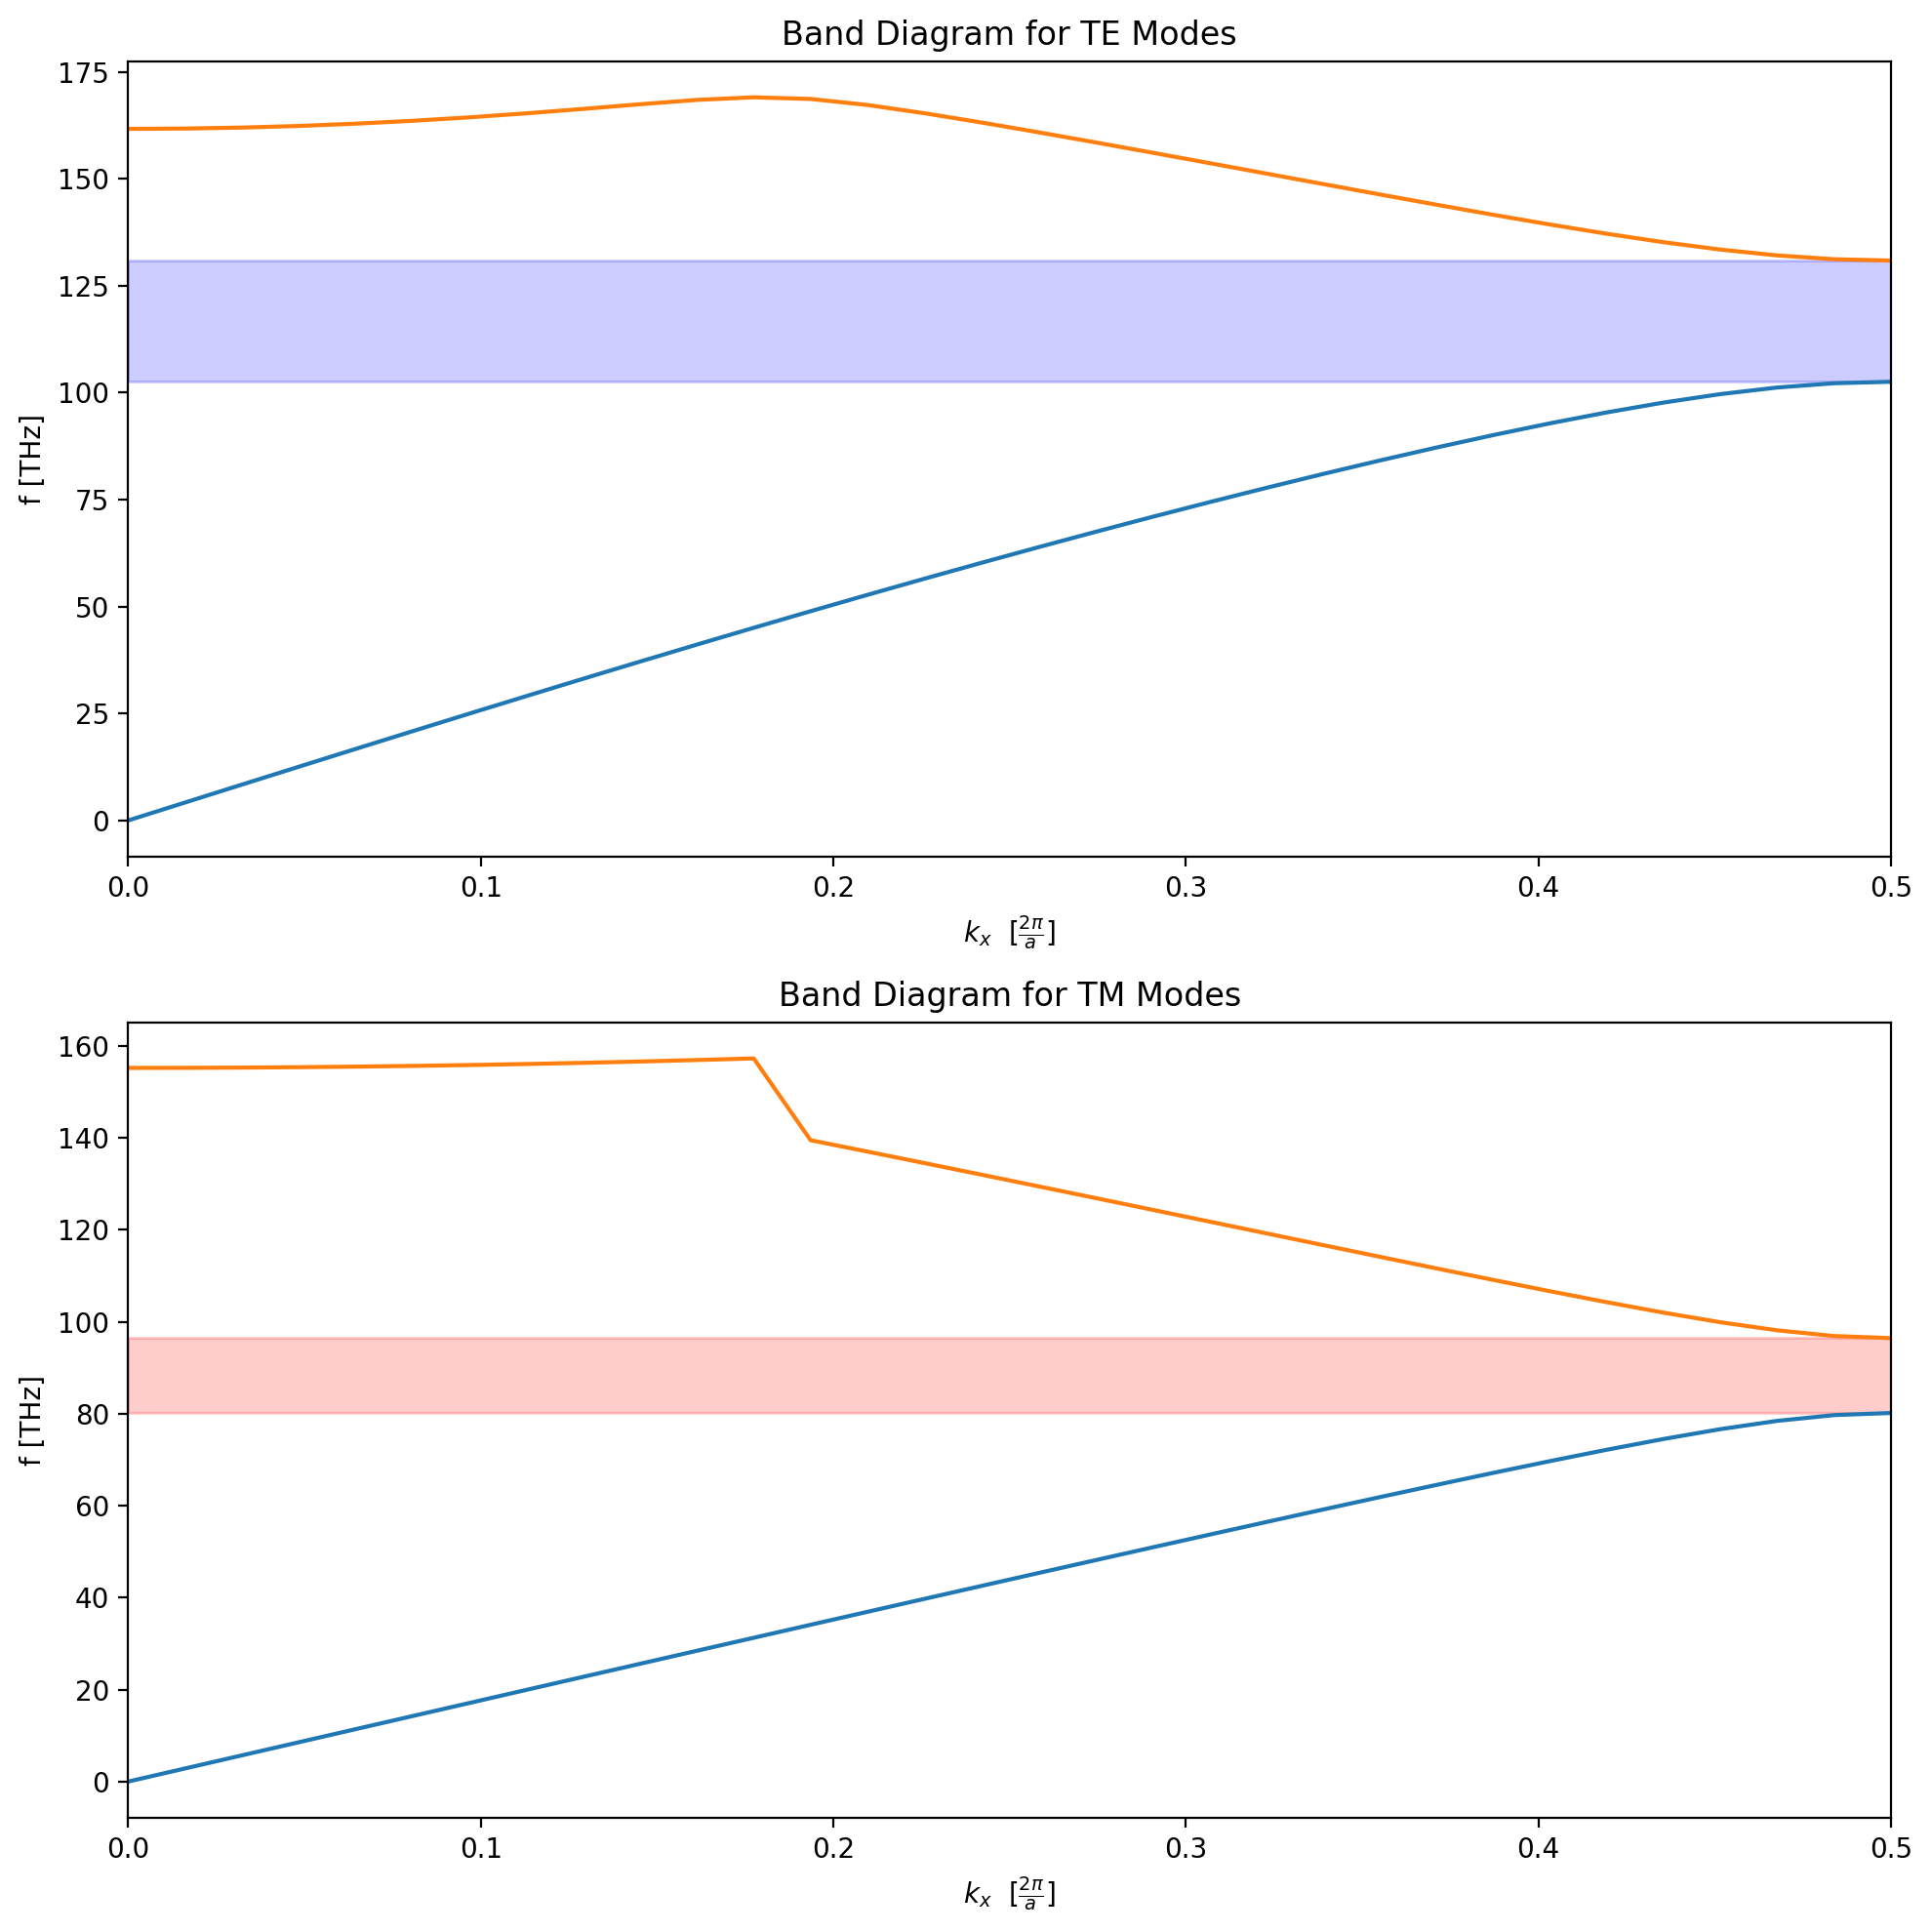

28.336362523644382

In [110]:
banddiagram_wmpb(width = 500,length = 600, diameter= 300, show_geometry= False, band_diagram='max')

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.2,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.433333, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516129

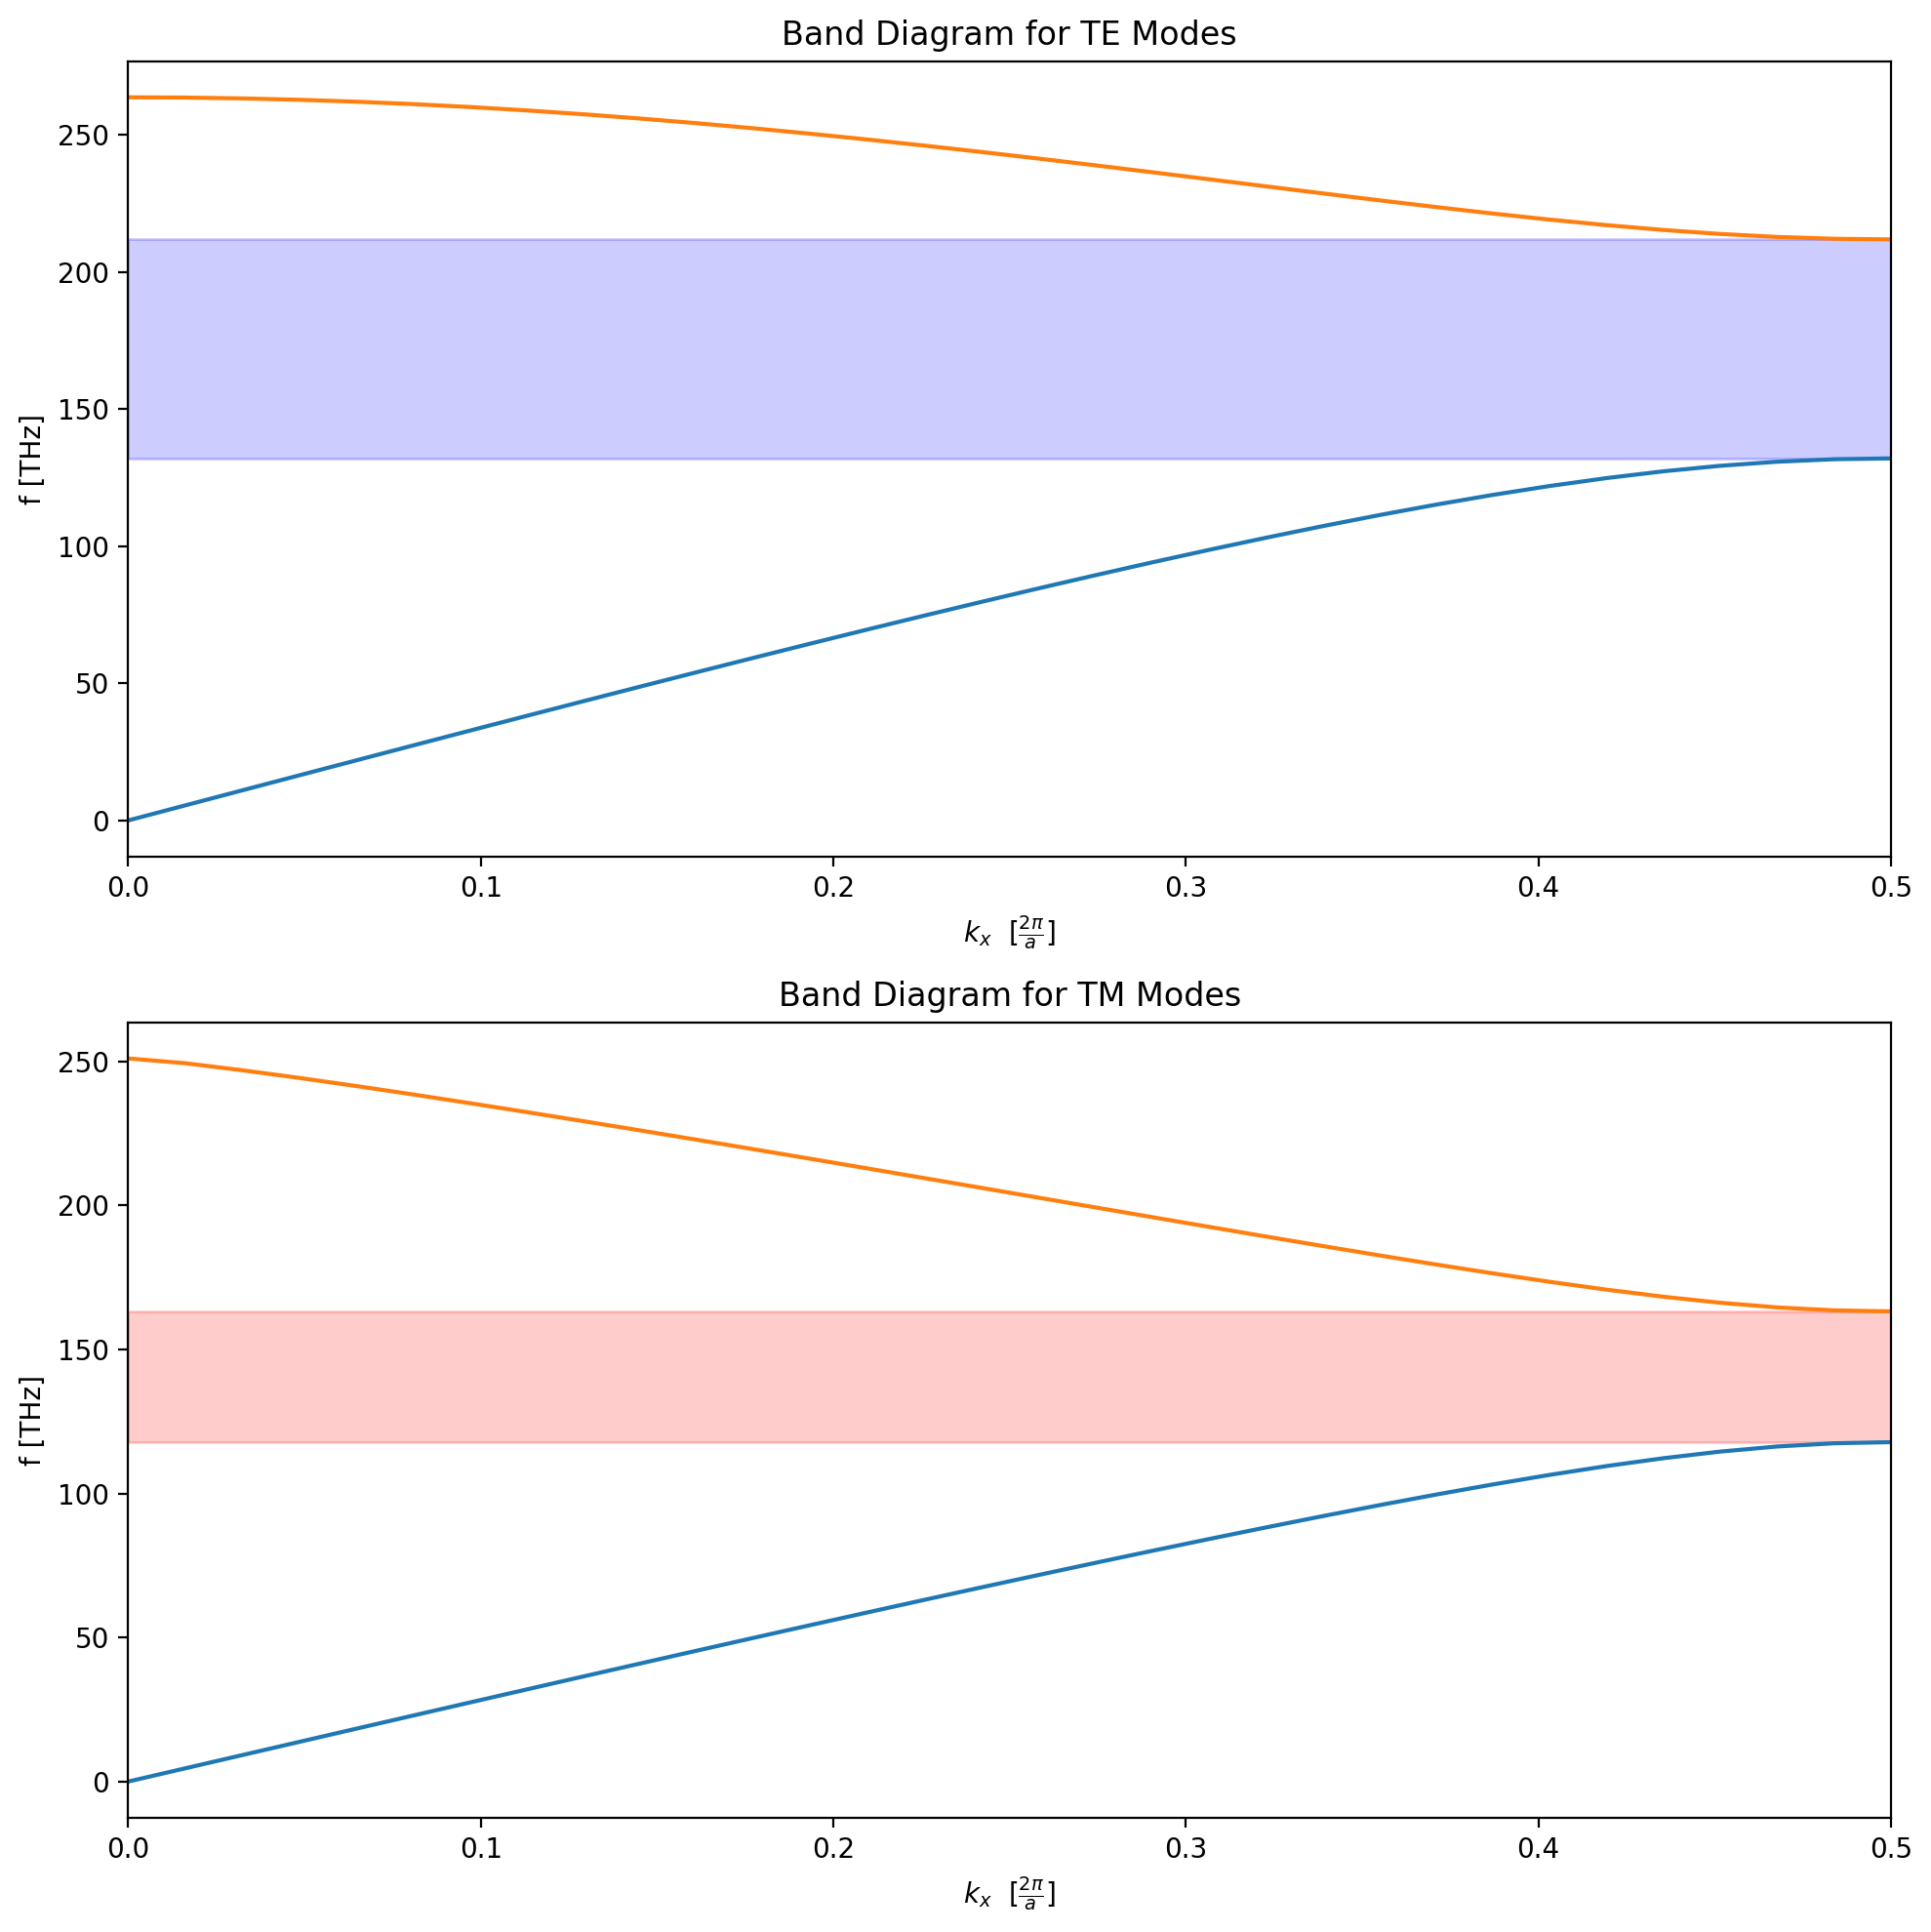

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.2,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.433333, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516129

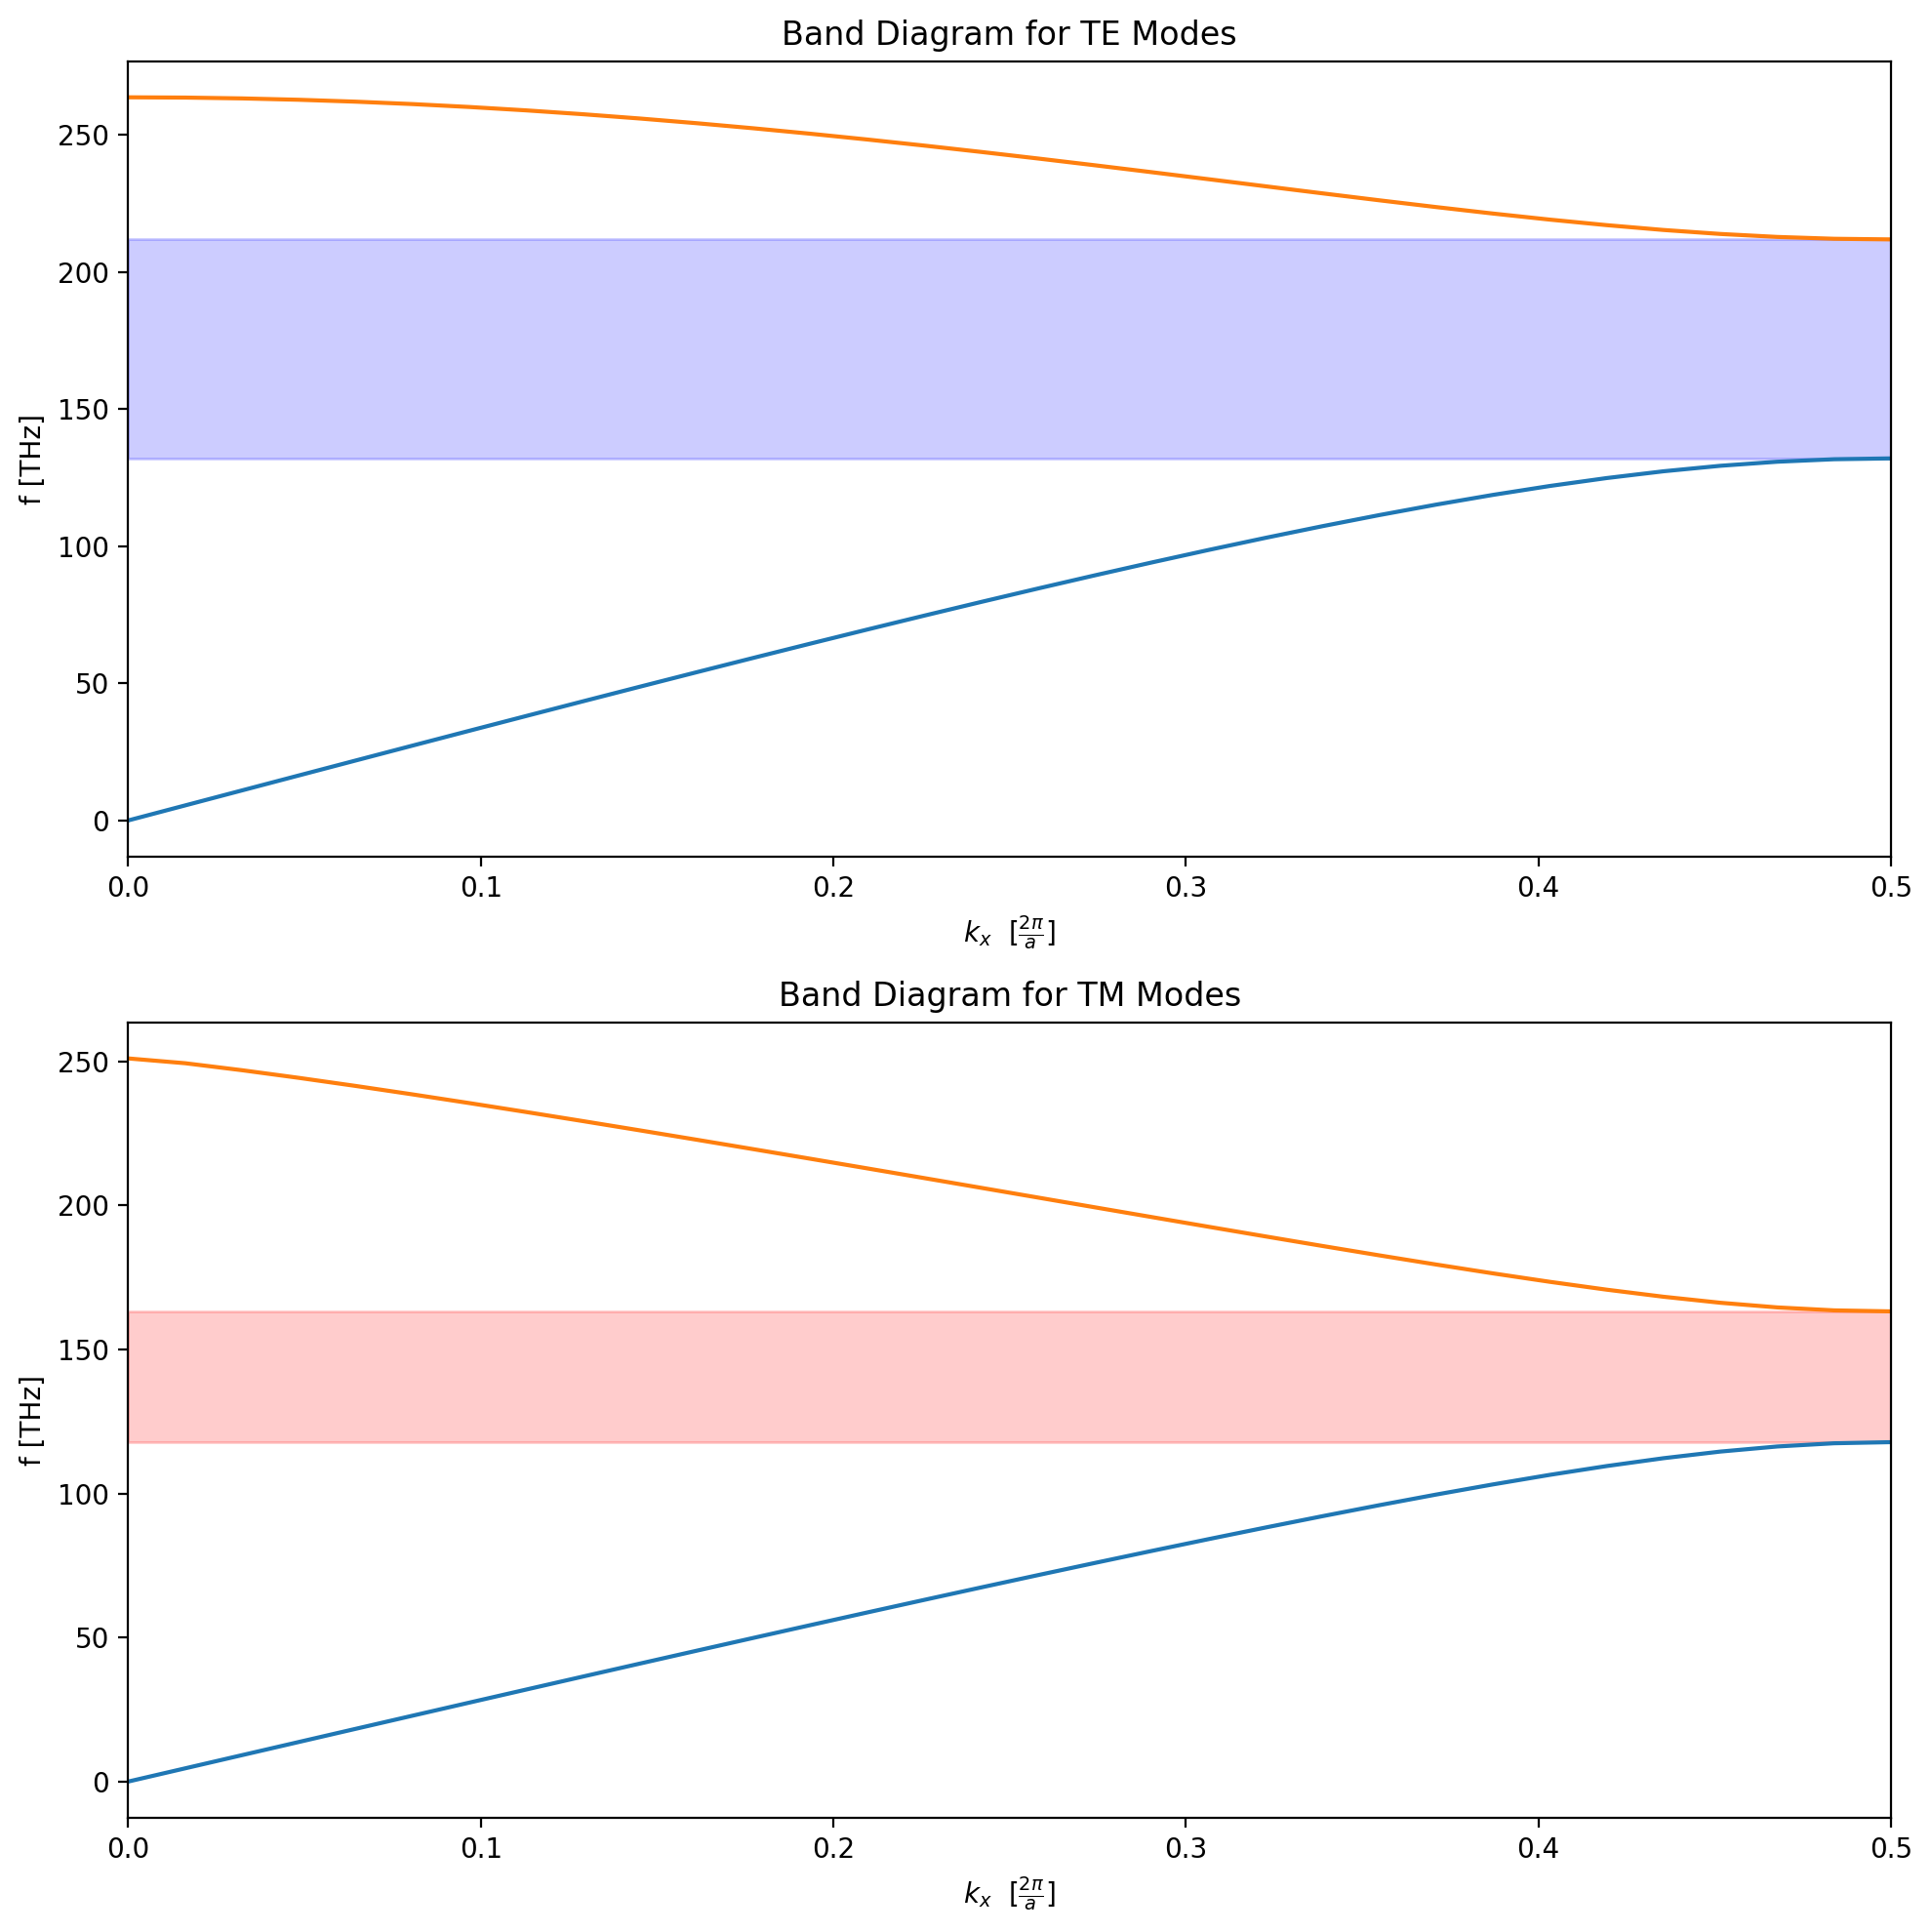

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.2,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.433333, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516129

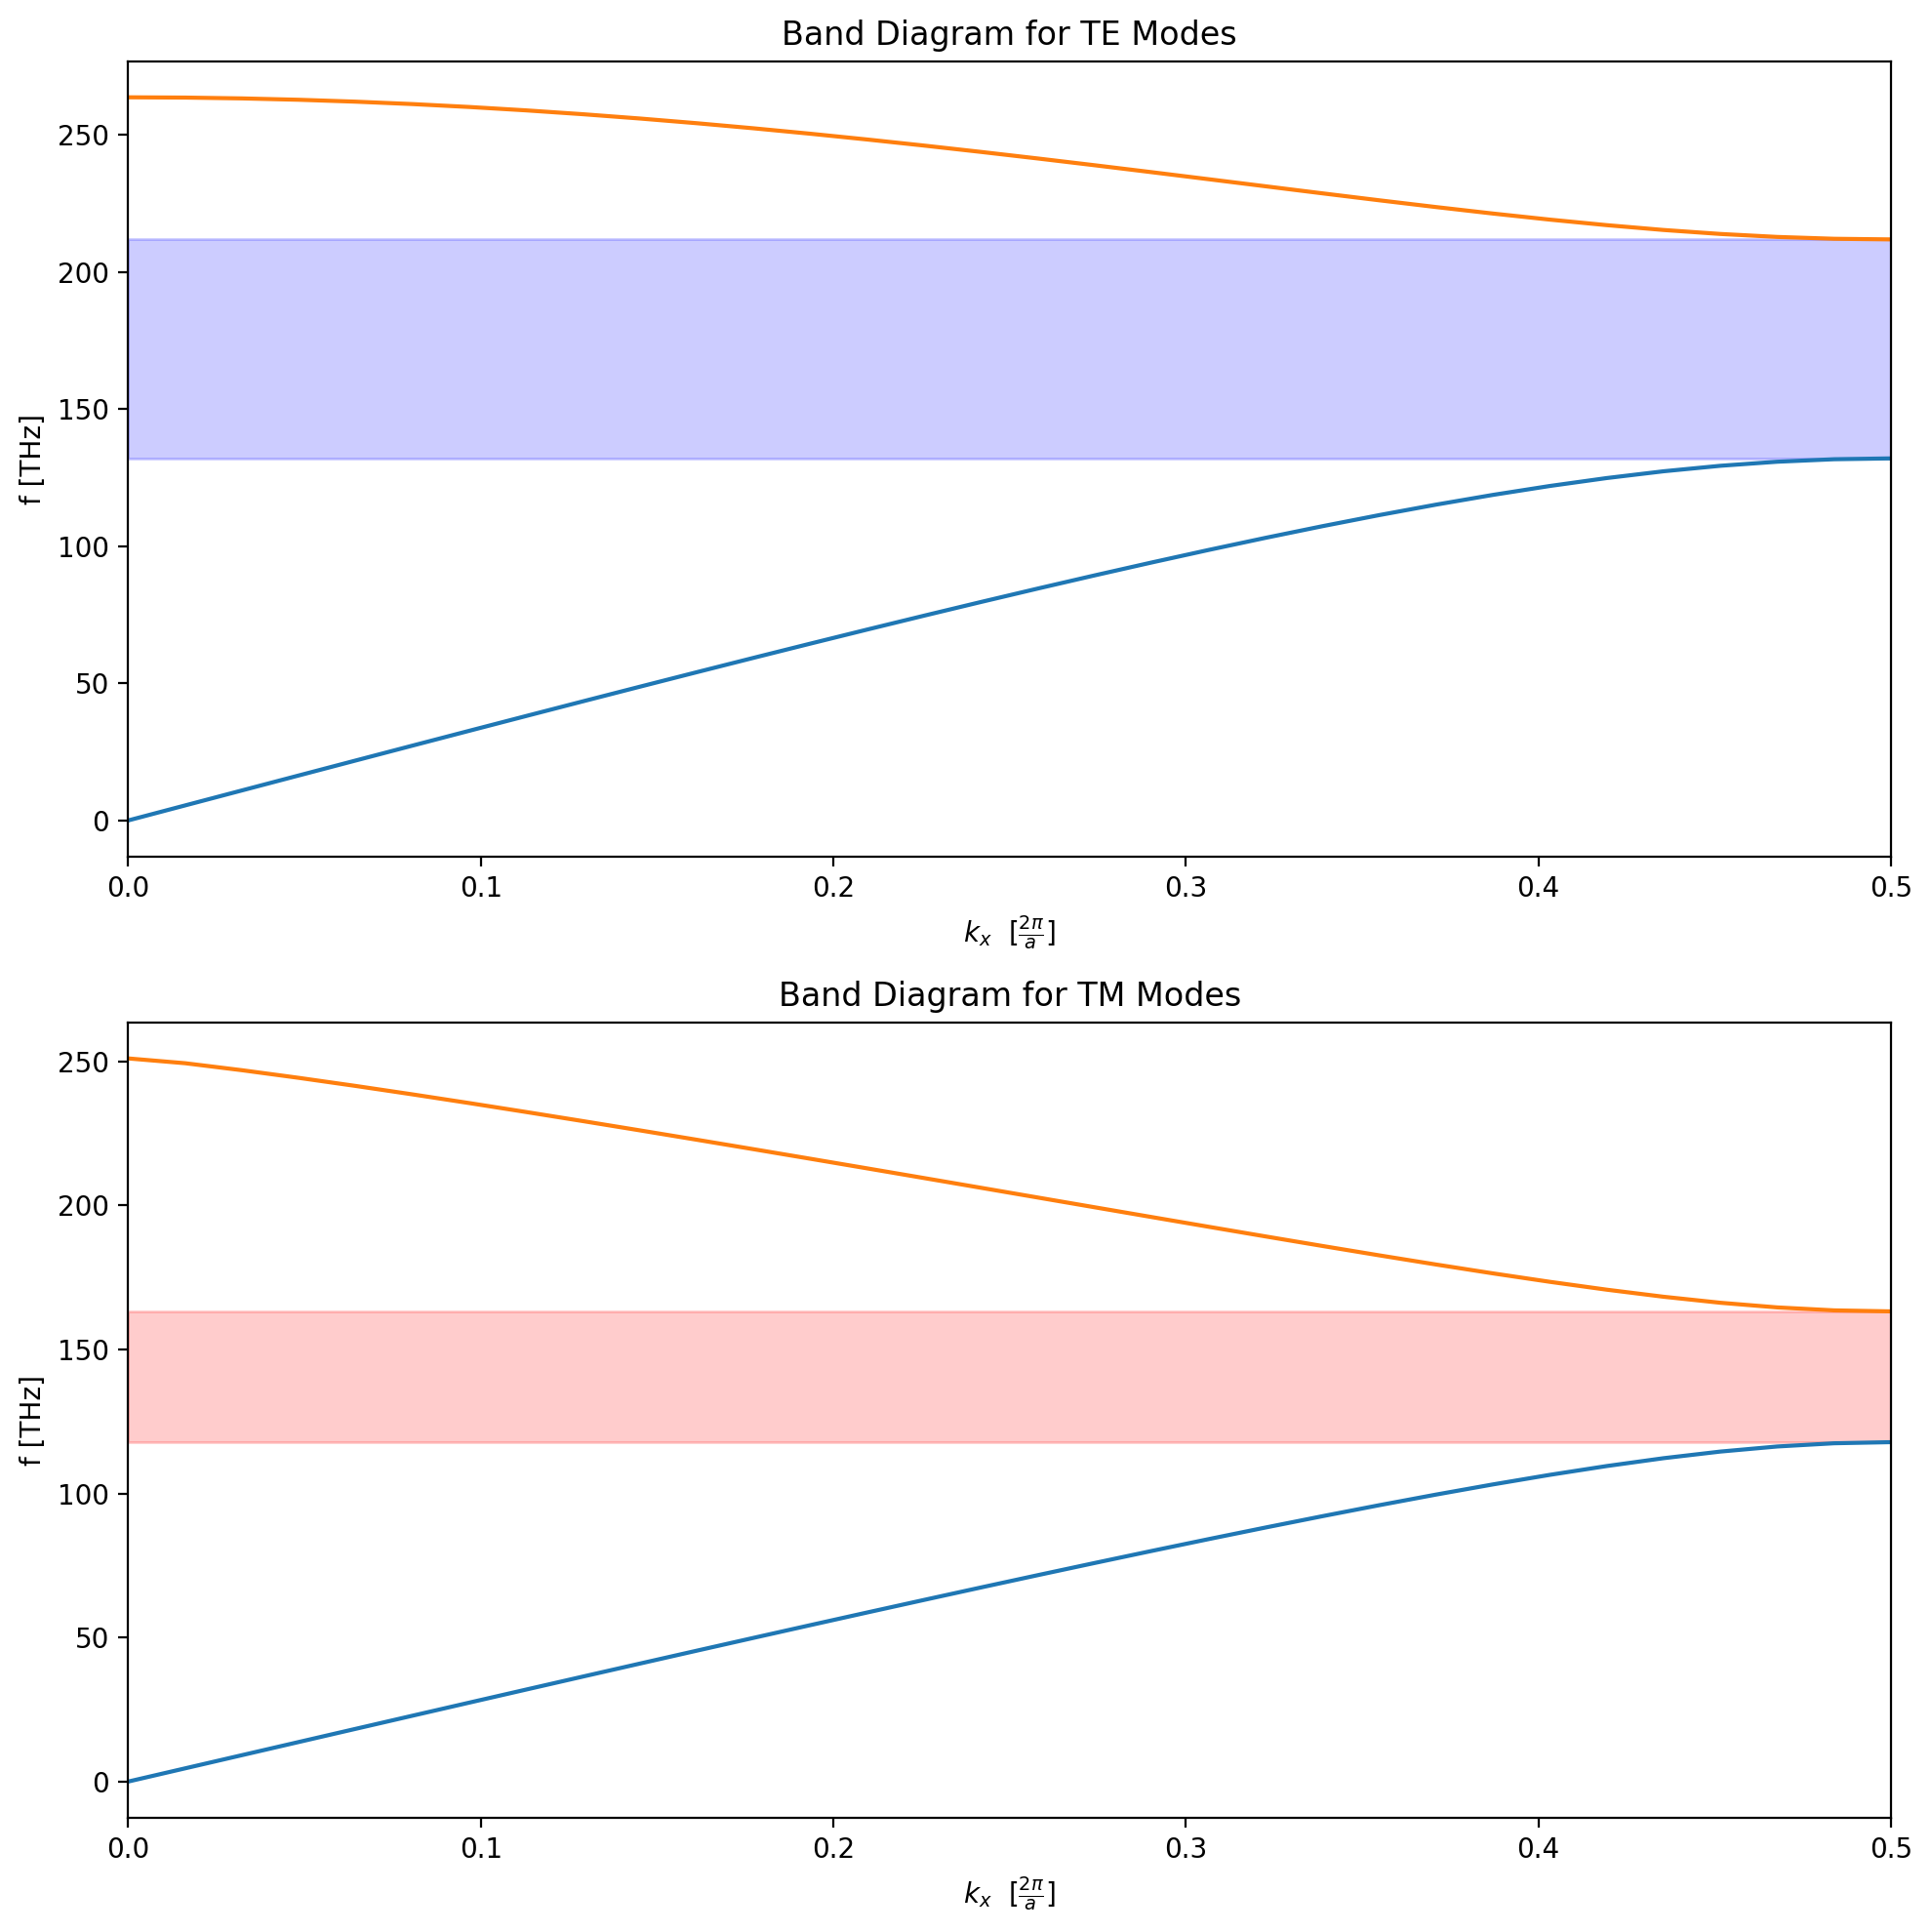

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.20031,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.433487, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

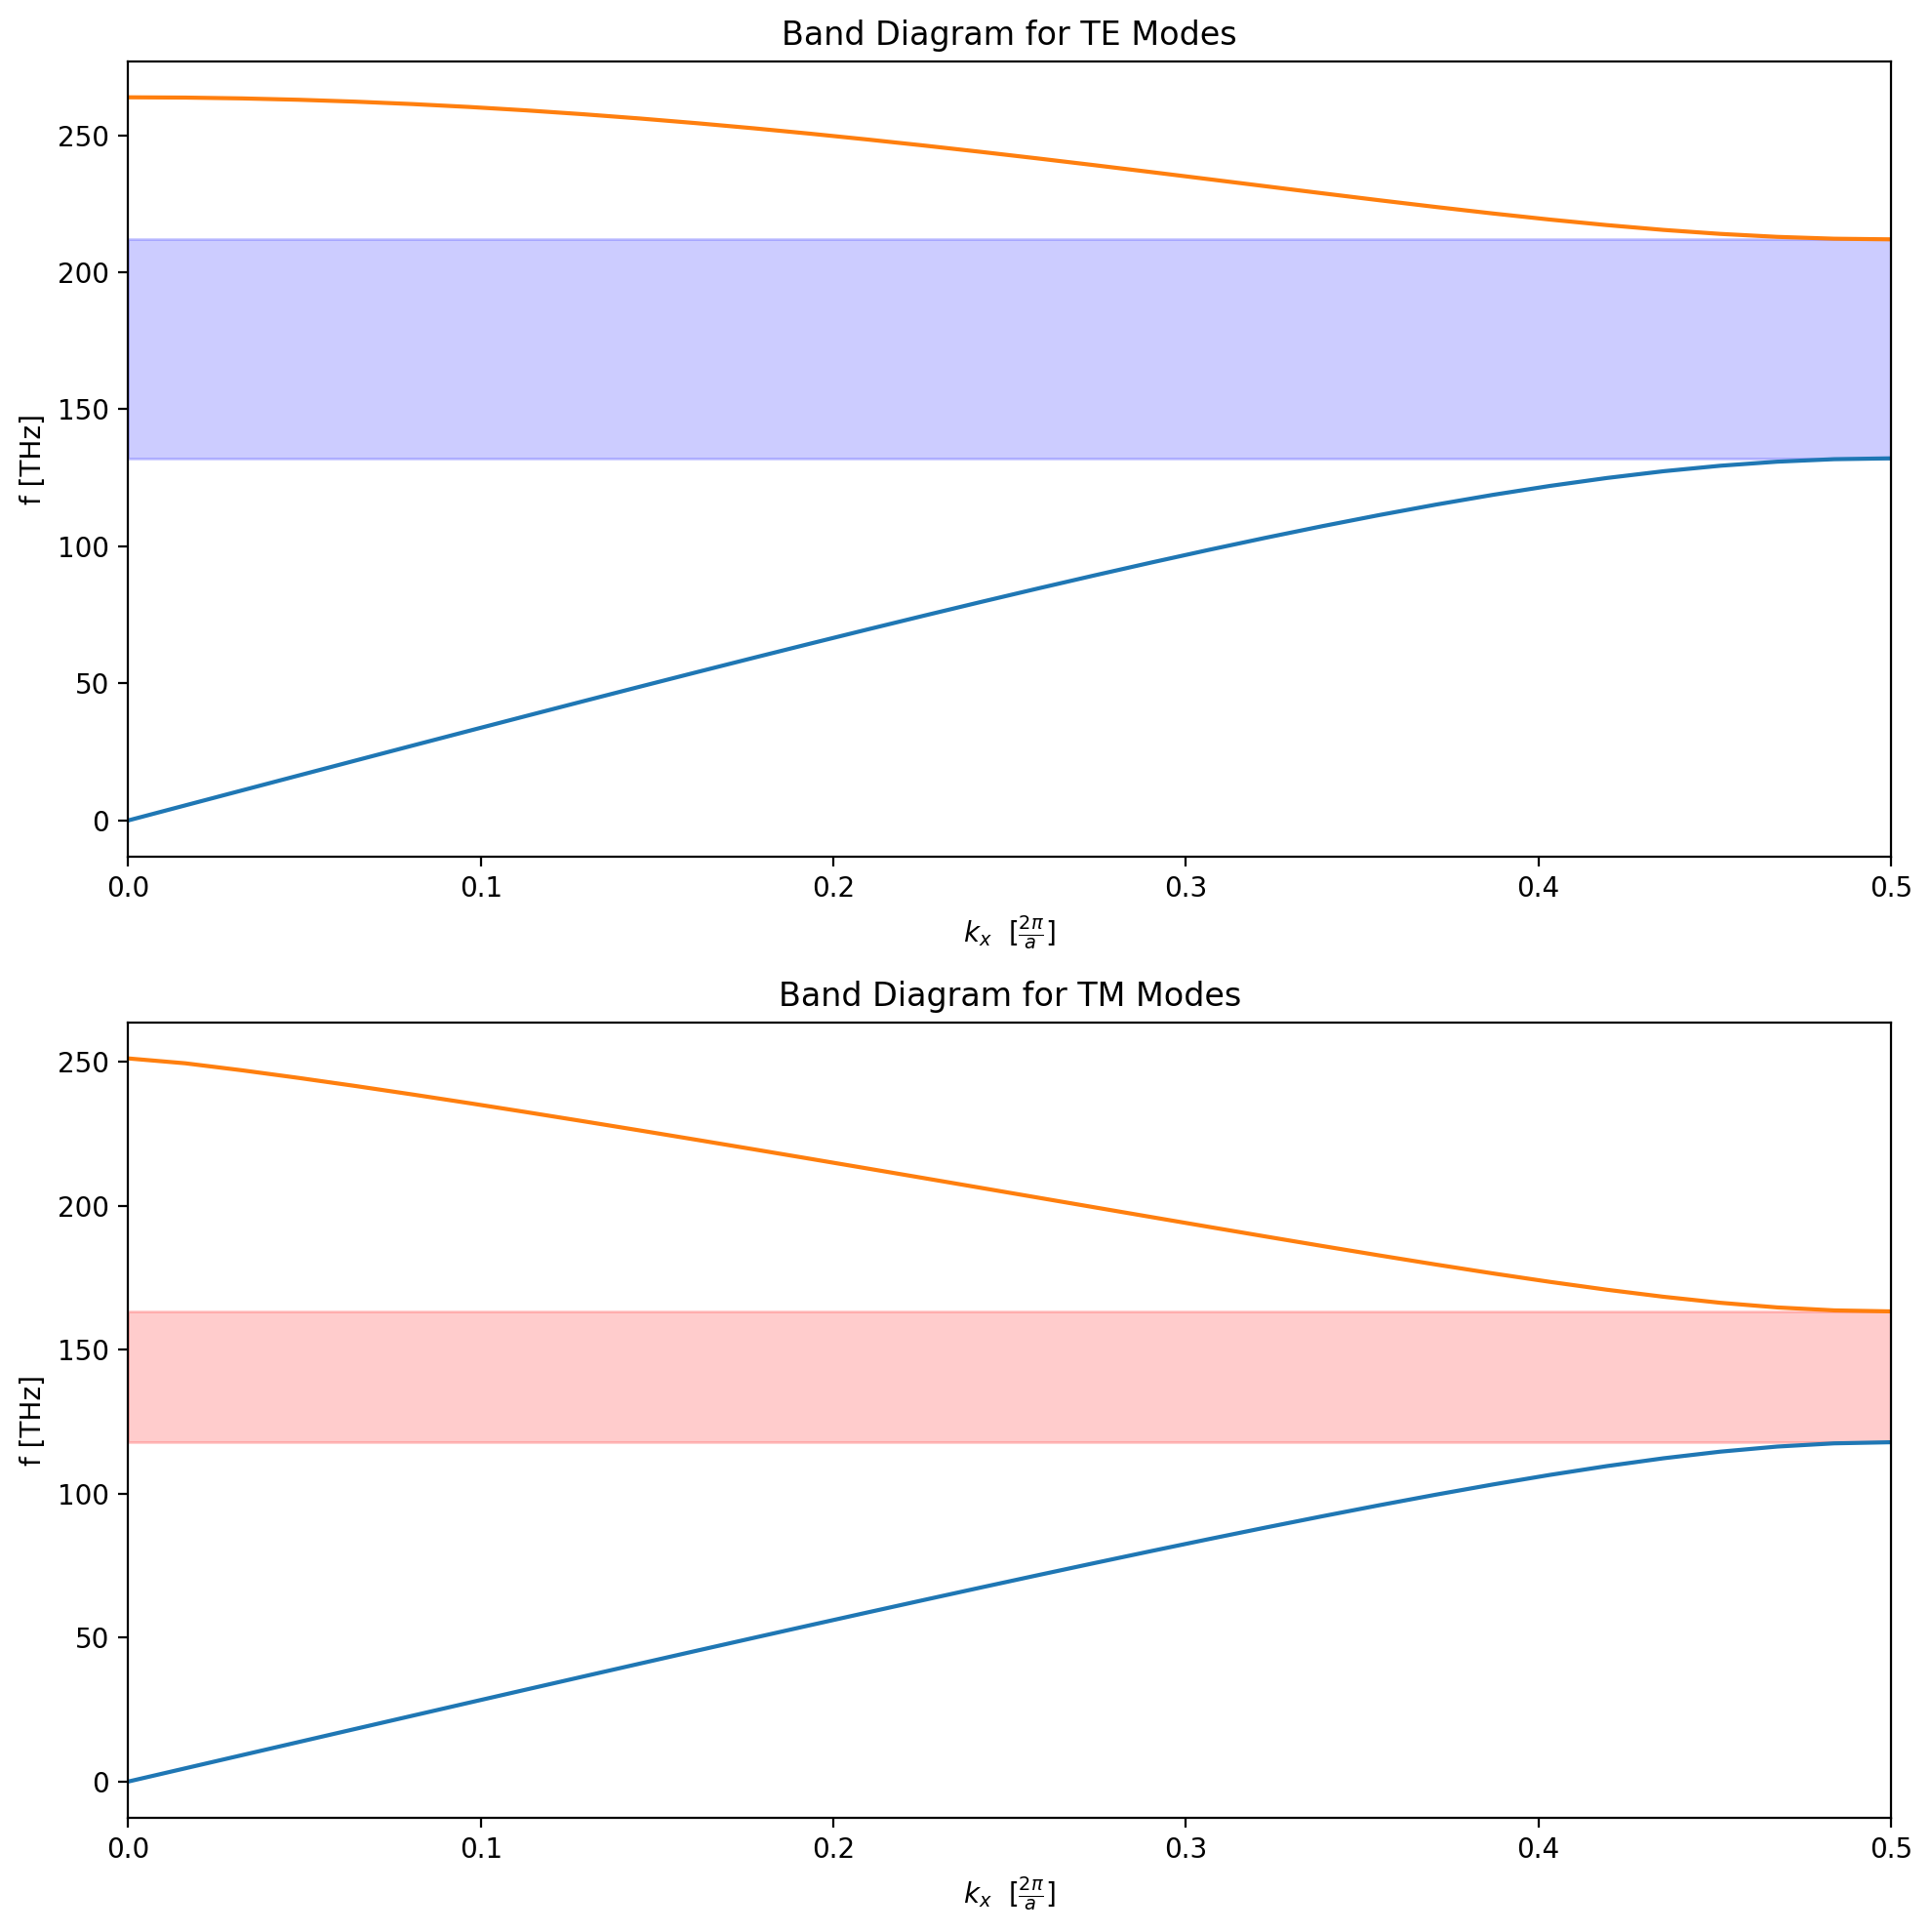

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.20031,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.433487, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

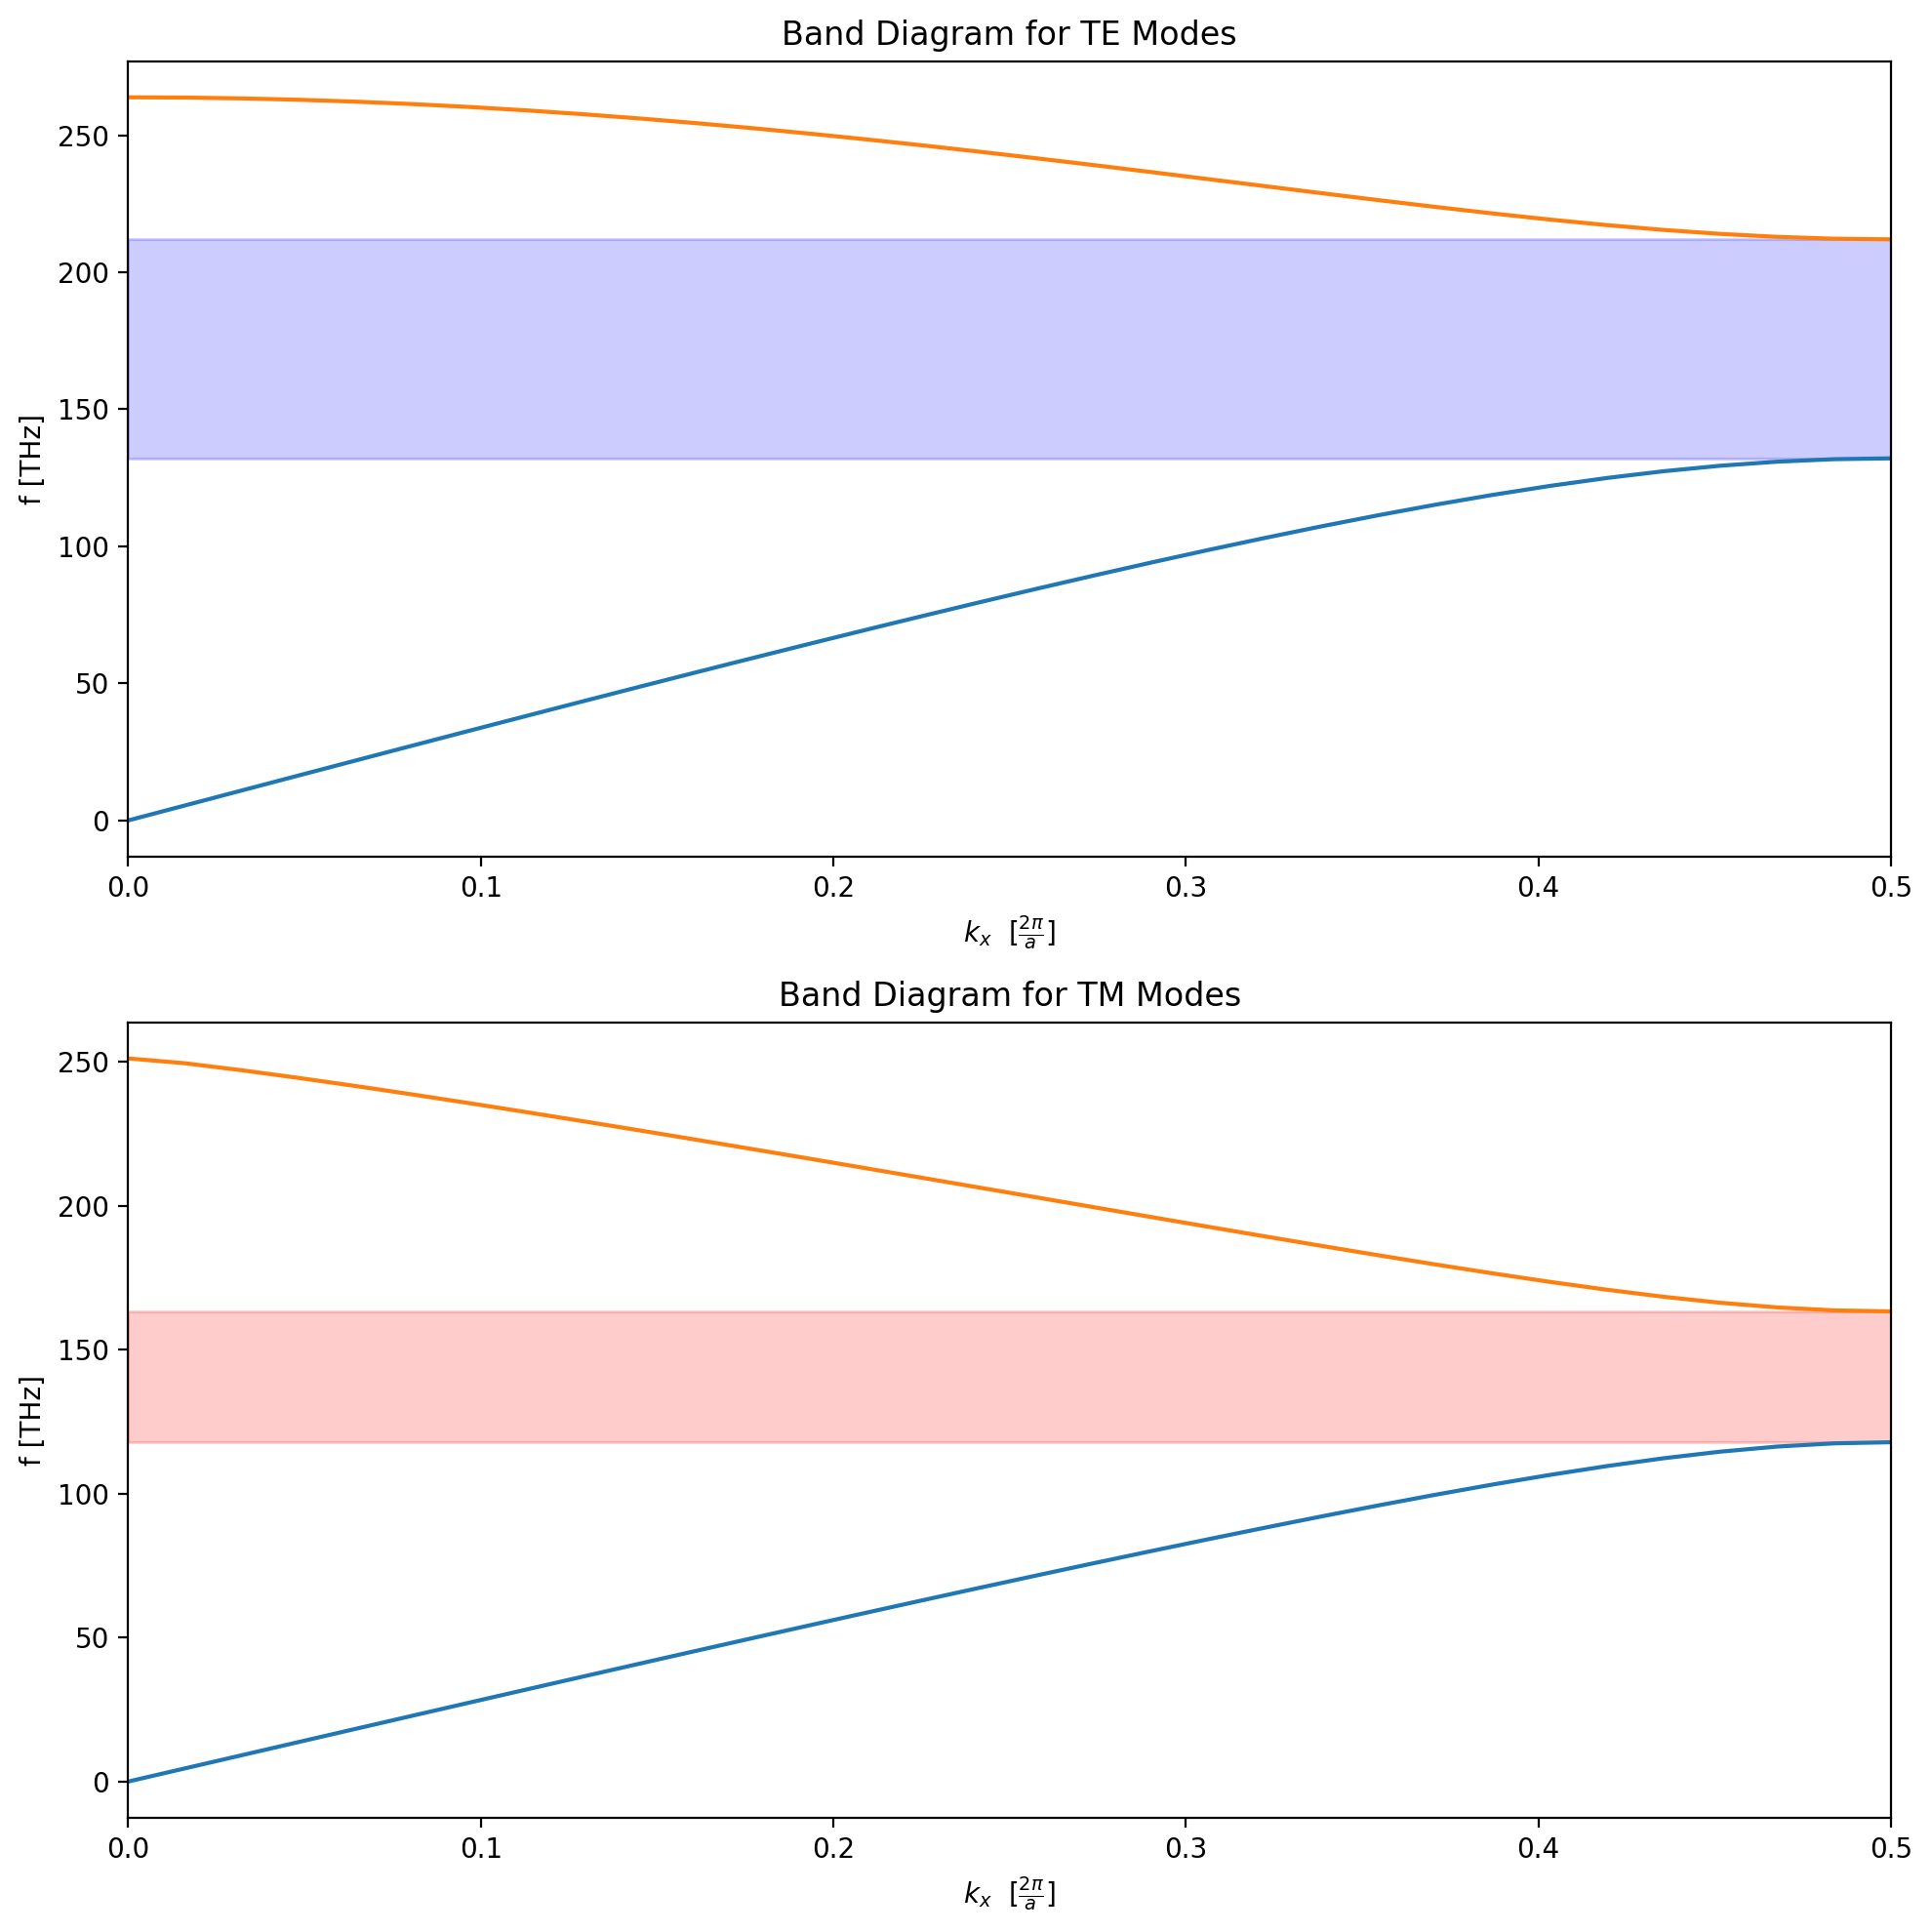

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.20031,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.433487, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

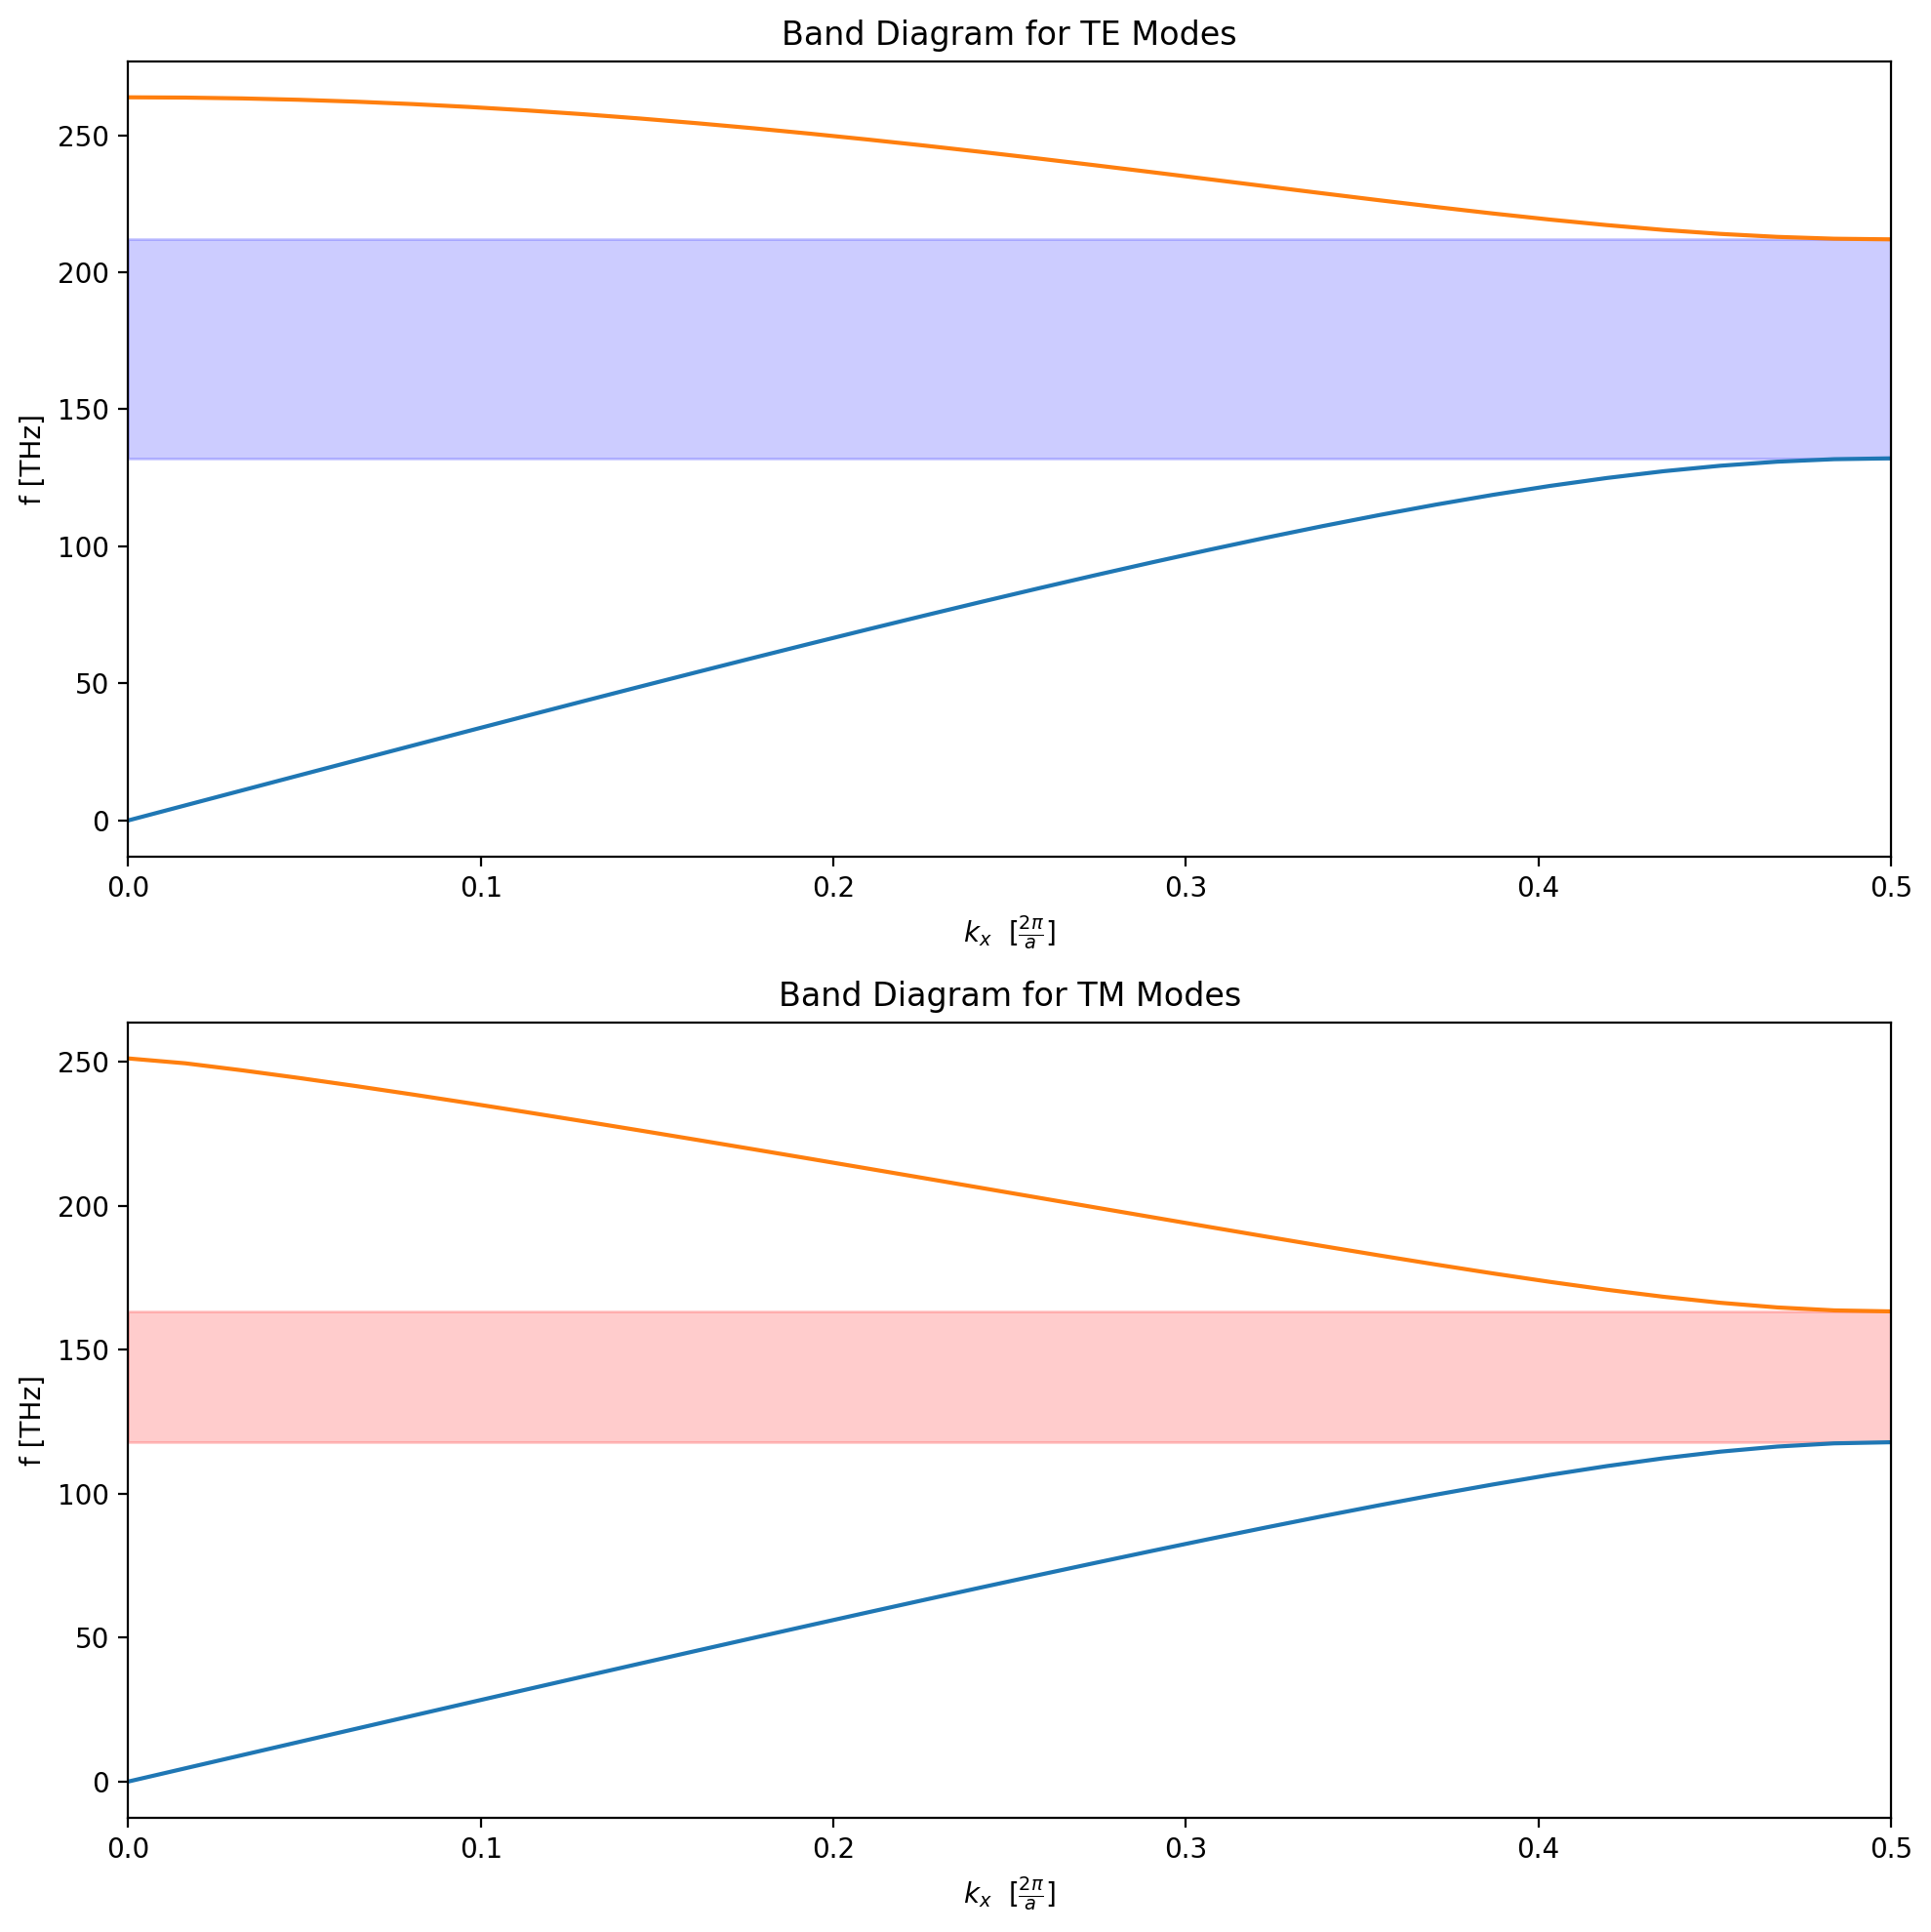

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.20184,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.434255, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

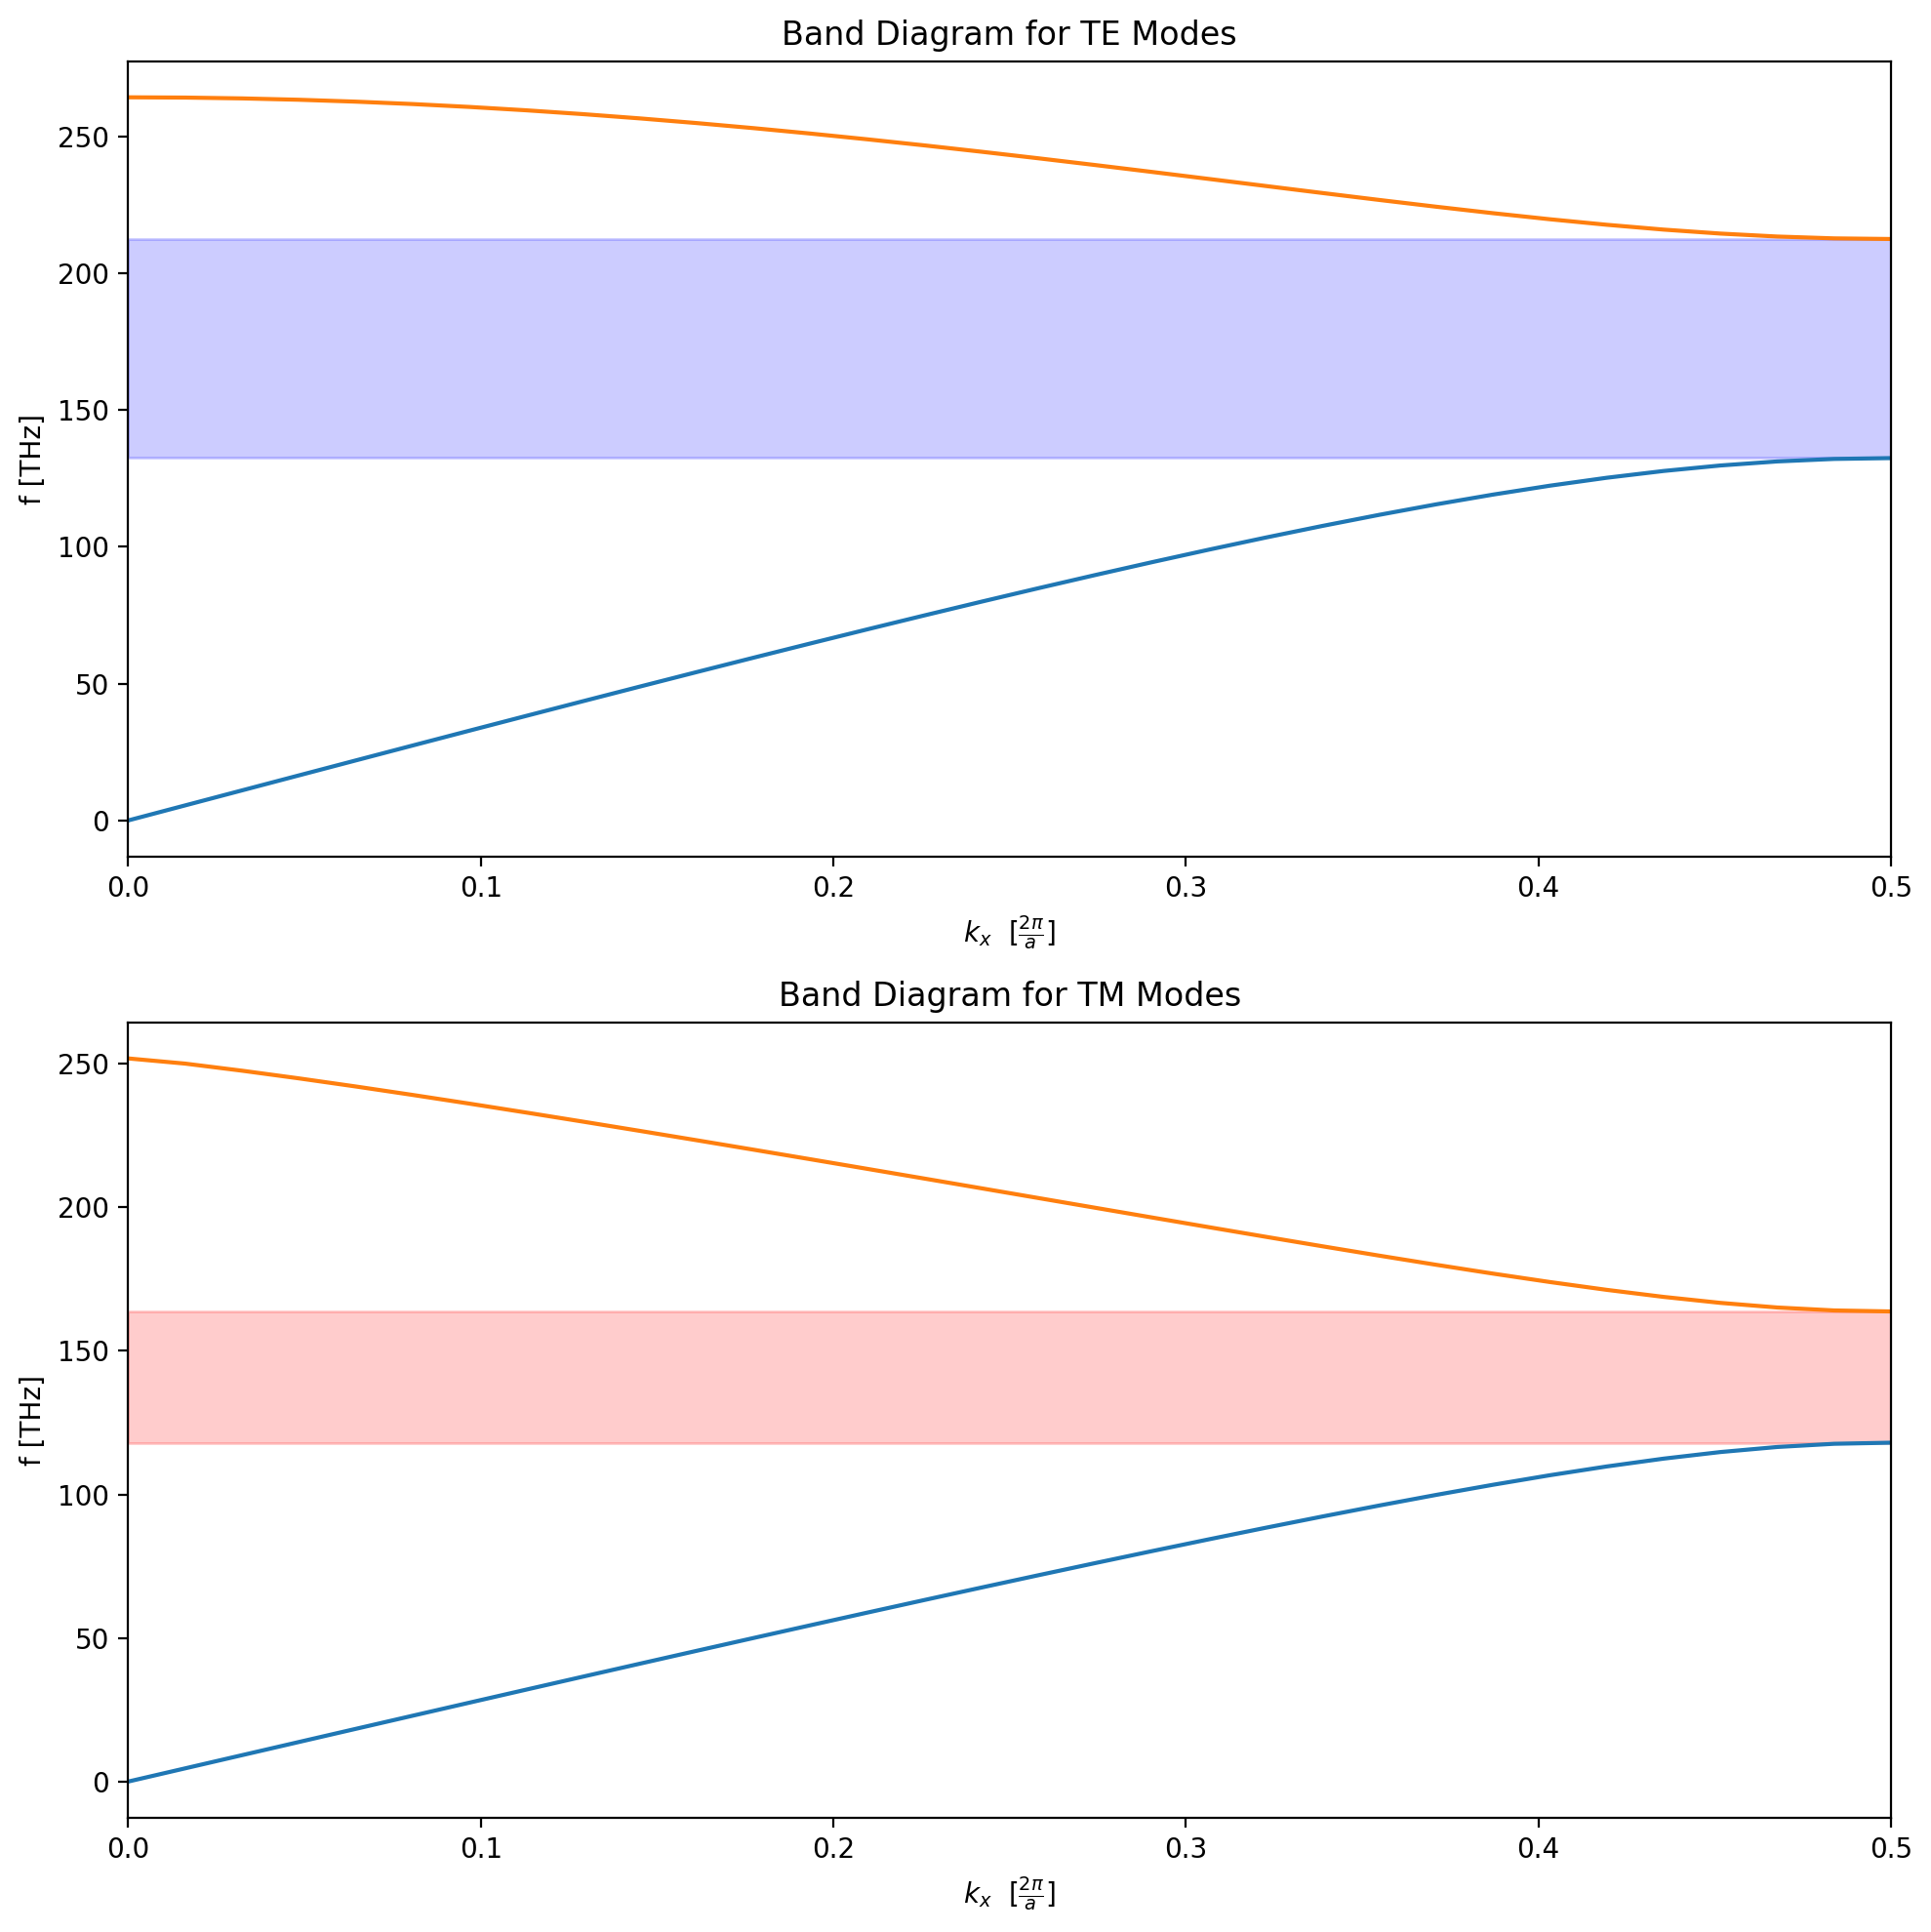

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.20184,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.434255, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

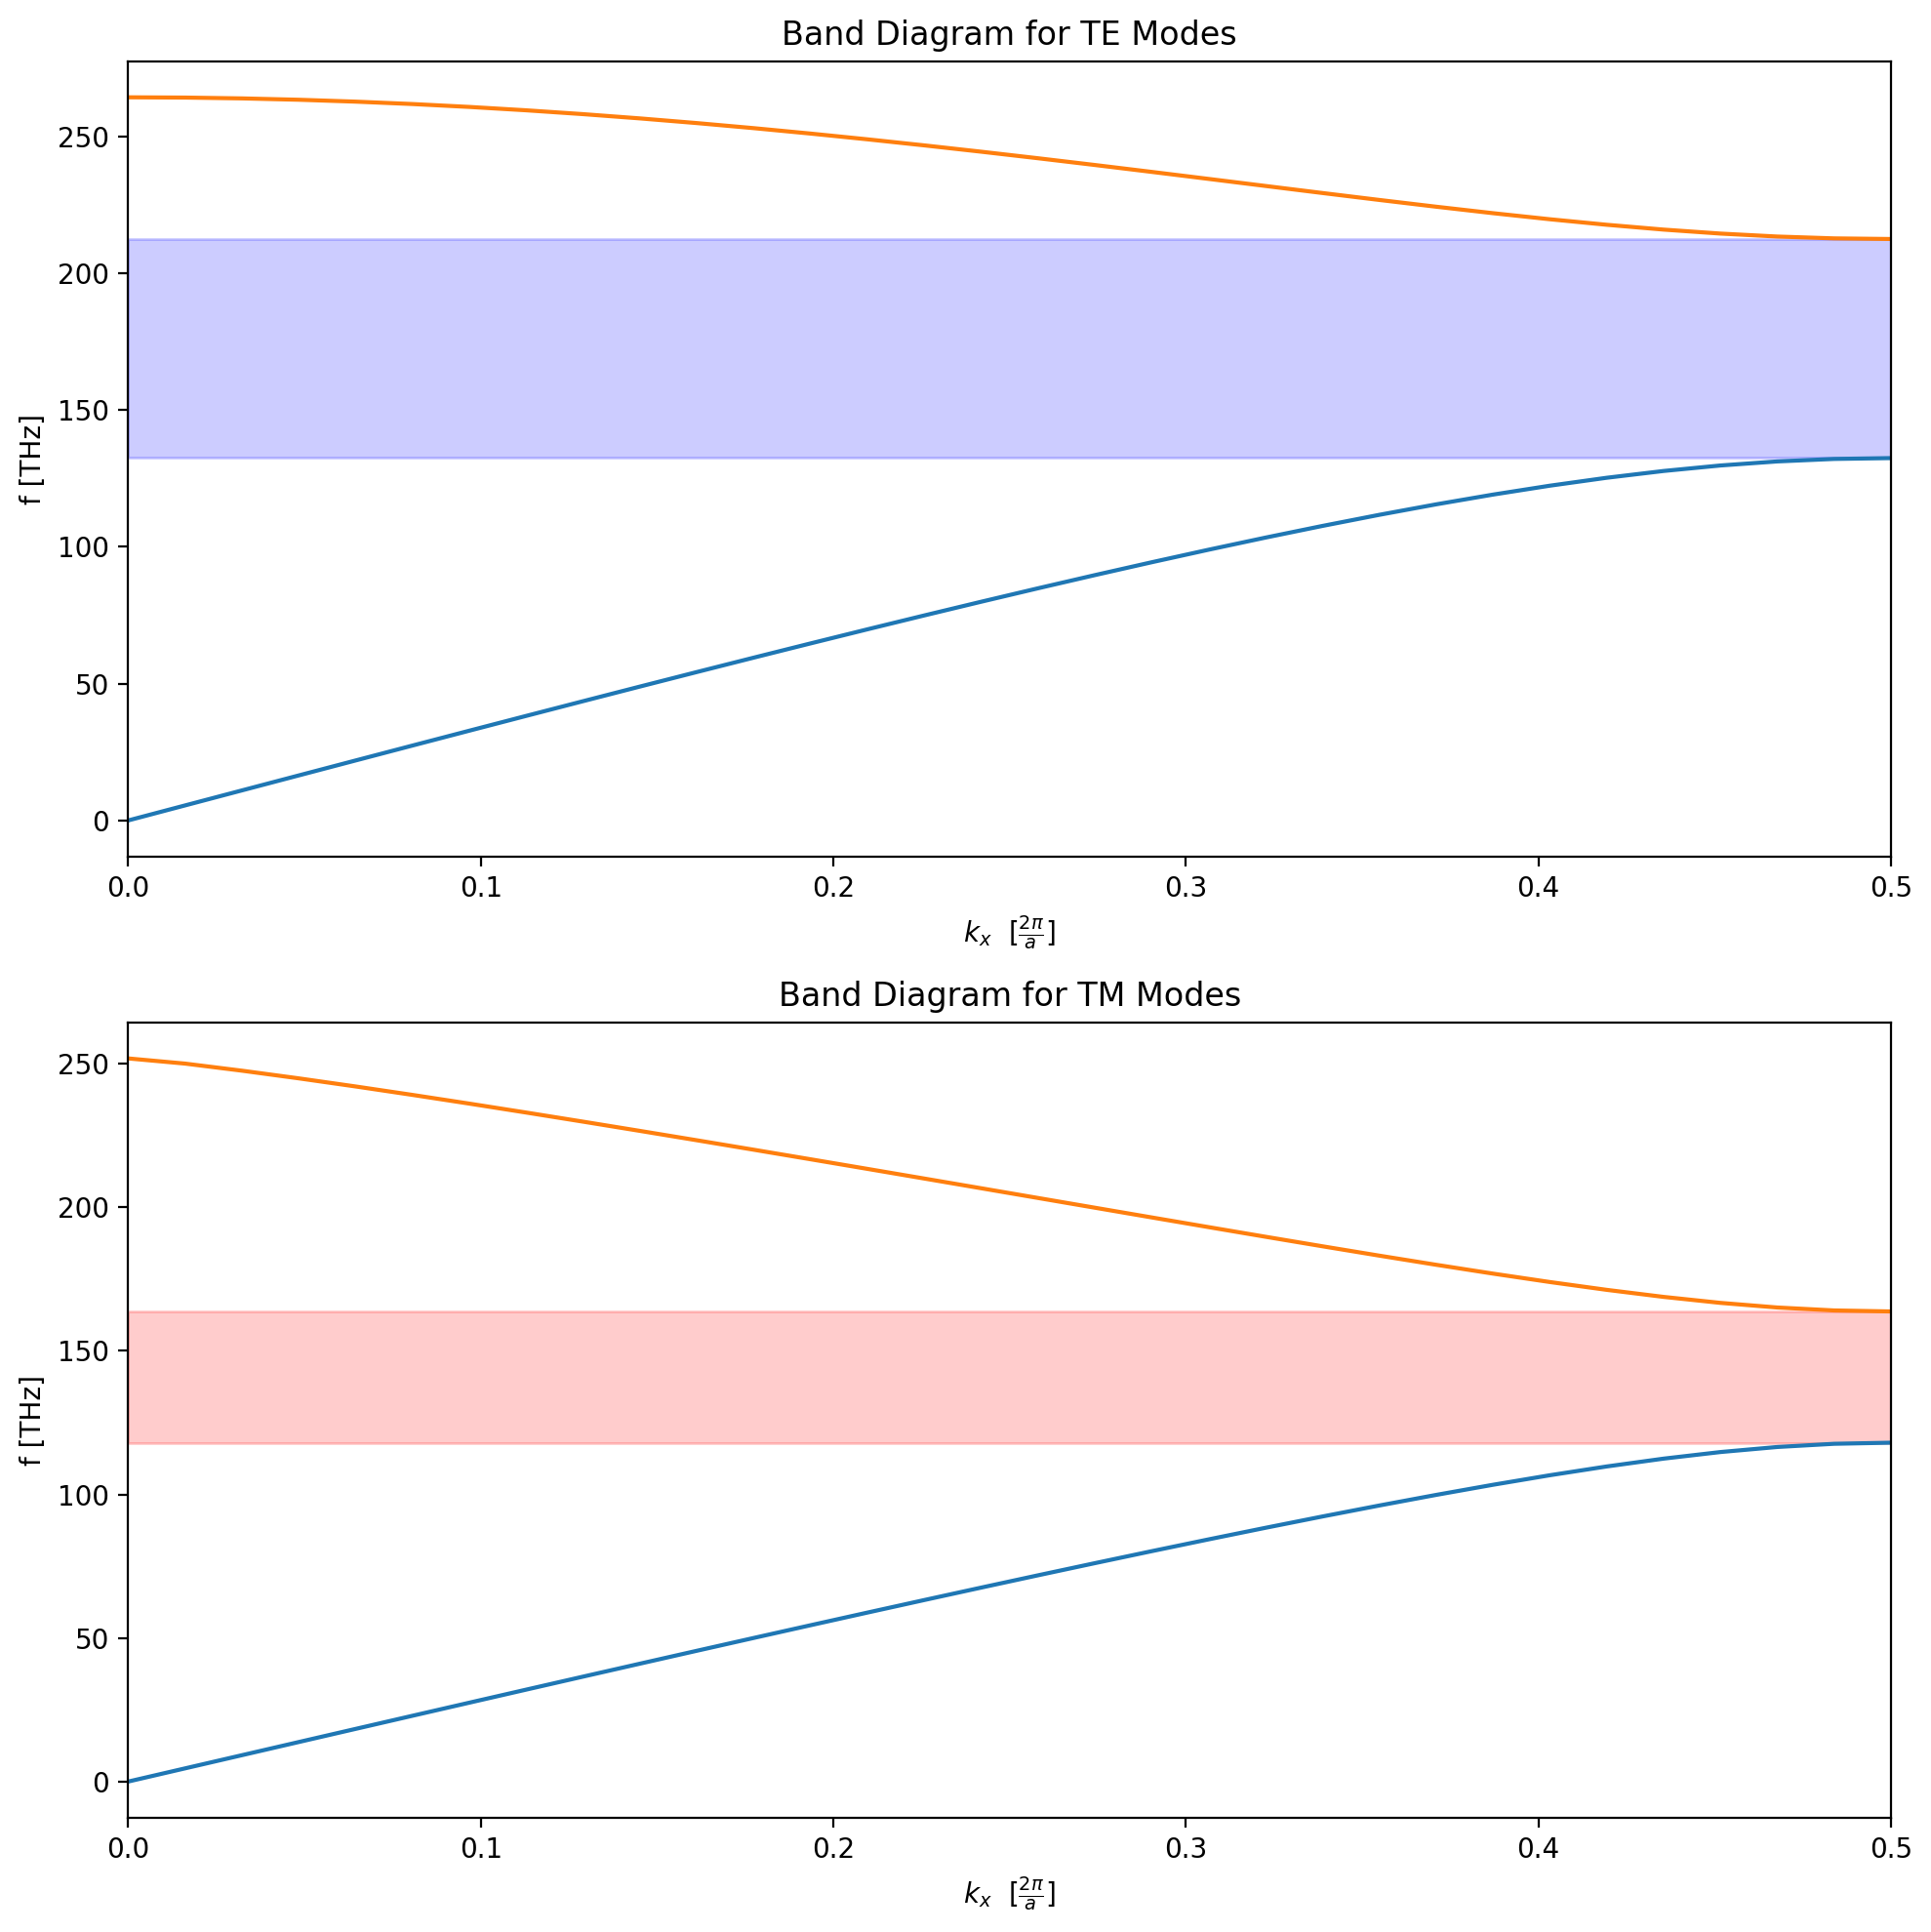

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.20184,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.434255, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

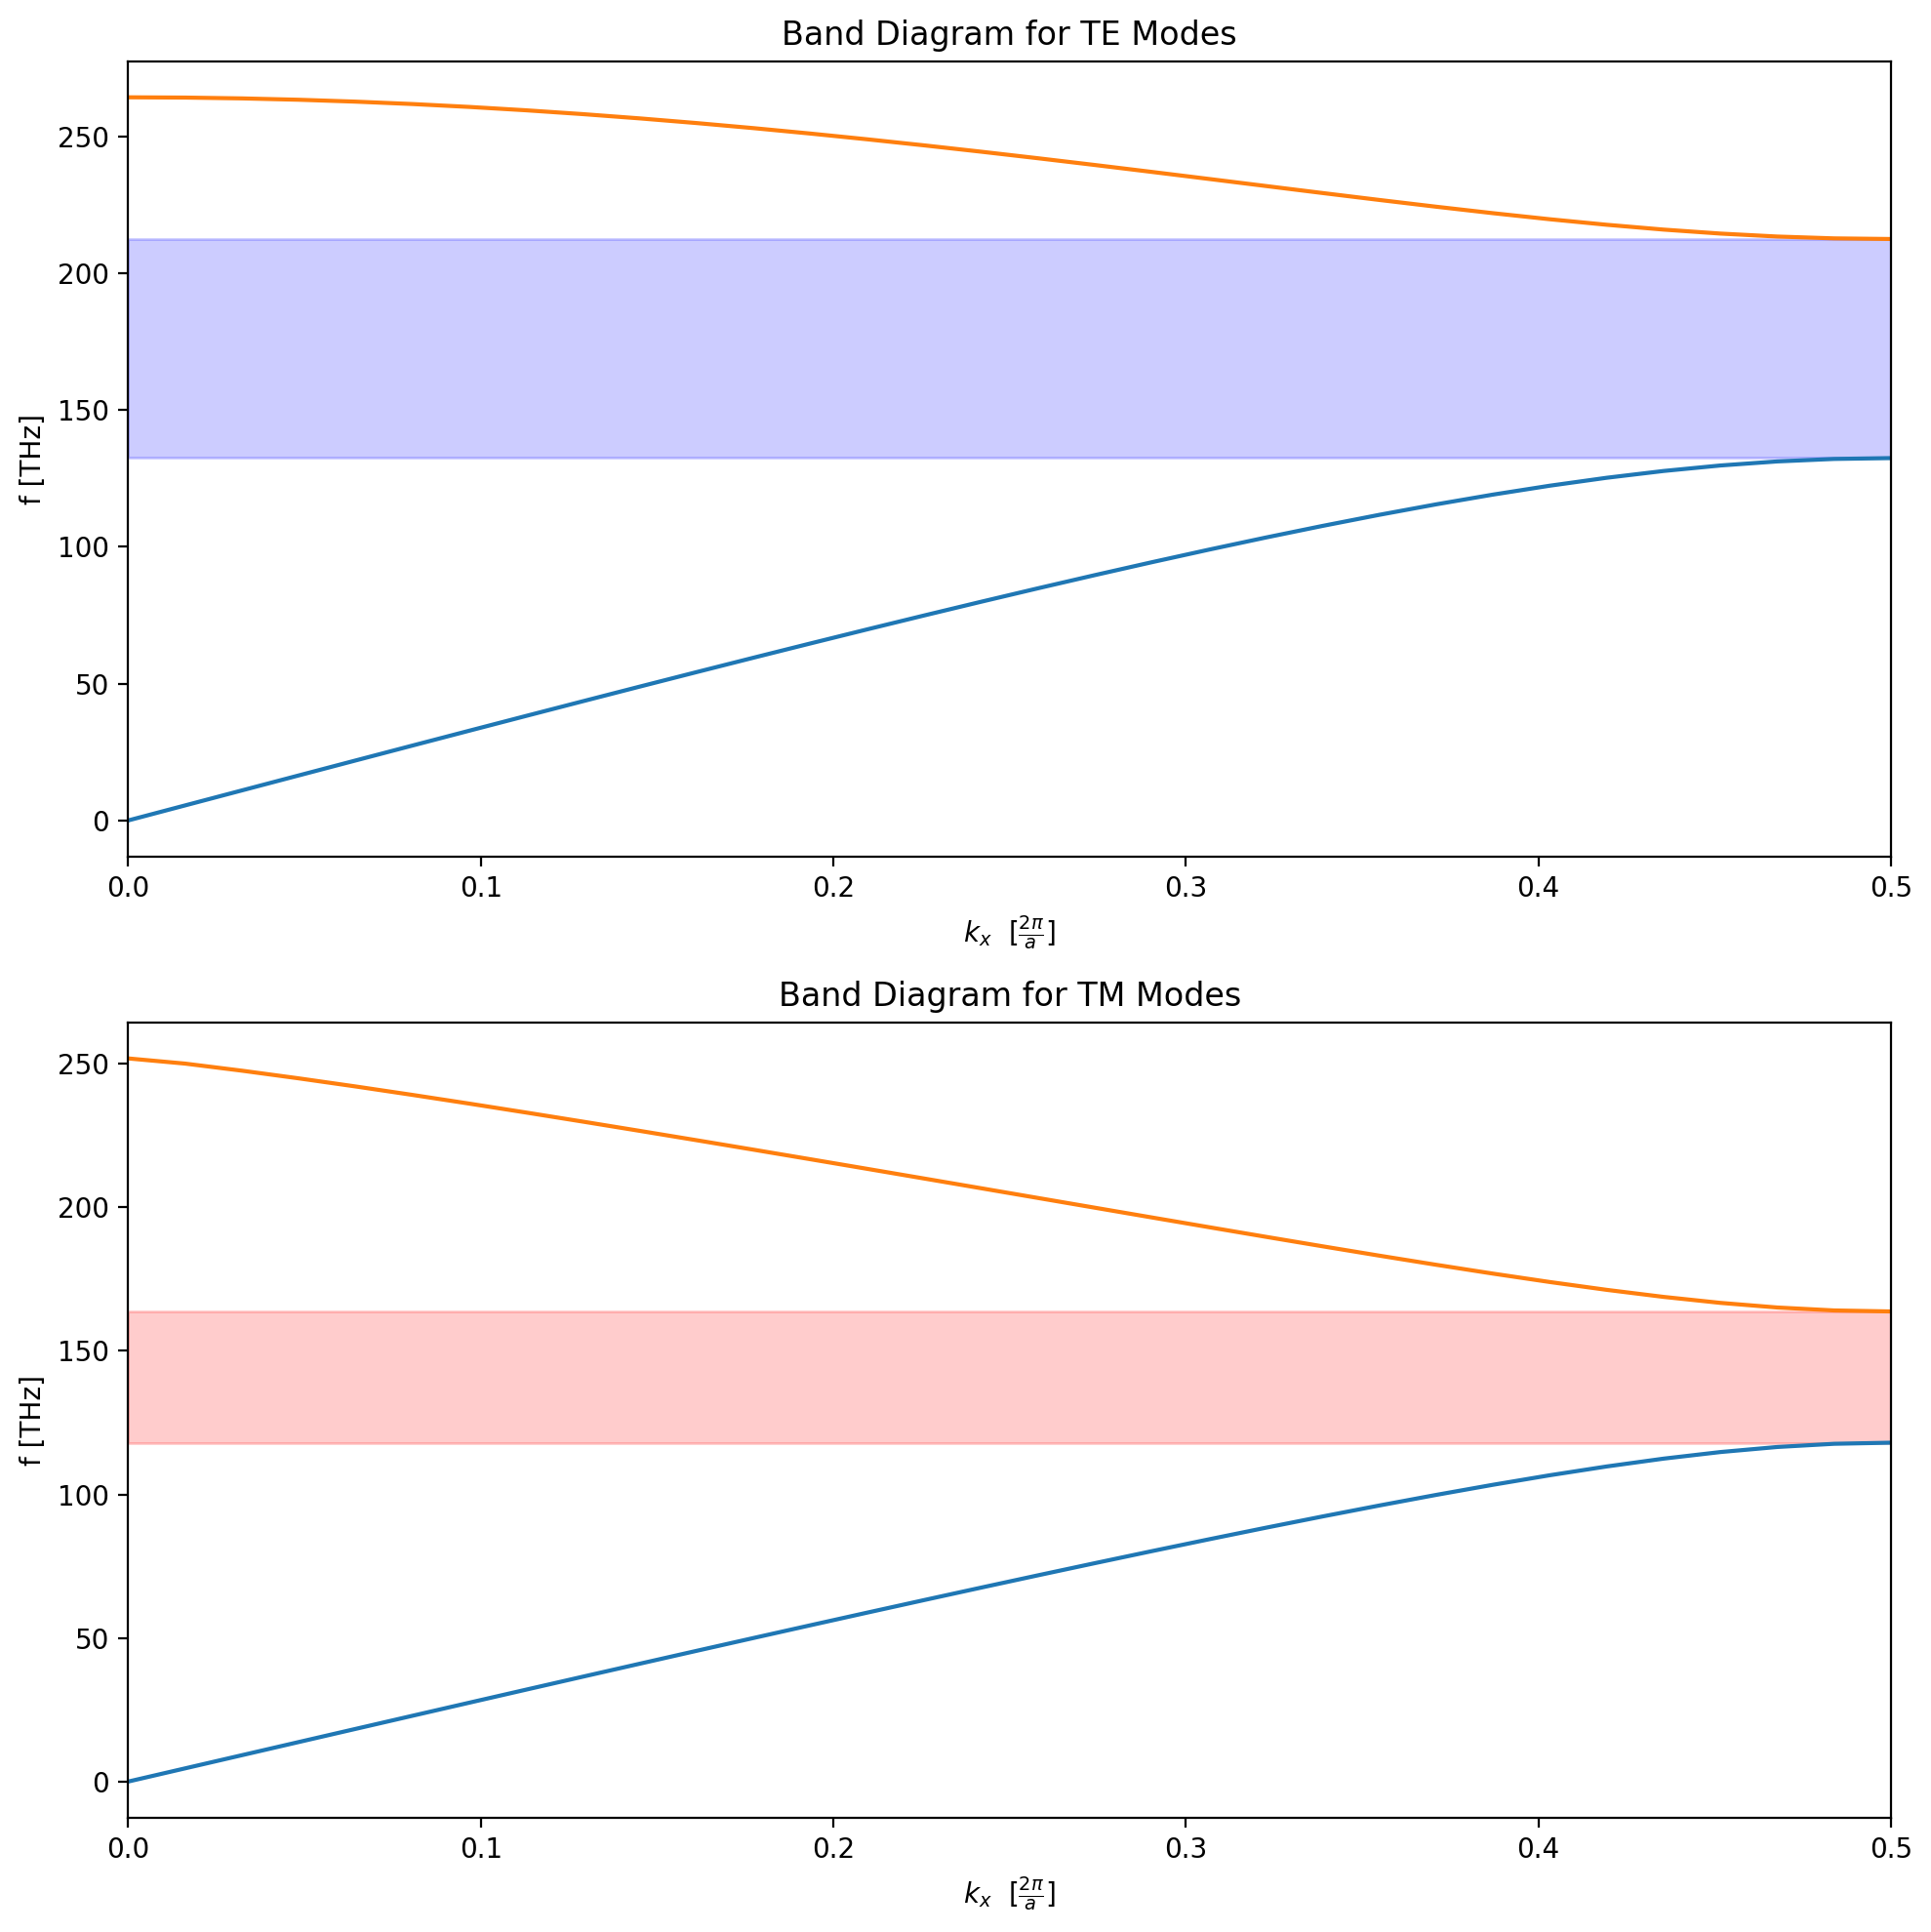

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.20937,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.438019, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

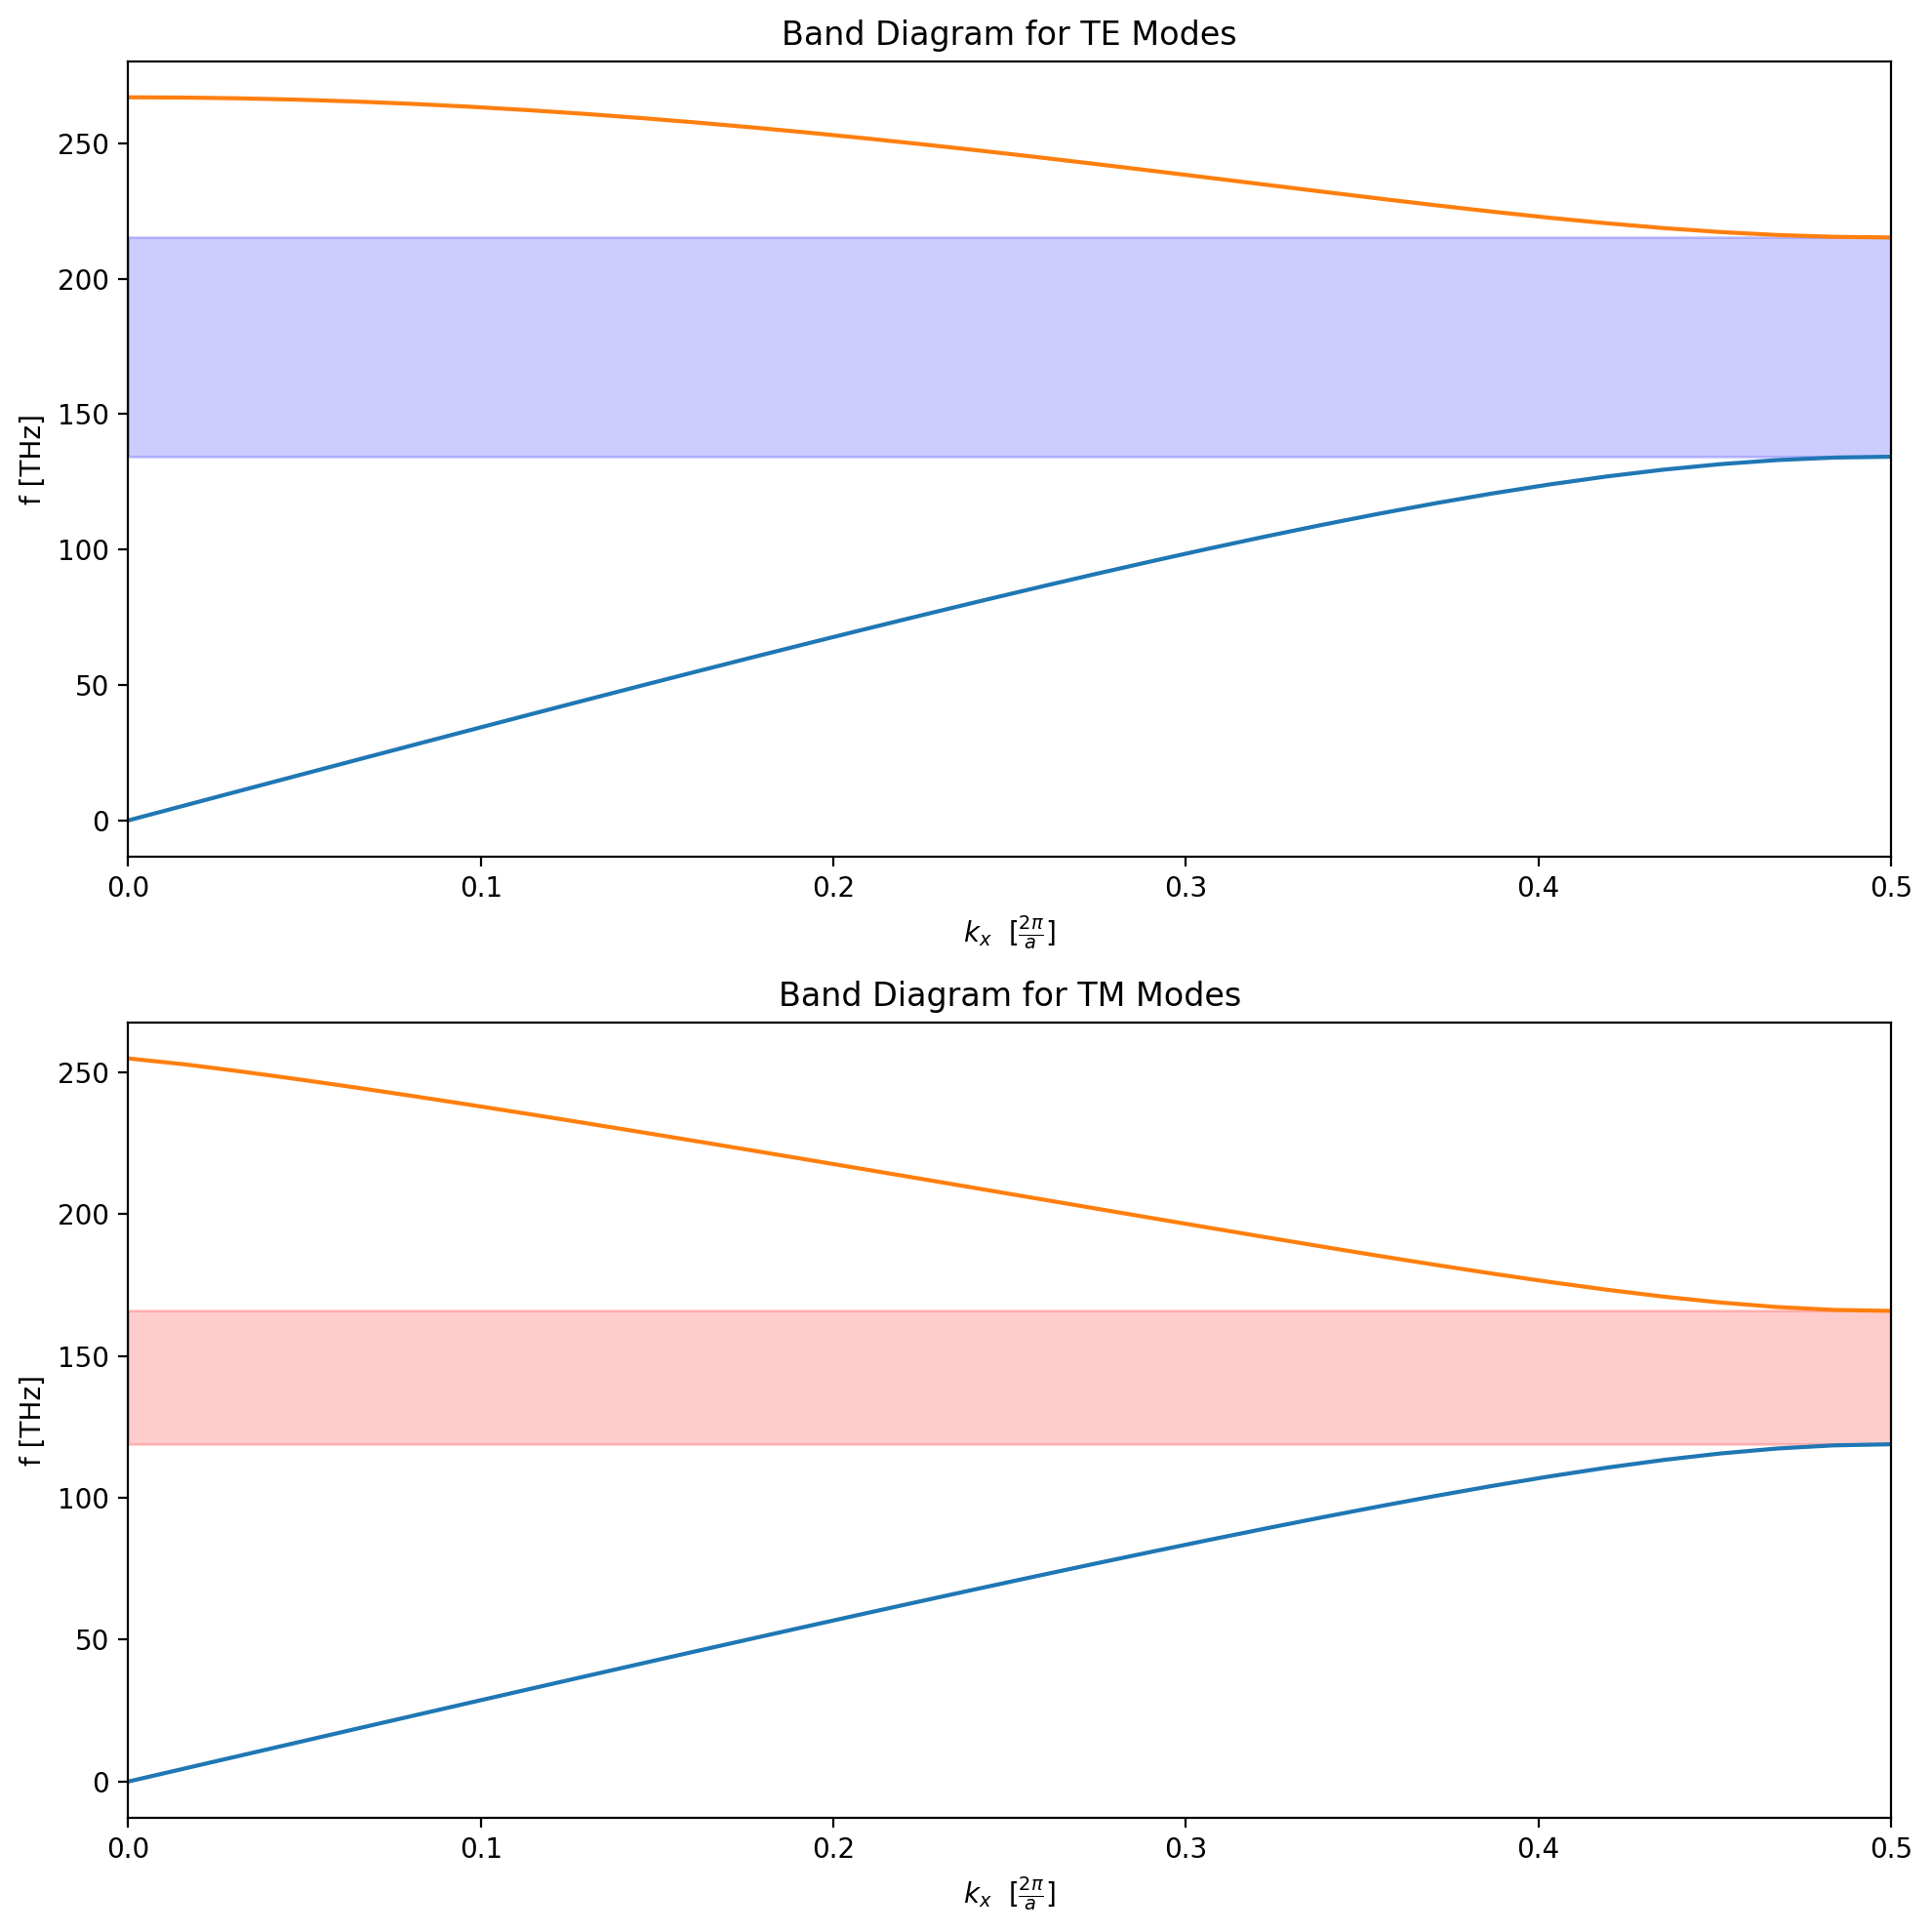

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.20937,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.438019, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

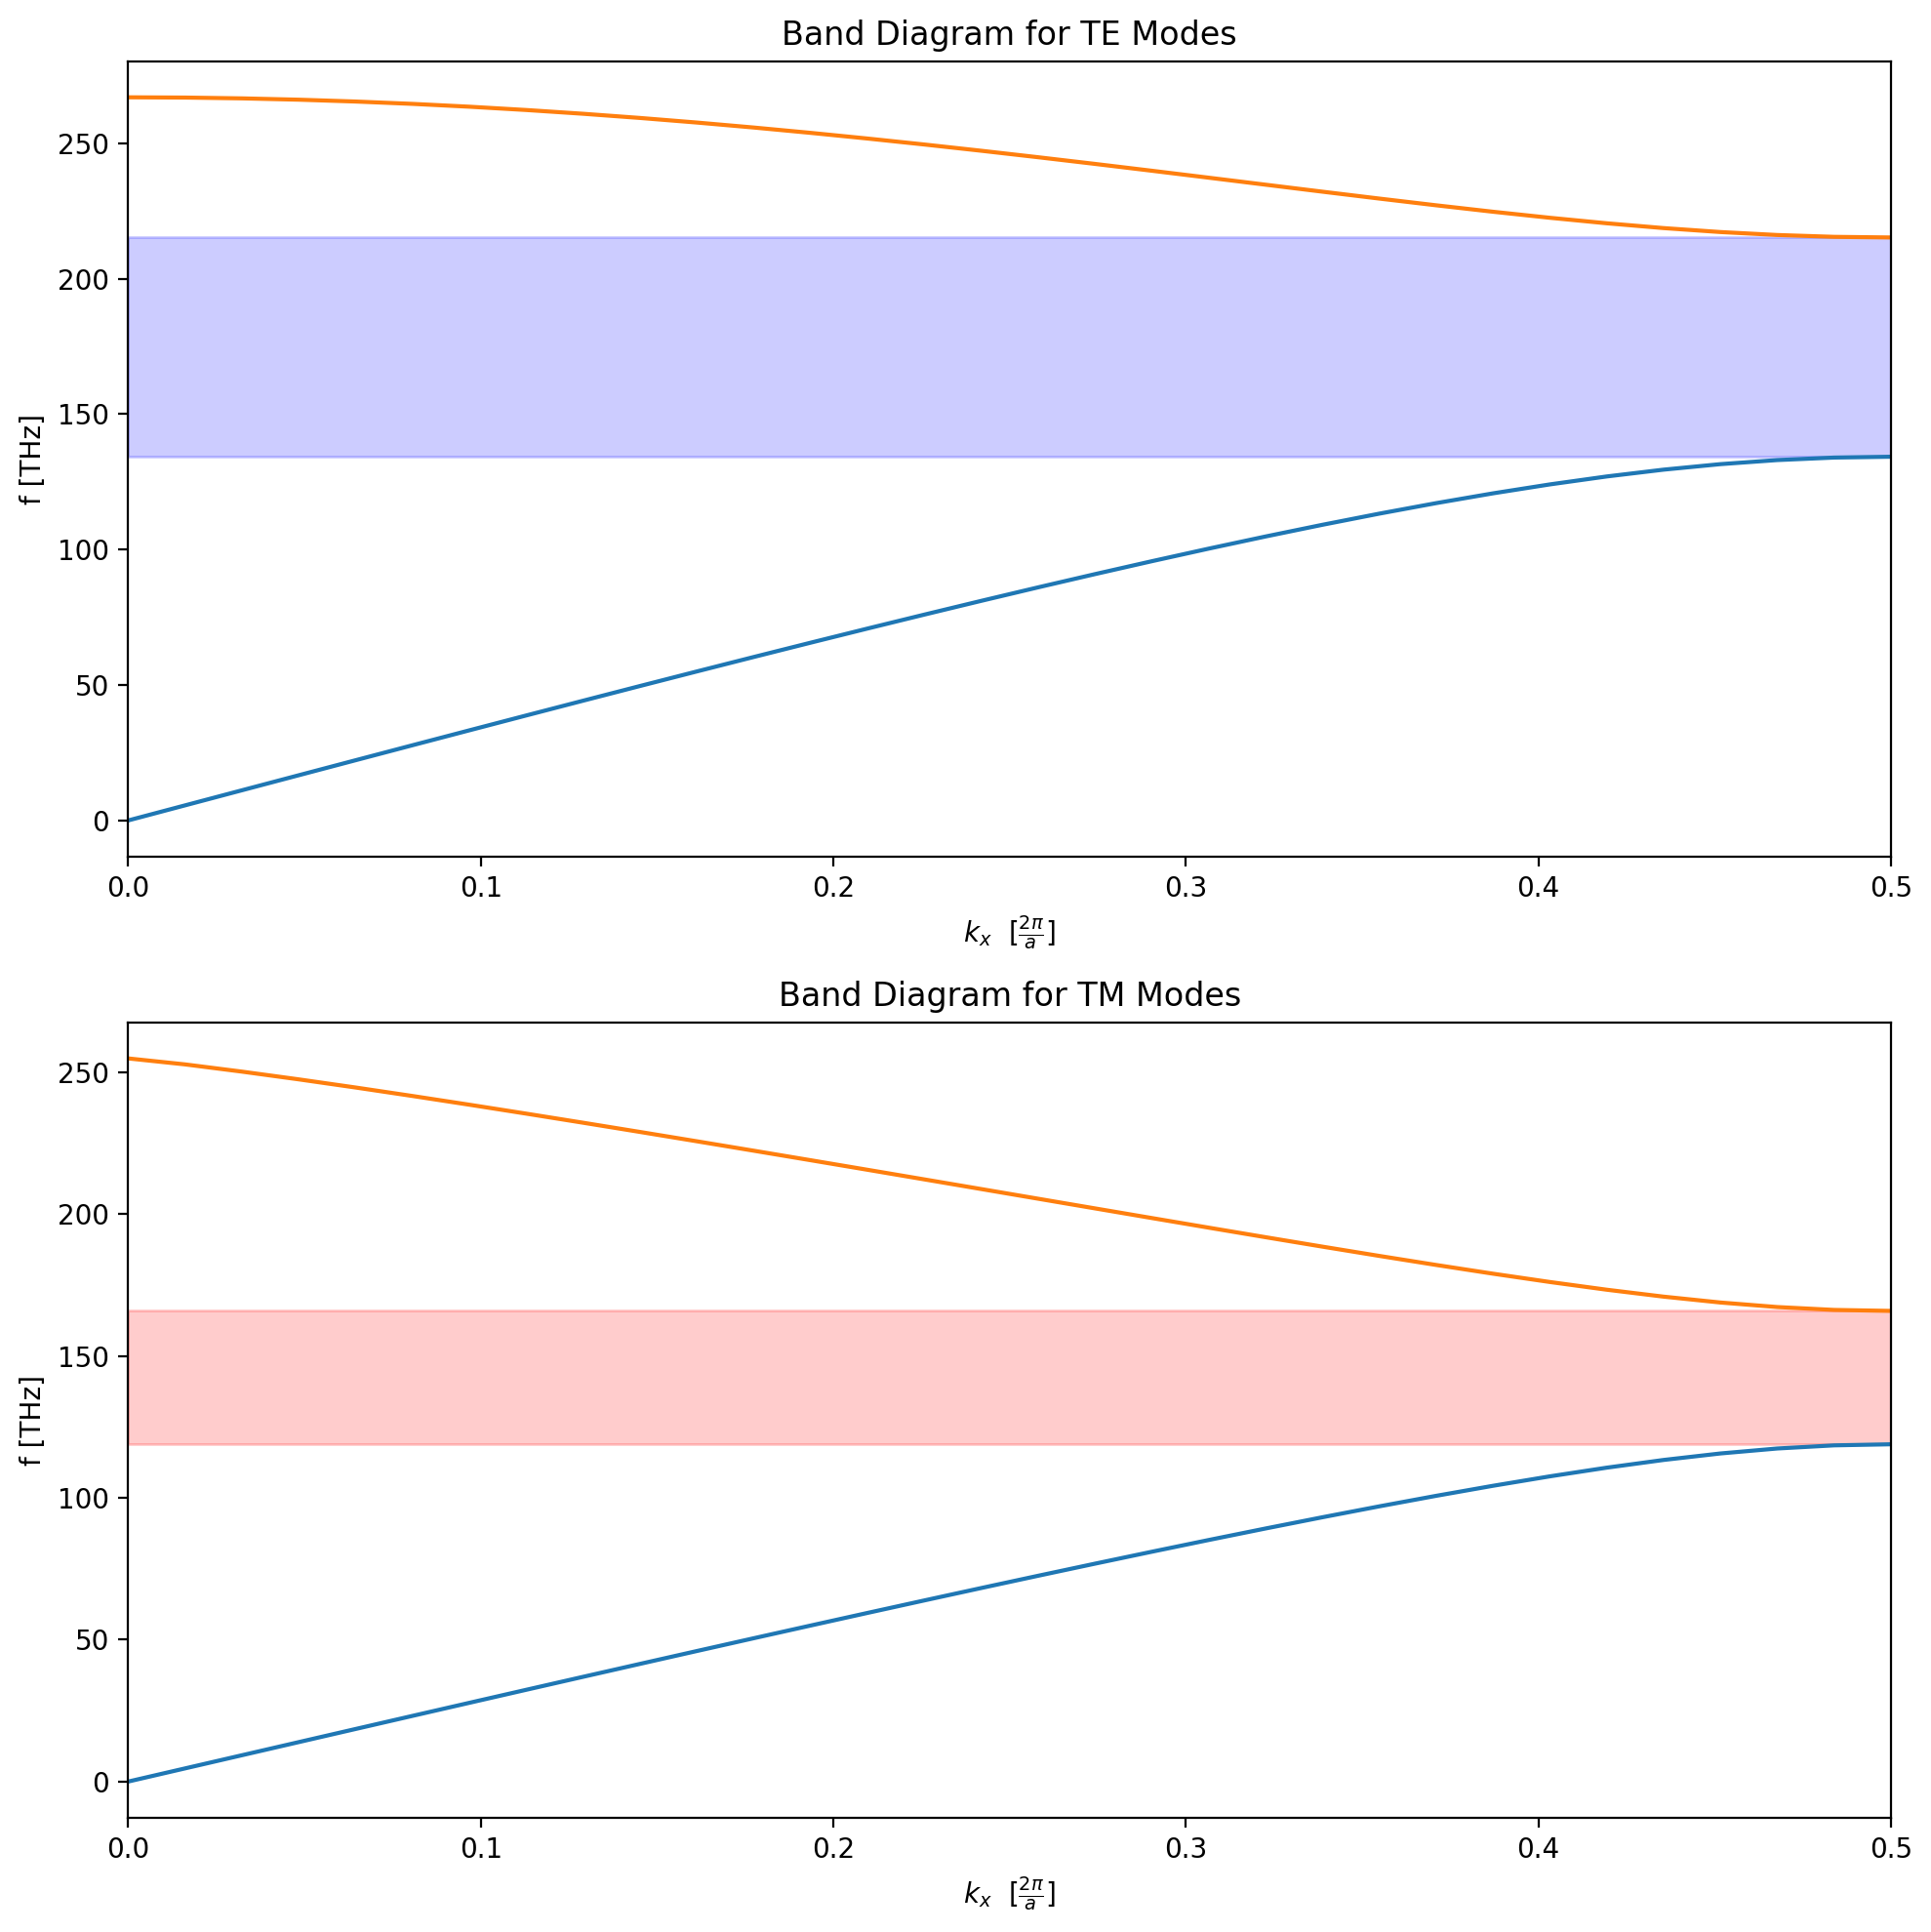

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.20937,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.438019, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

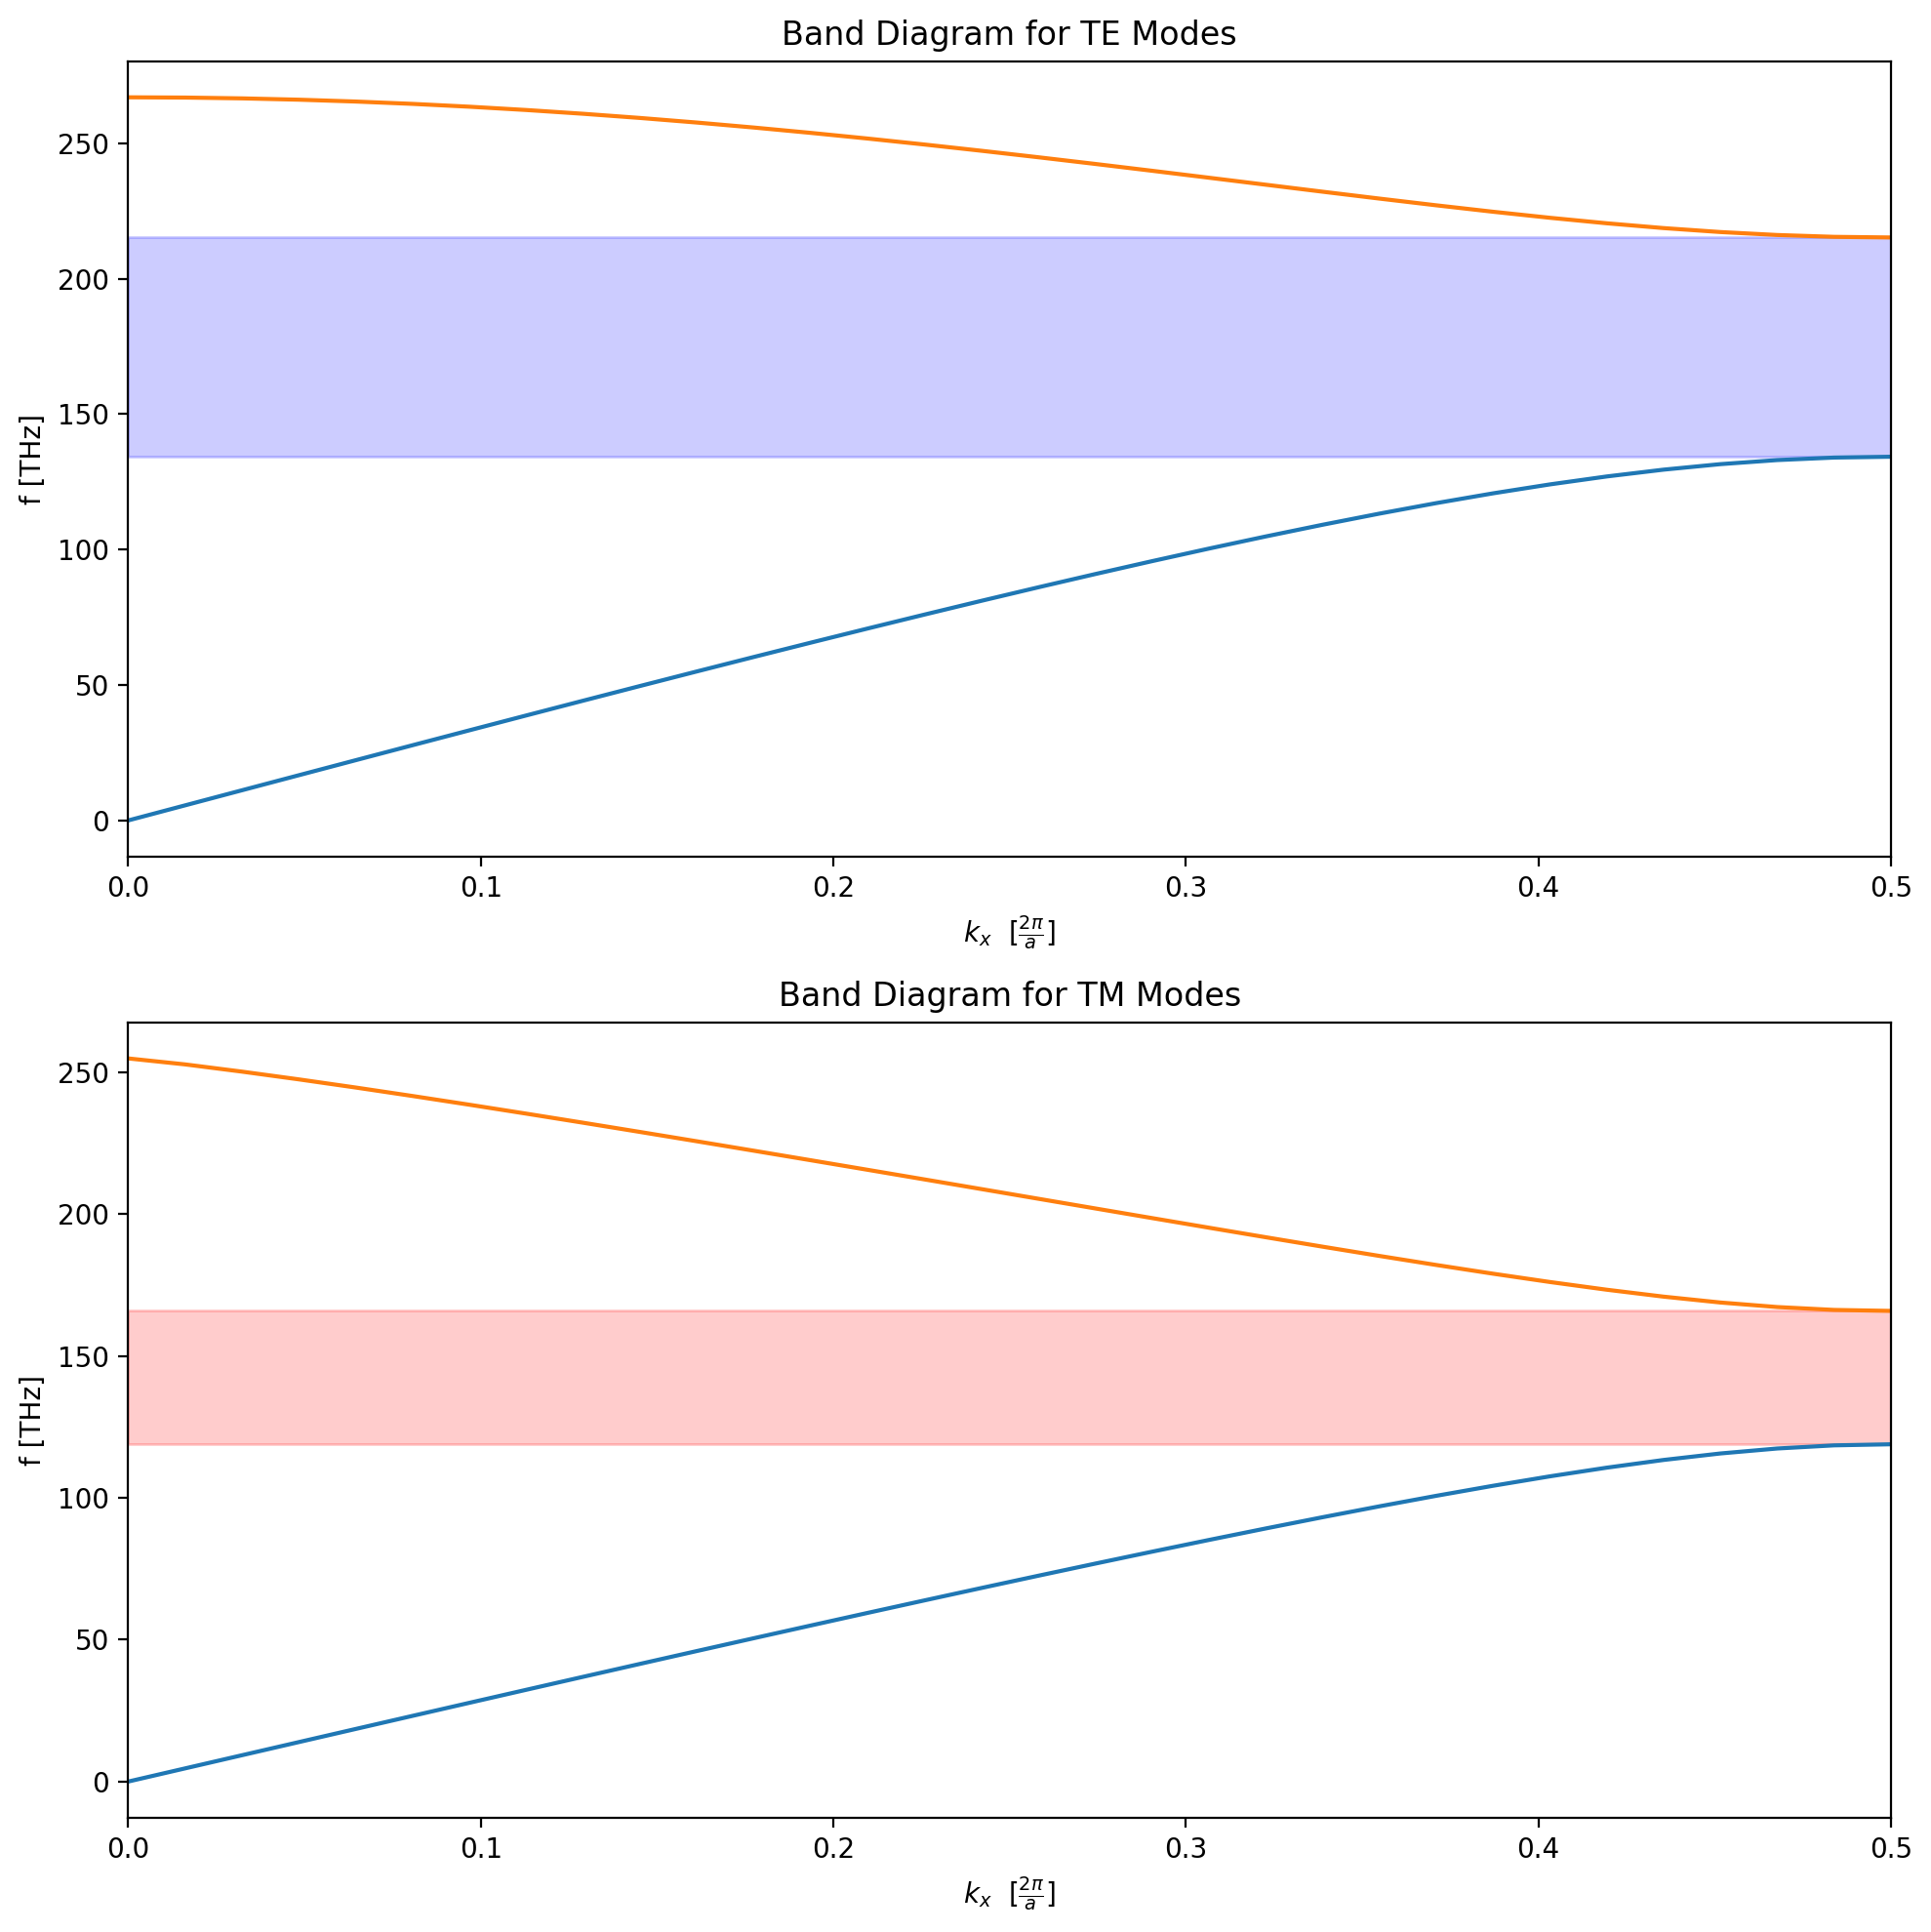

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.24278,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.454725, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

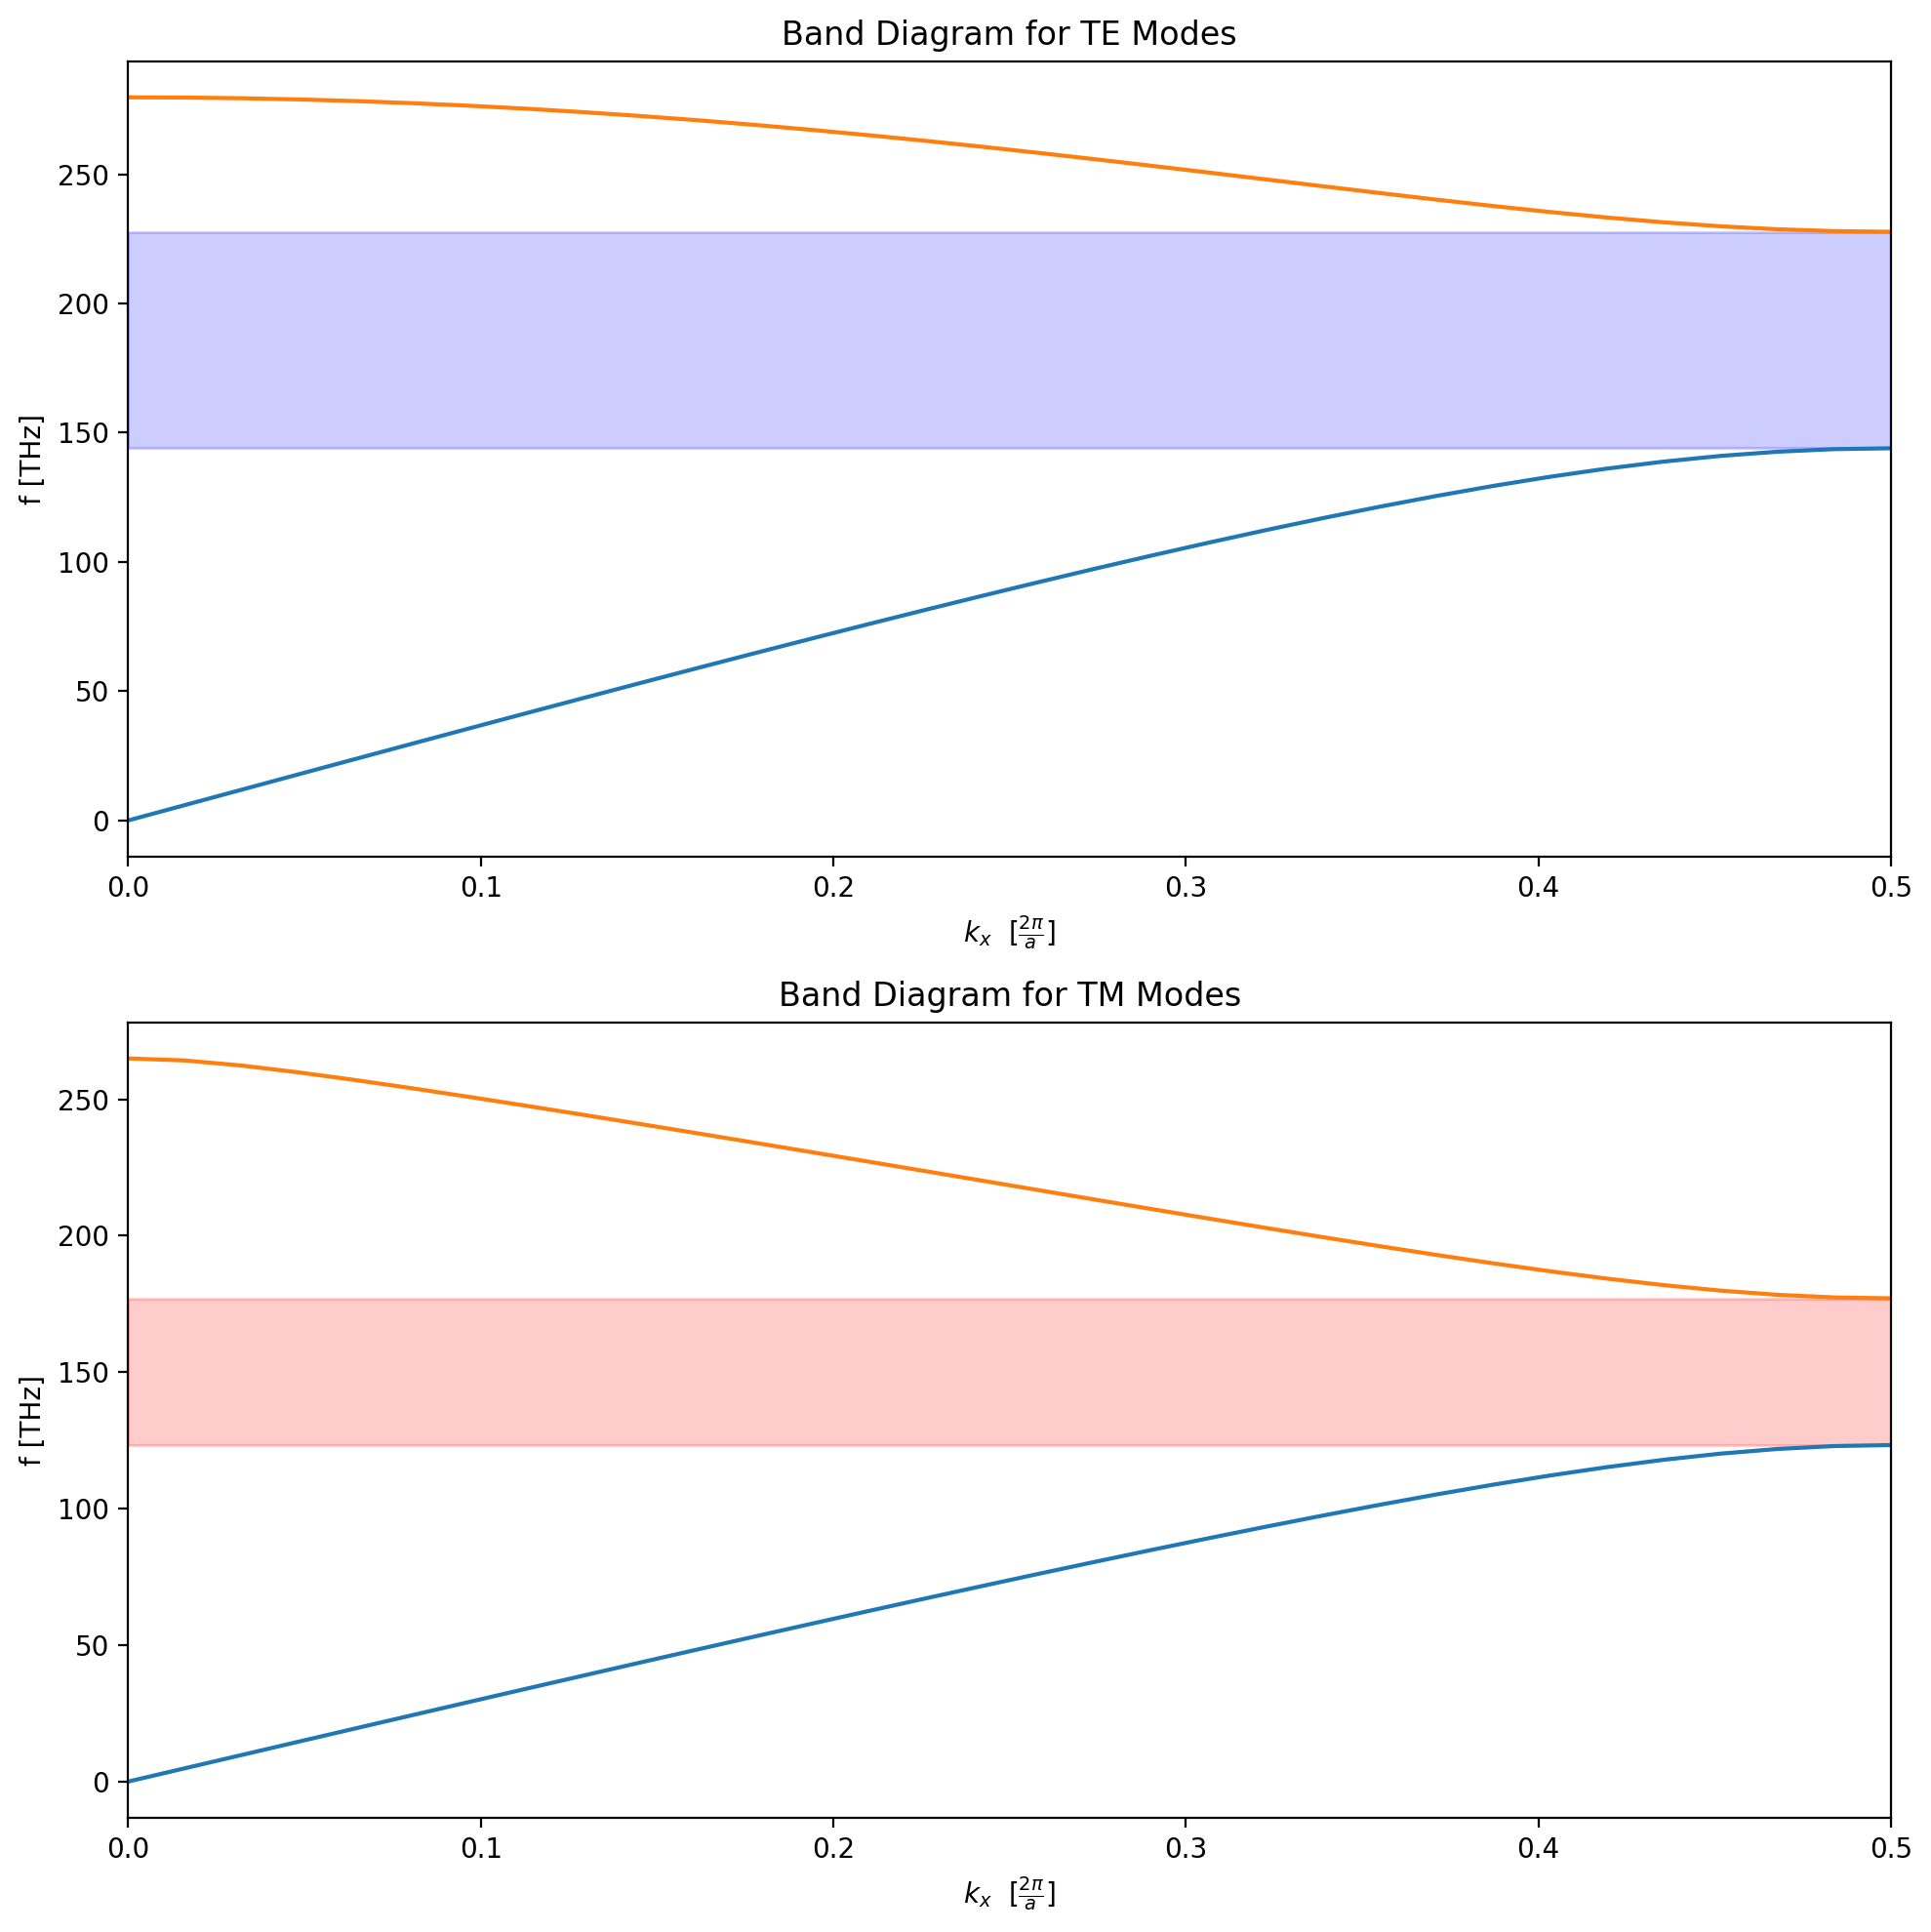

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.24278,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.454725, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

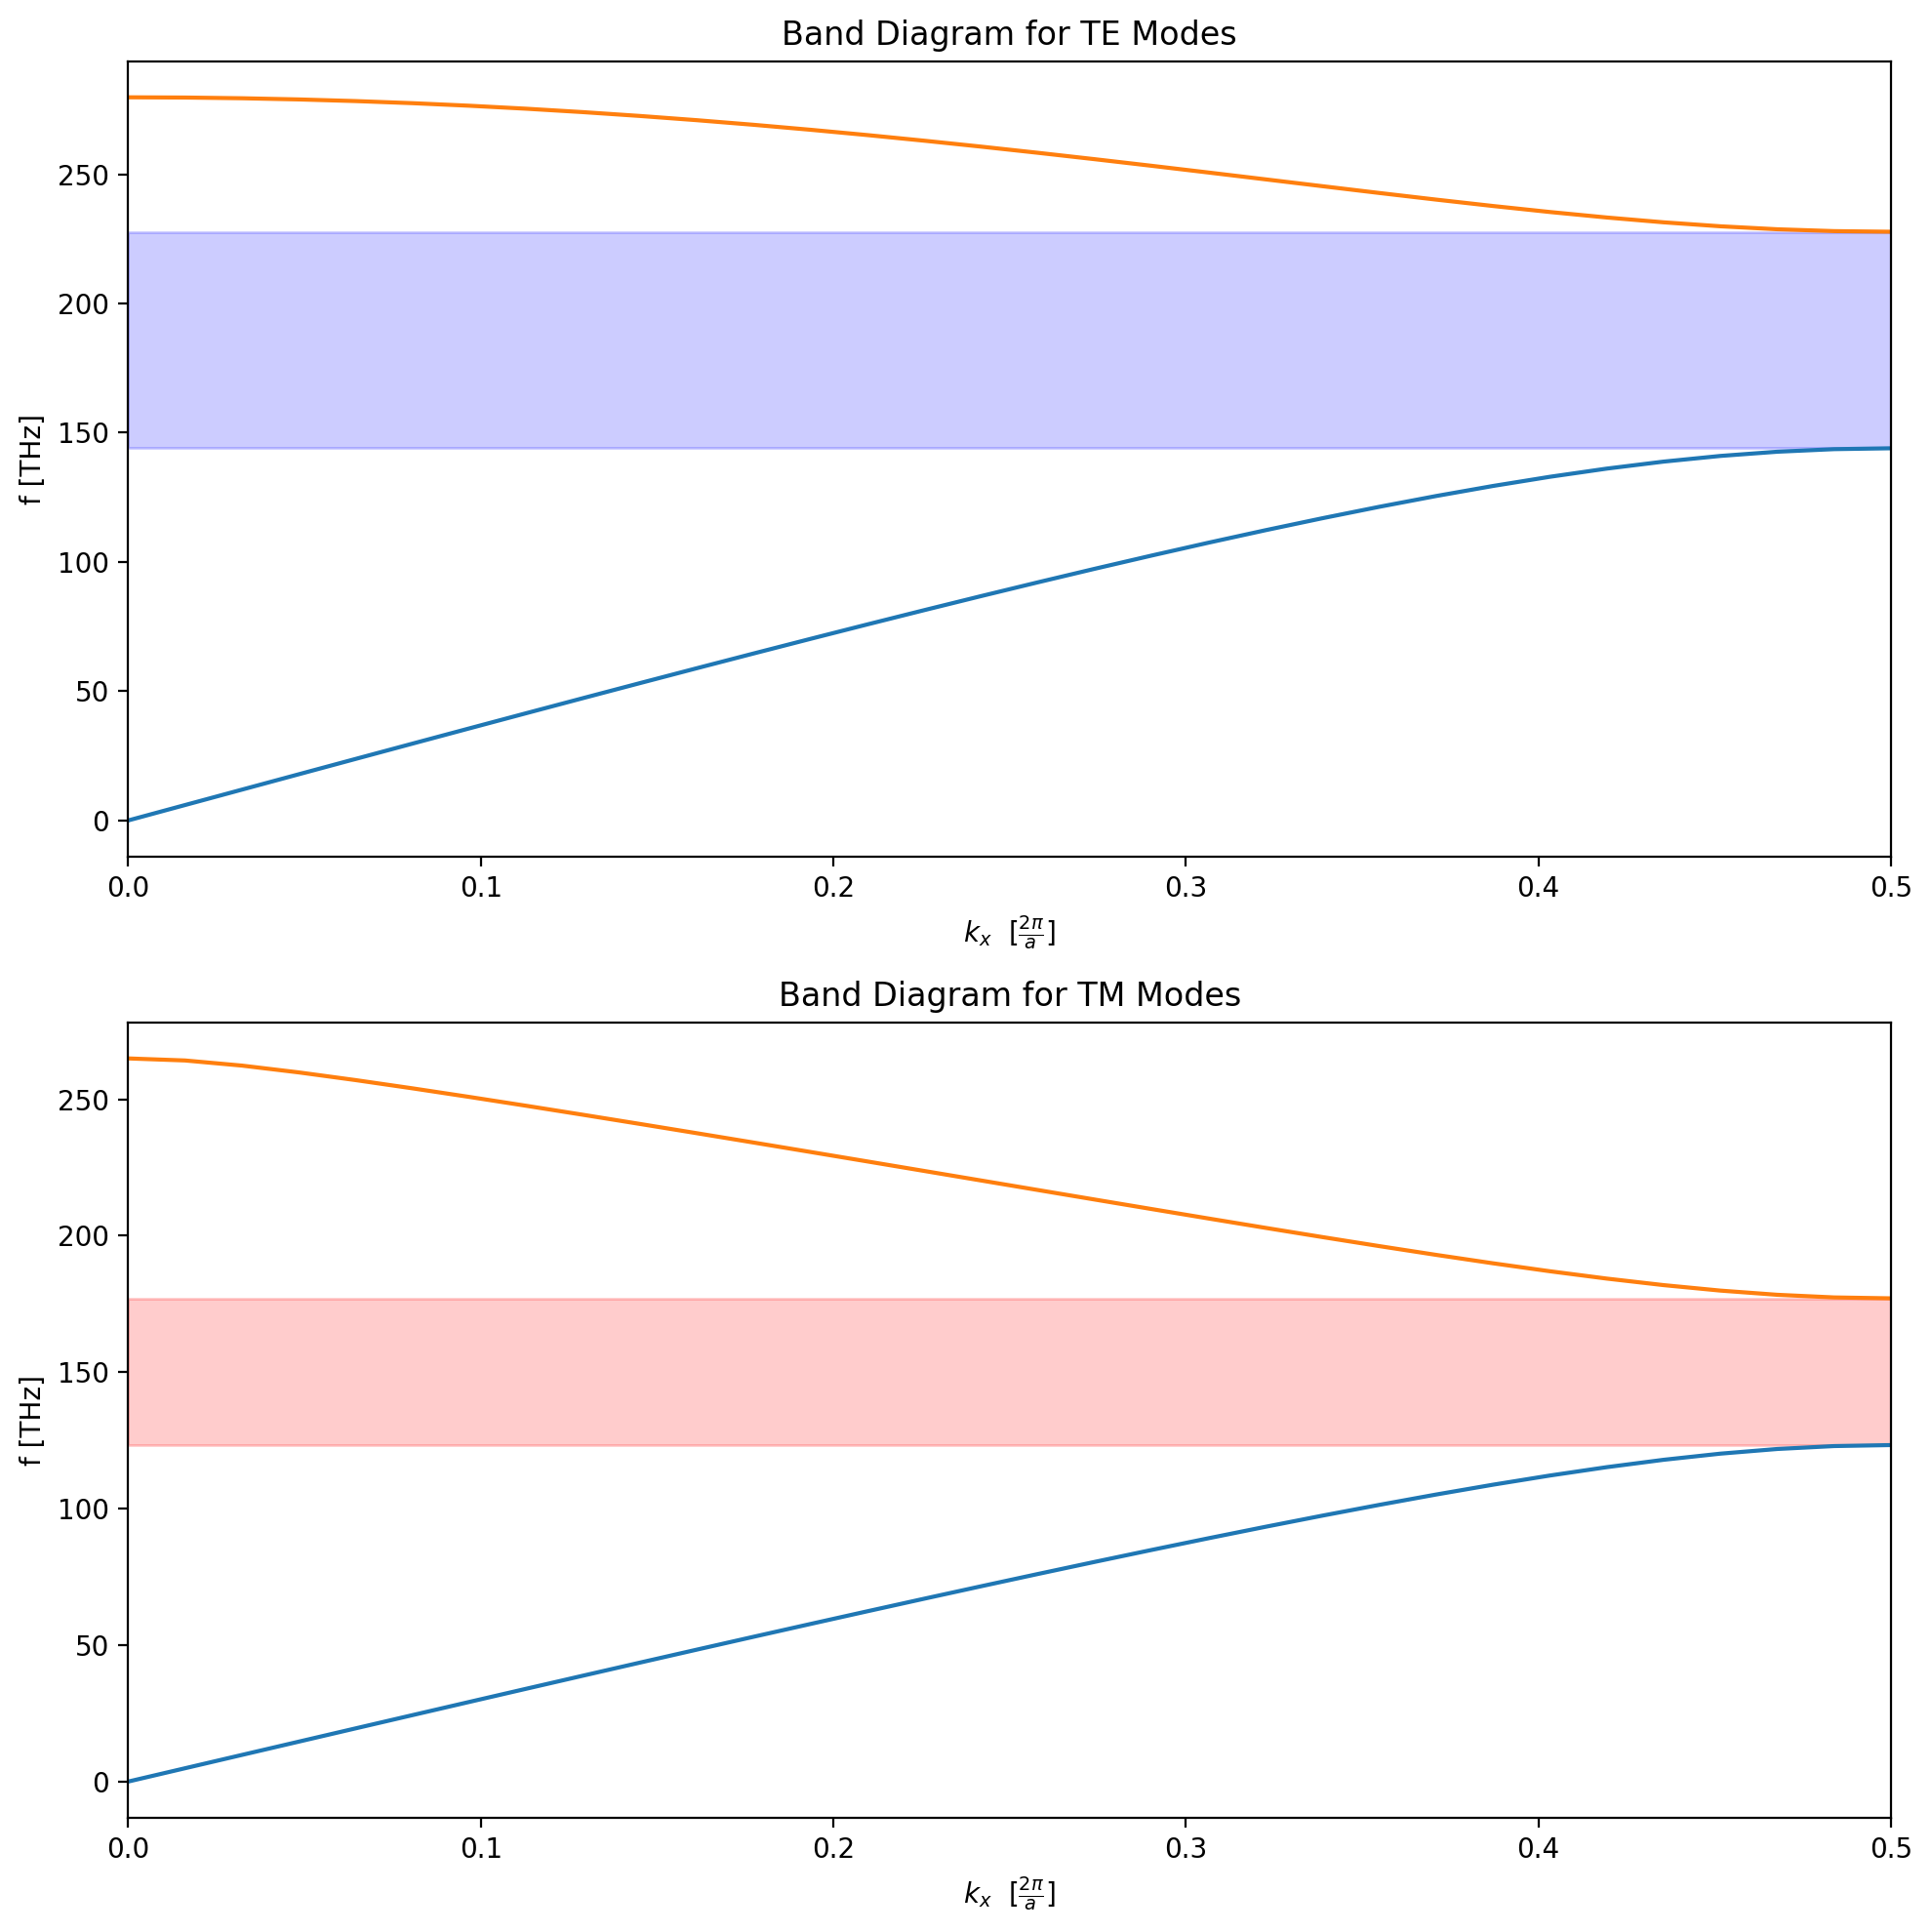

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.24278,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.454725, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

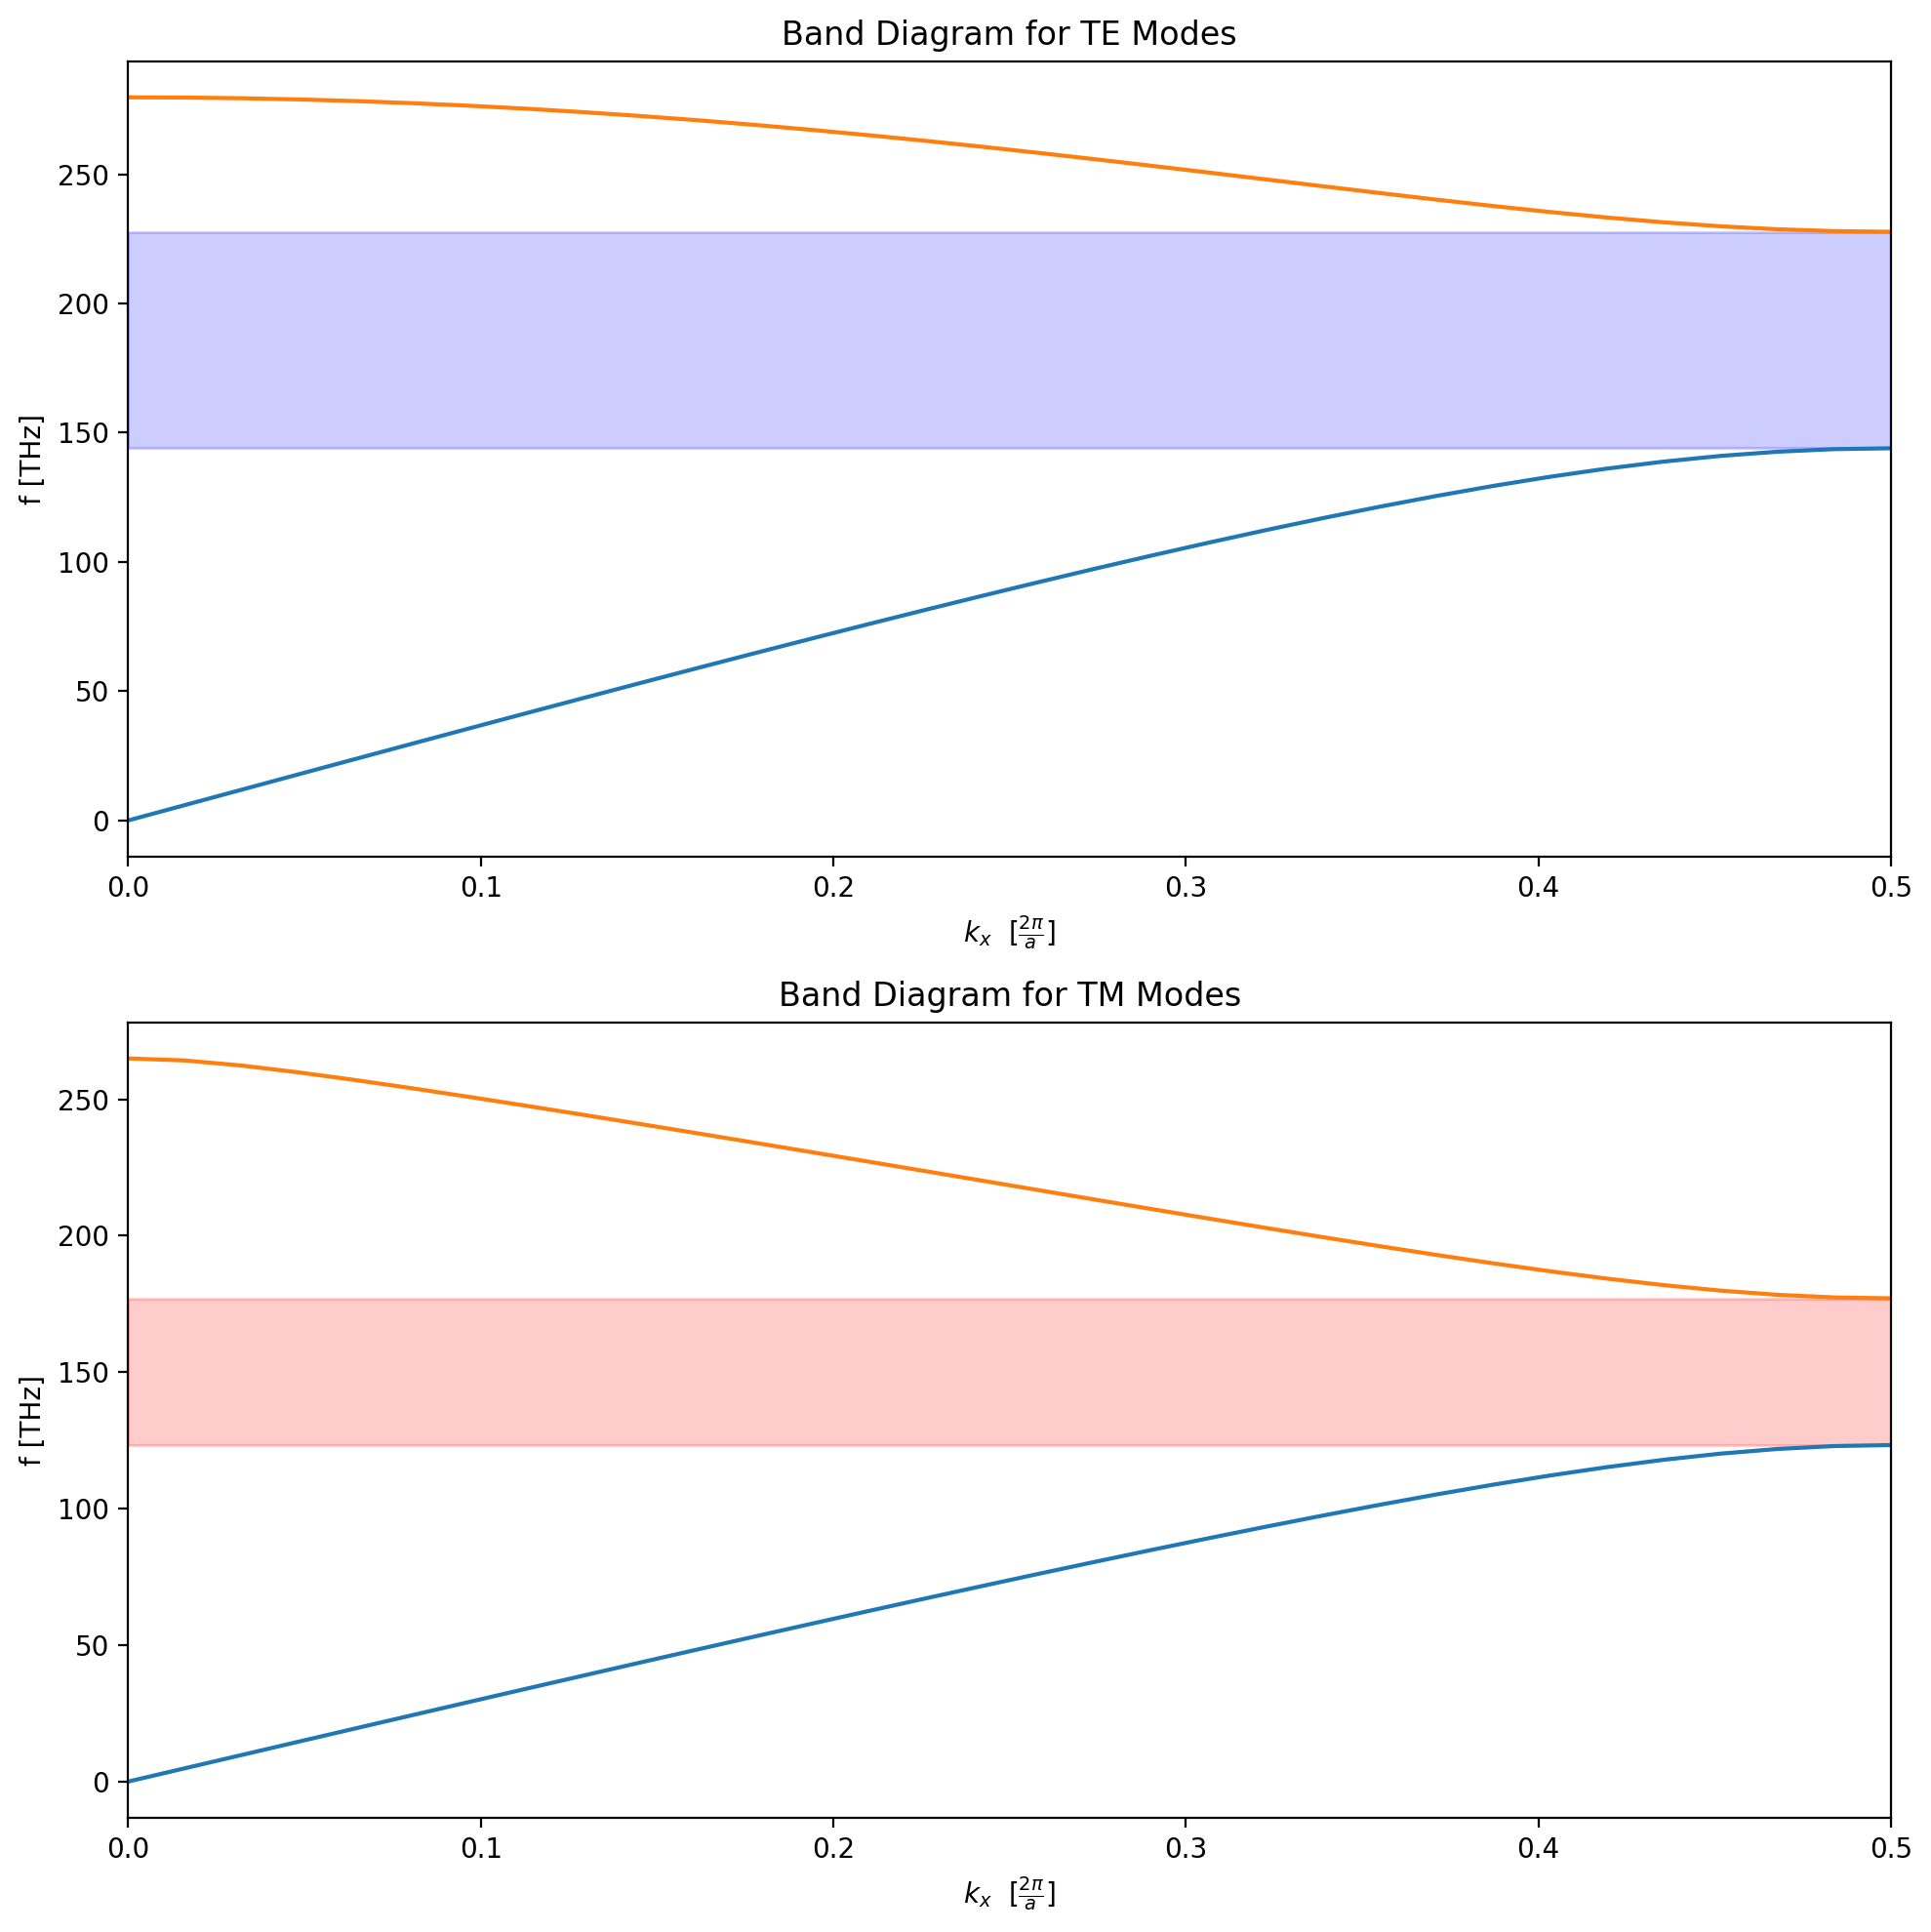

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.39729,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.531493, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 3 and 32 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

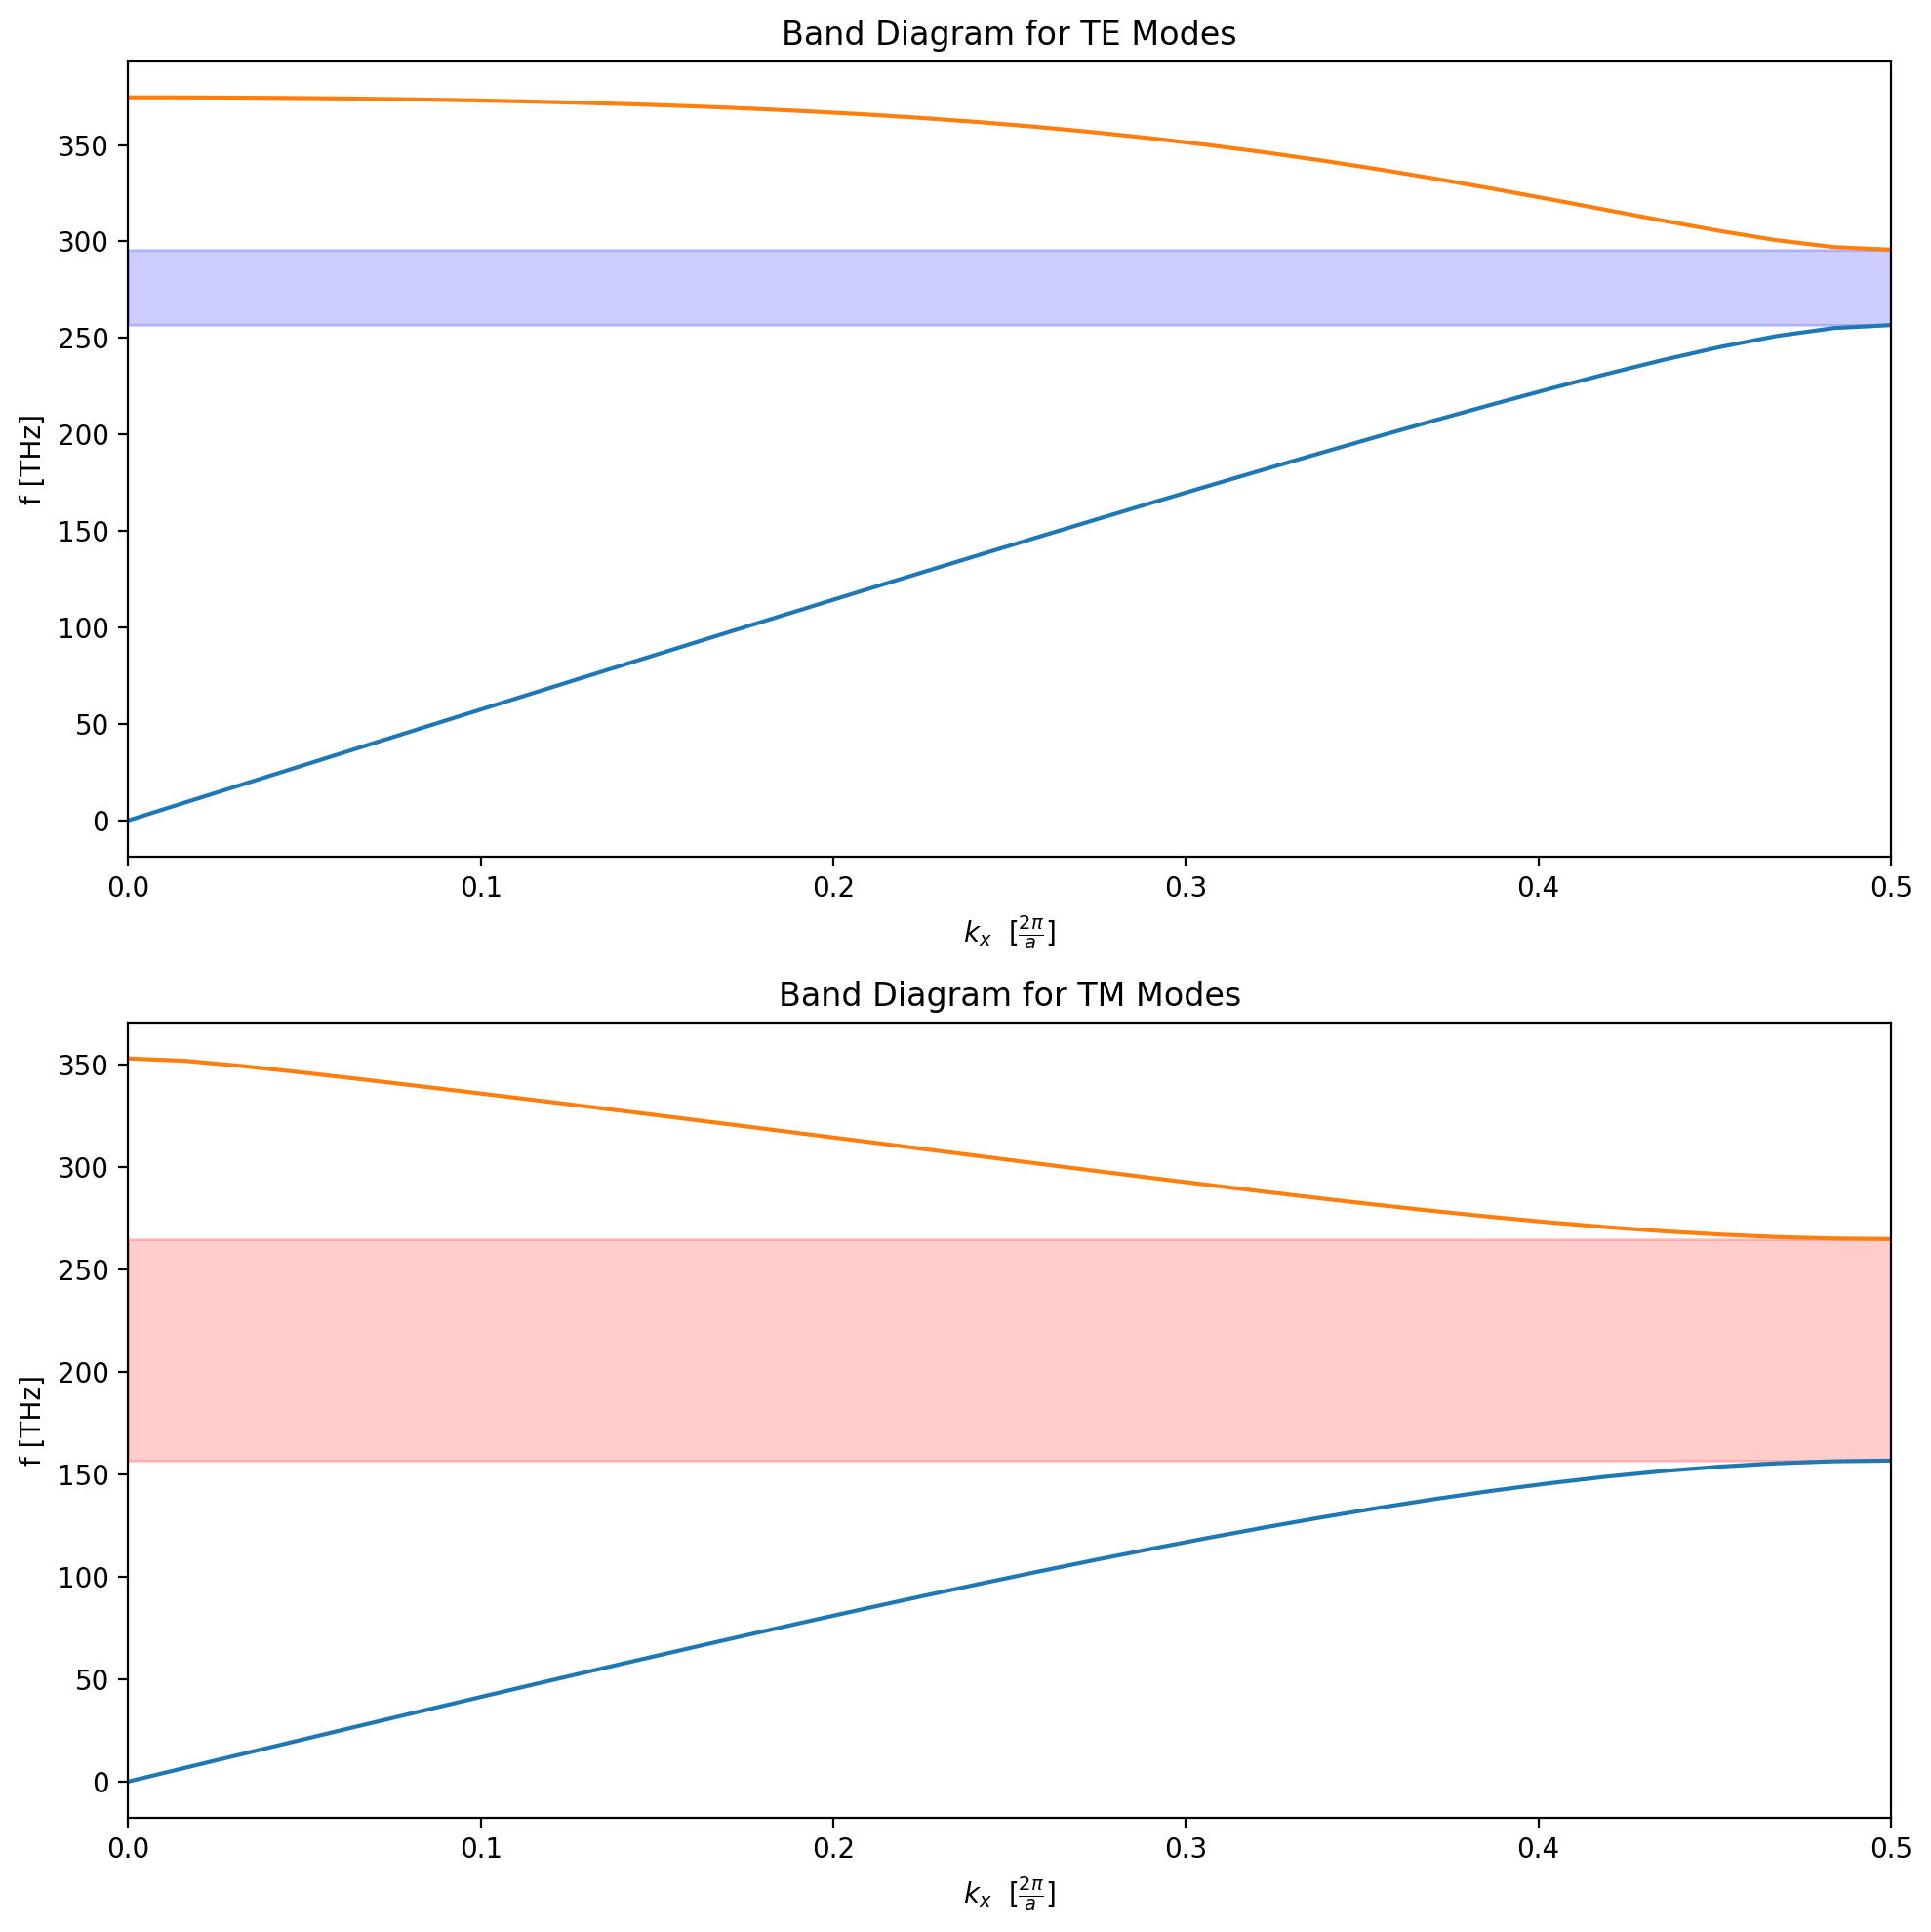

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.26242,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.46448, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516

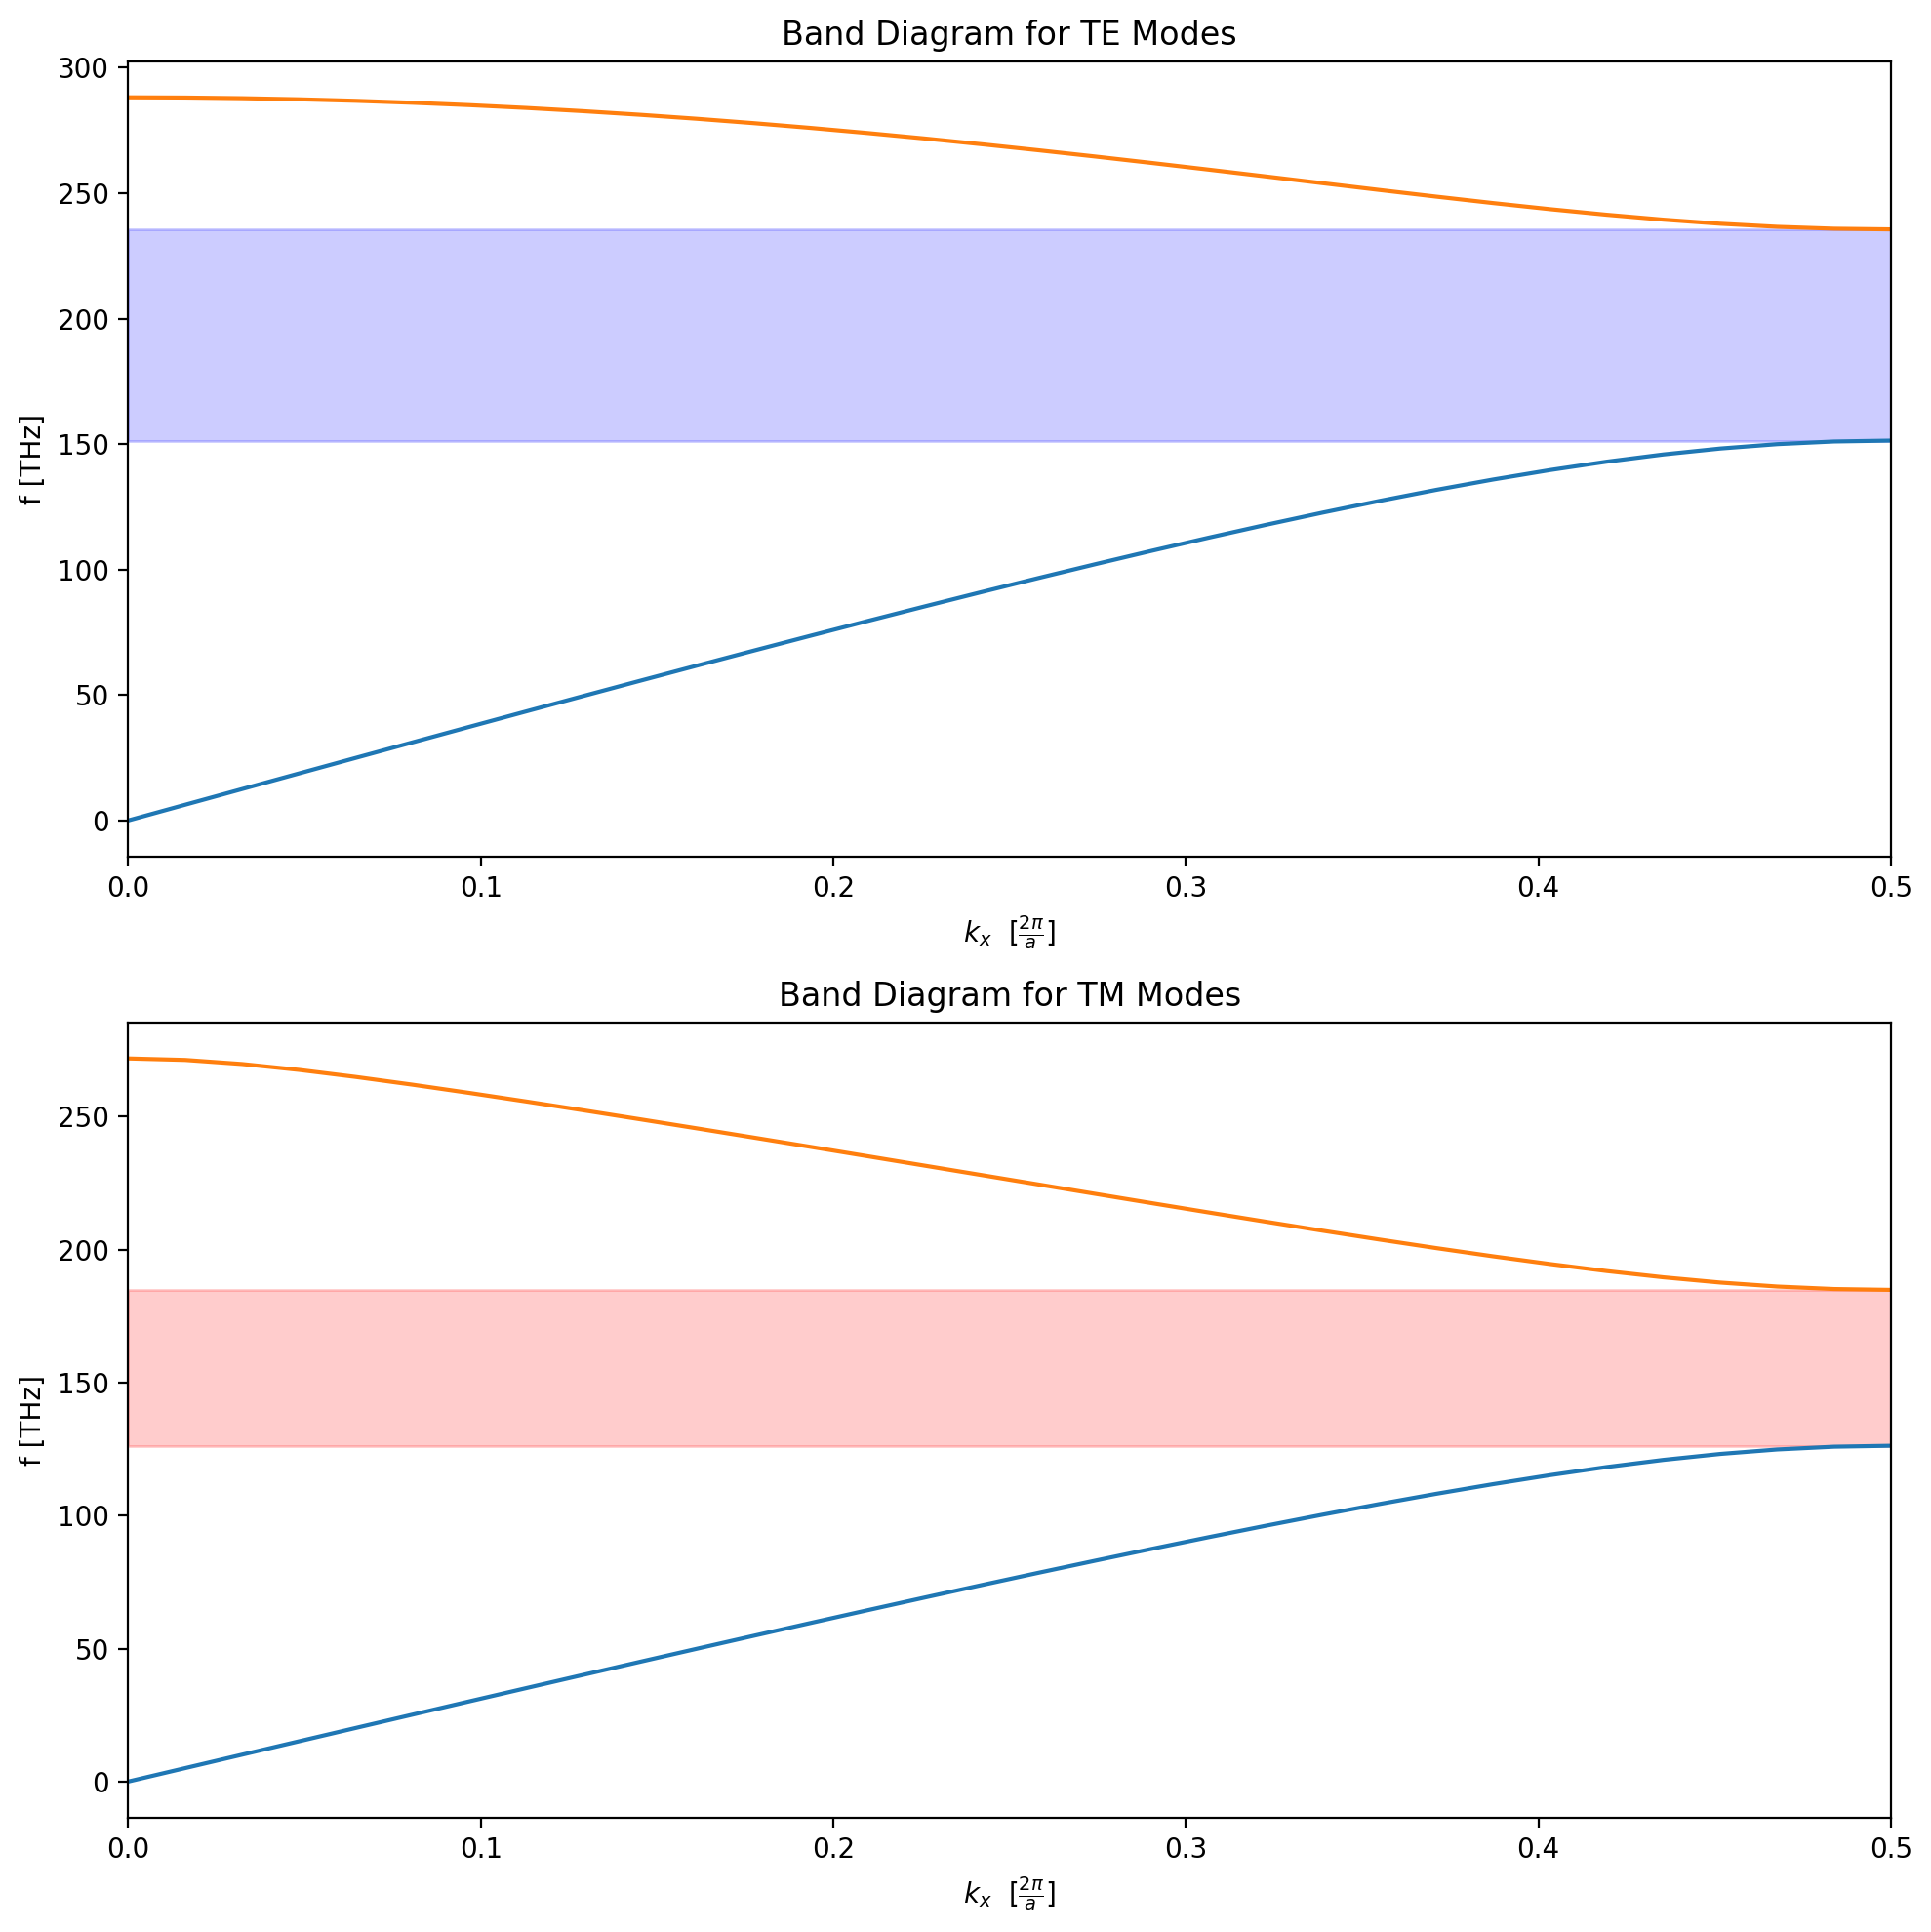

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.26242,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.46448, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516

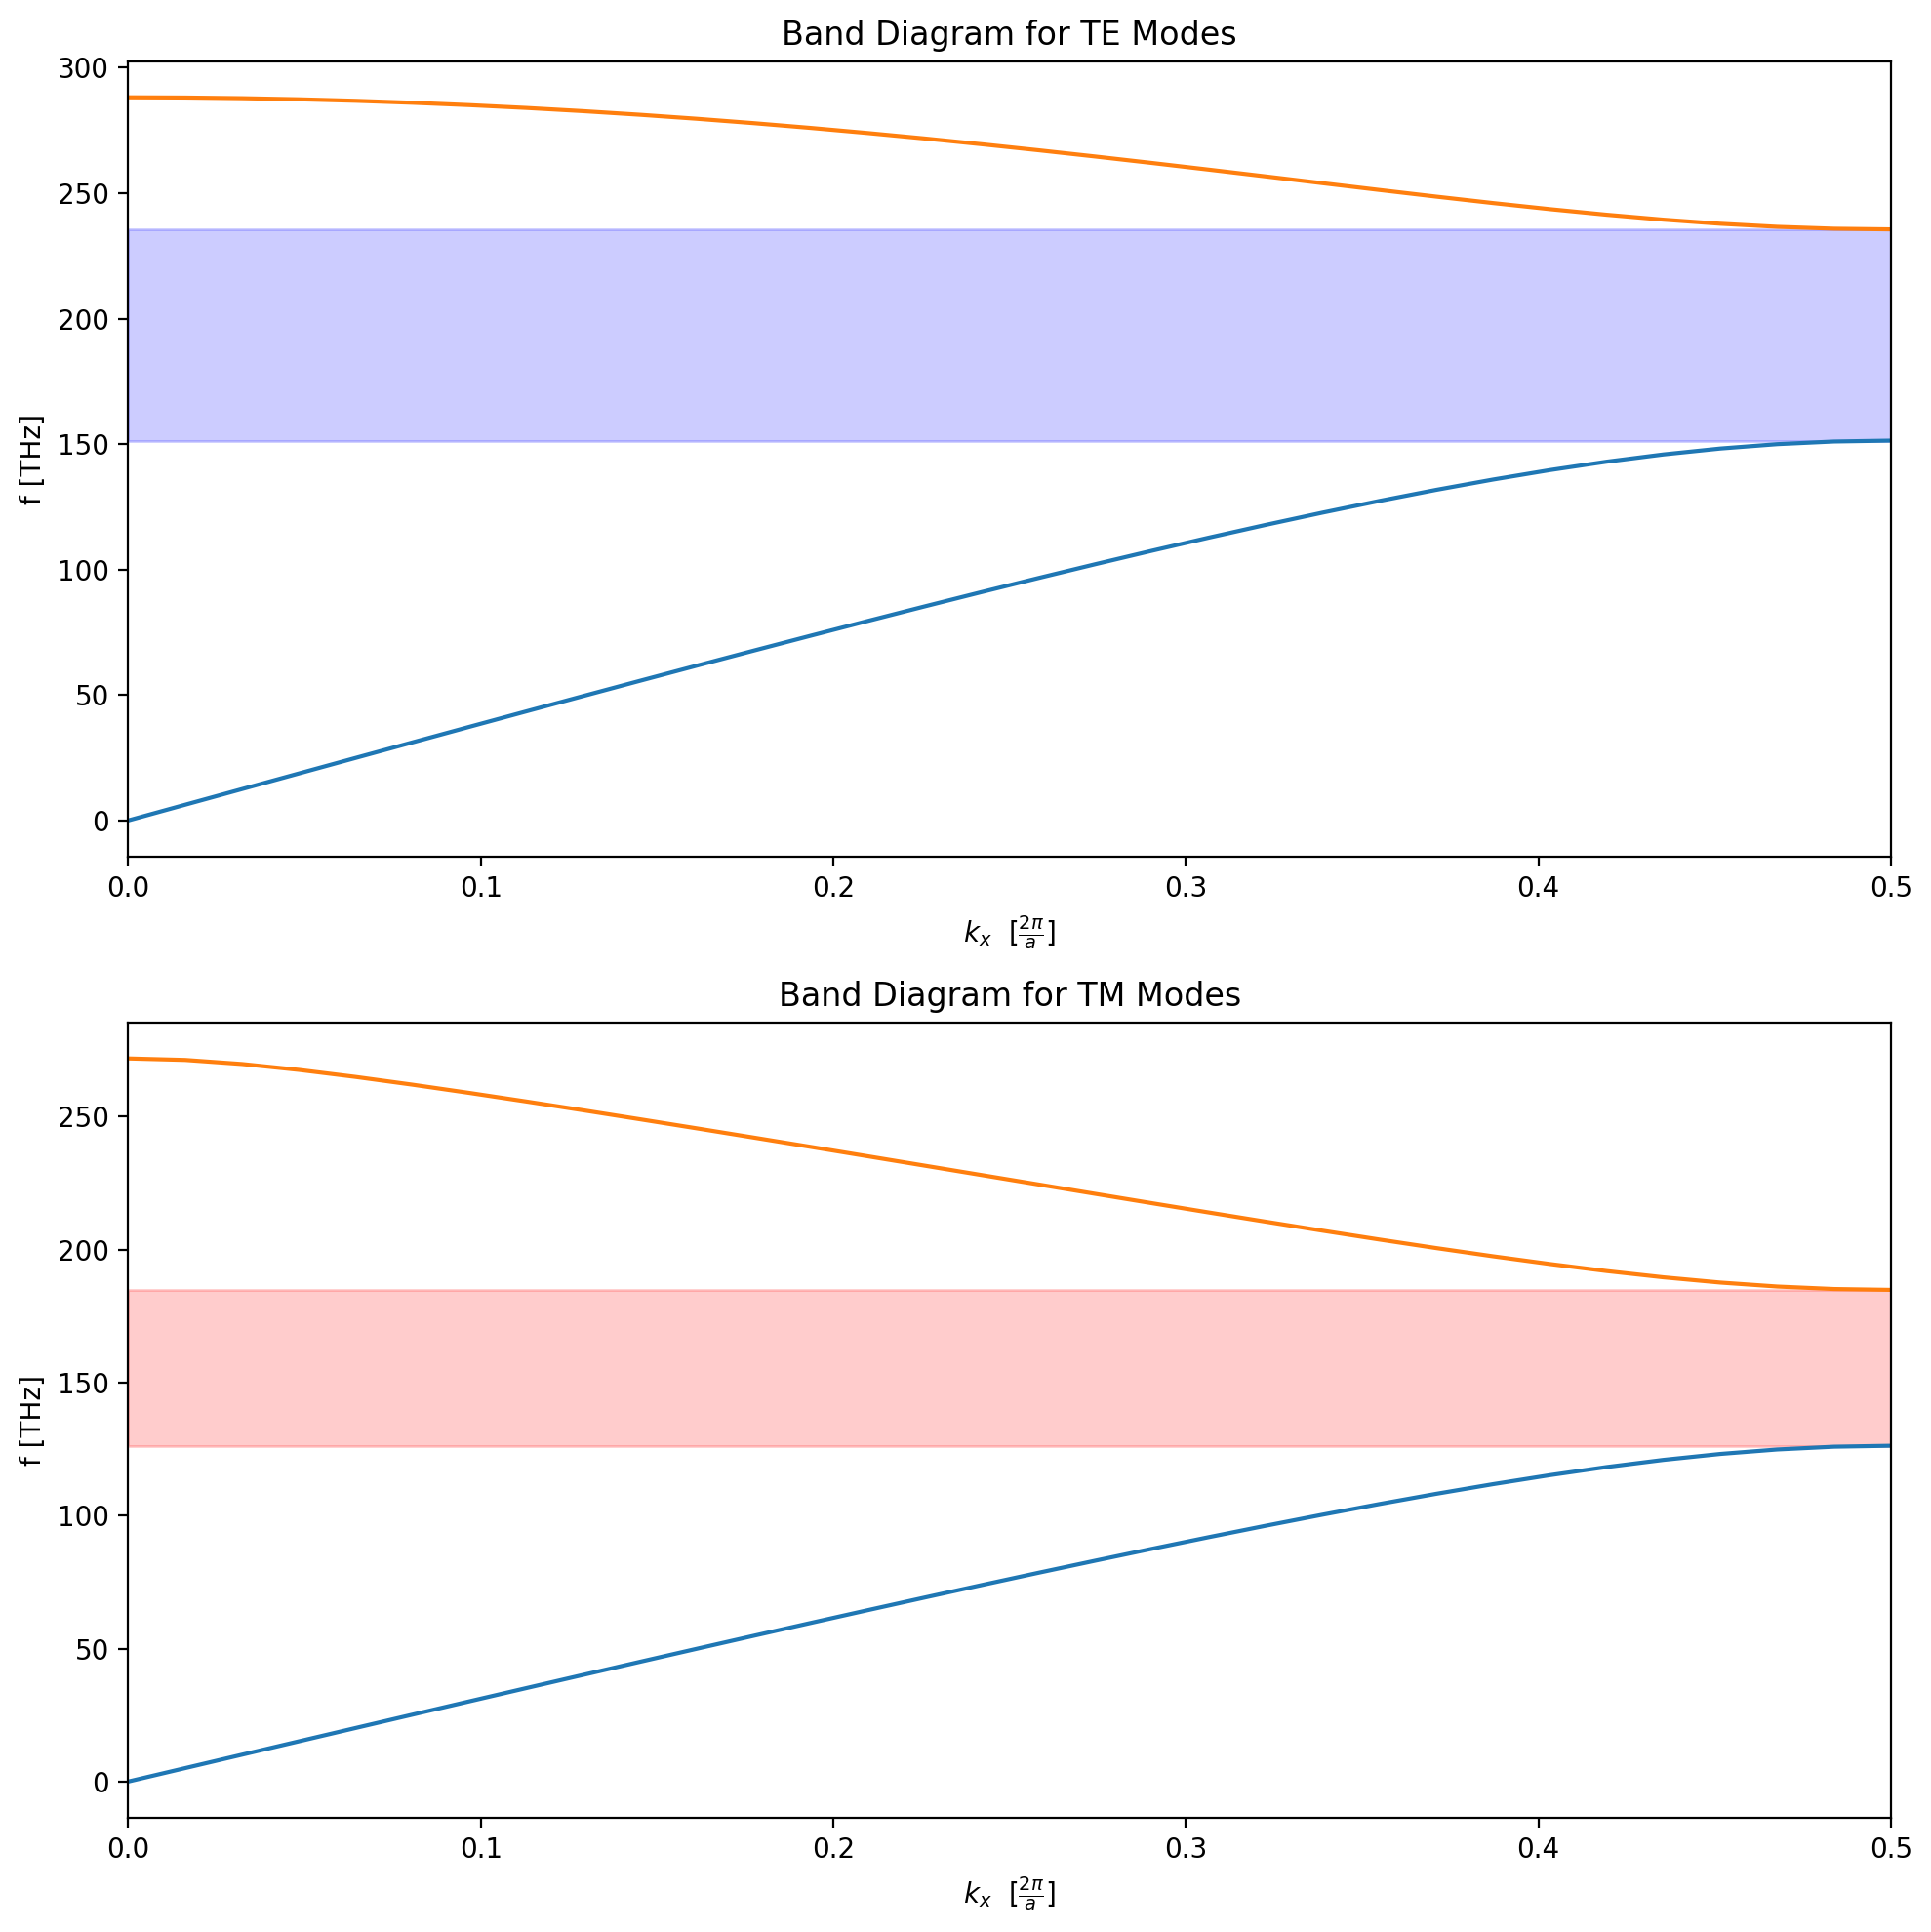

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.26242,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.46448, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516

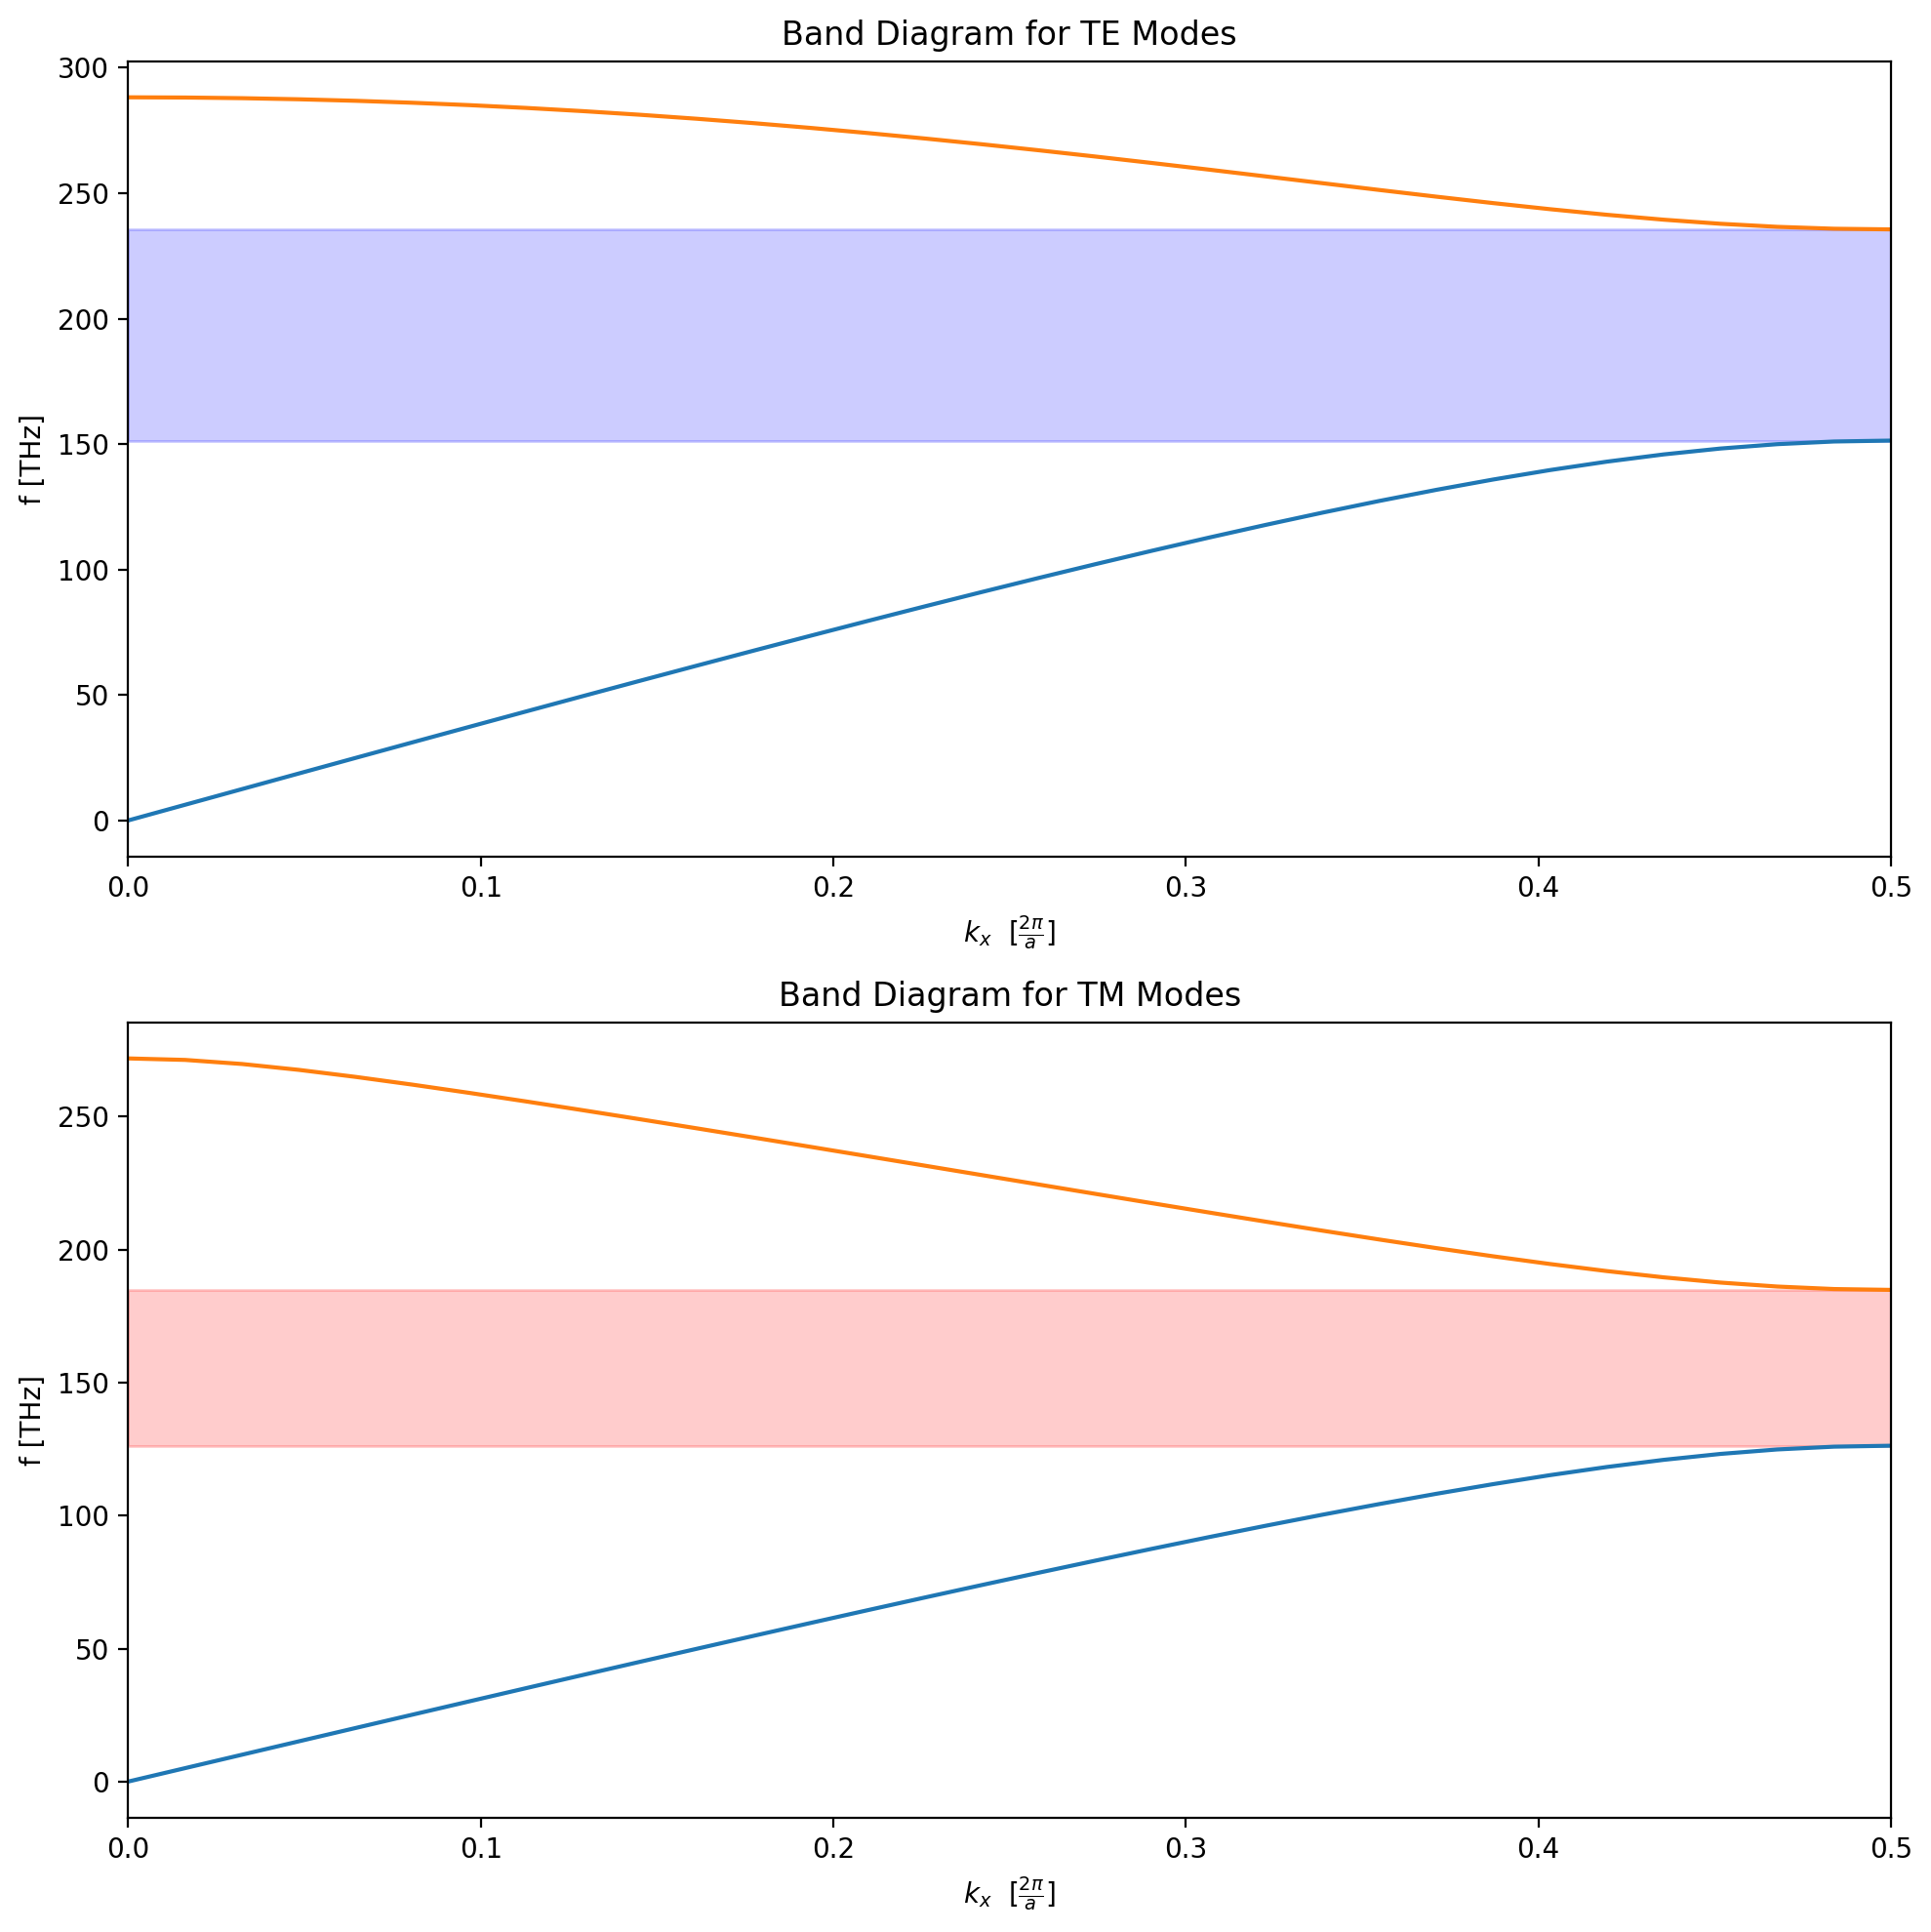

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.26009,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.463309, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

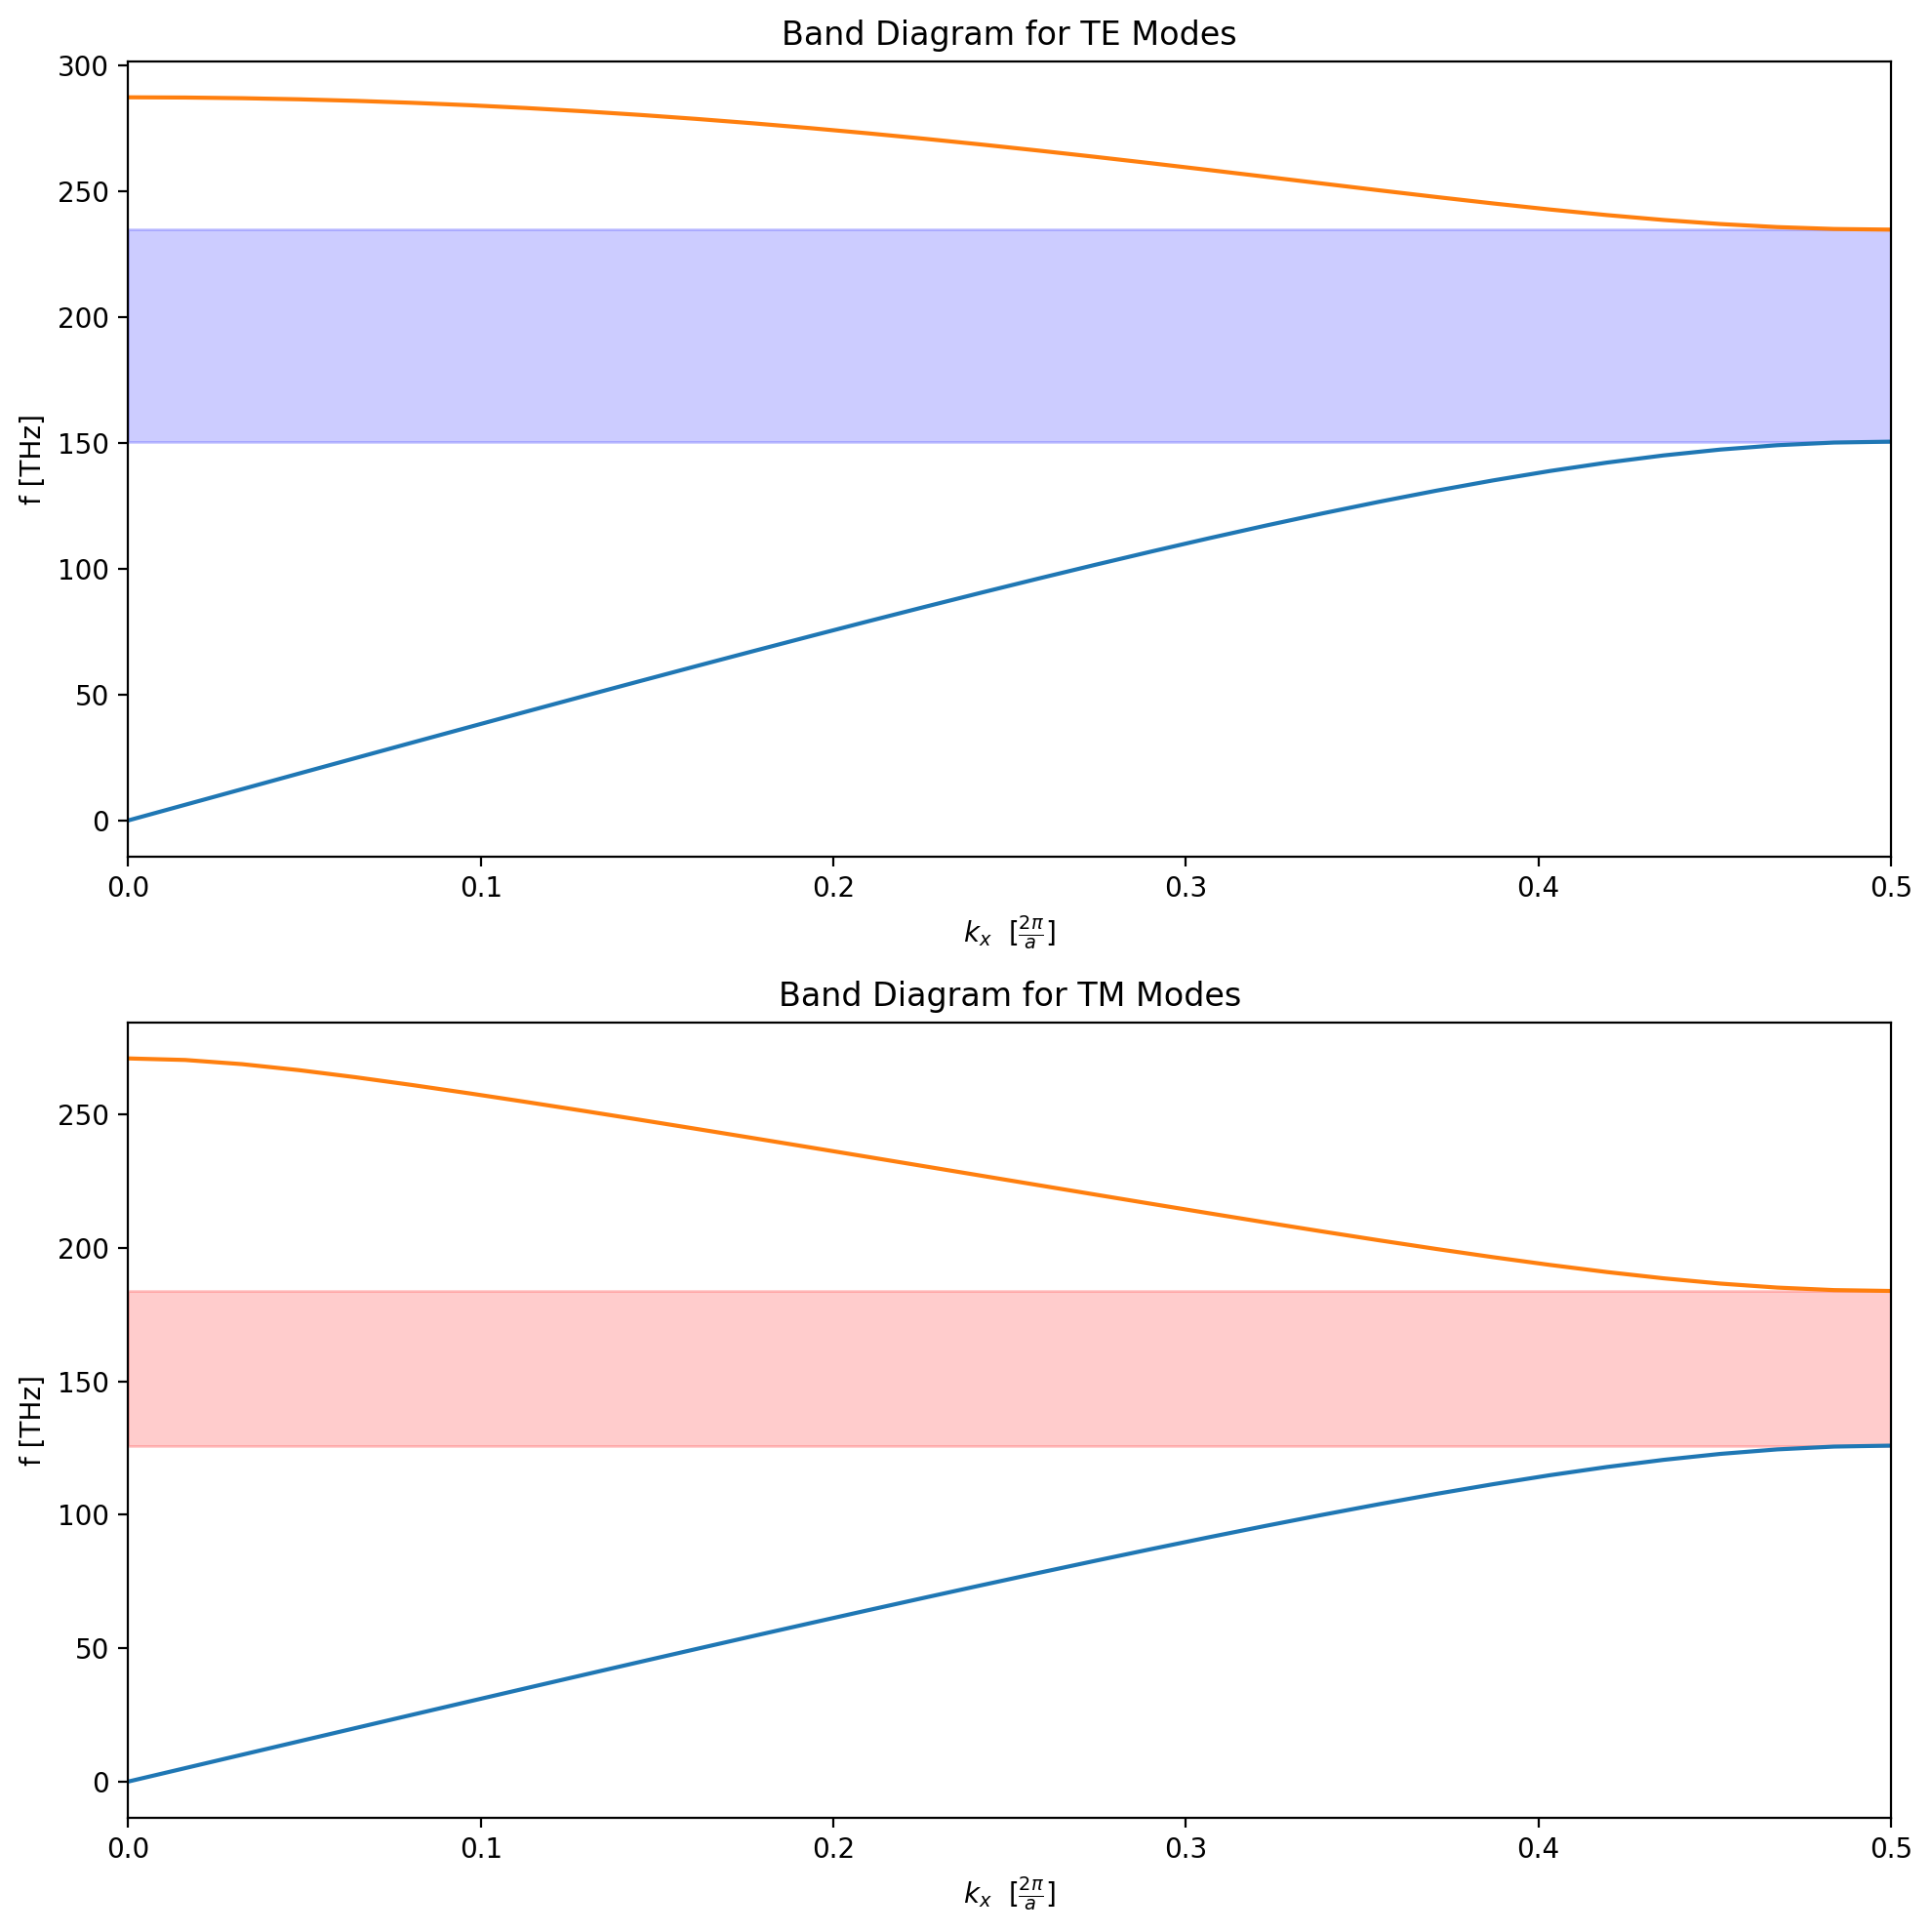

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.26009,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.463309, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

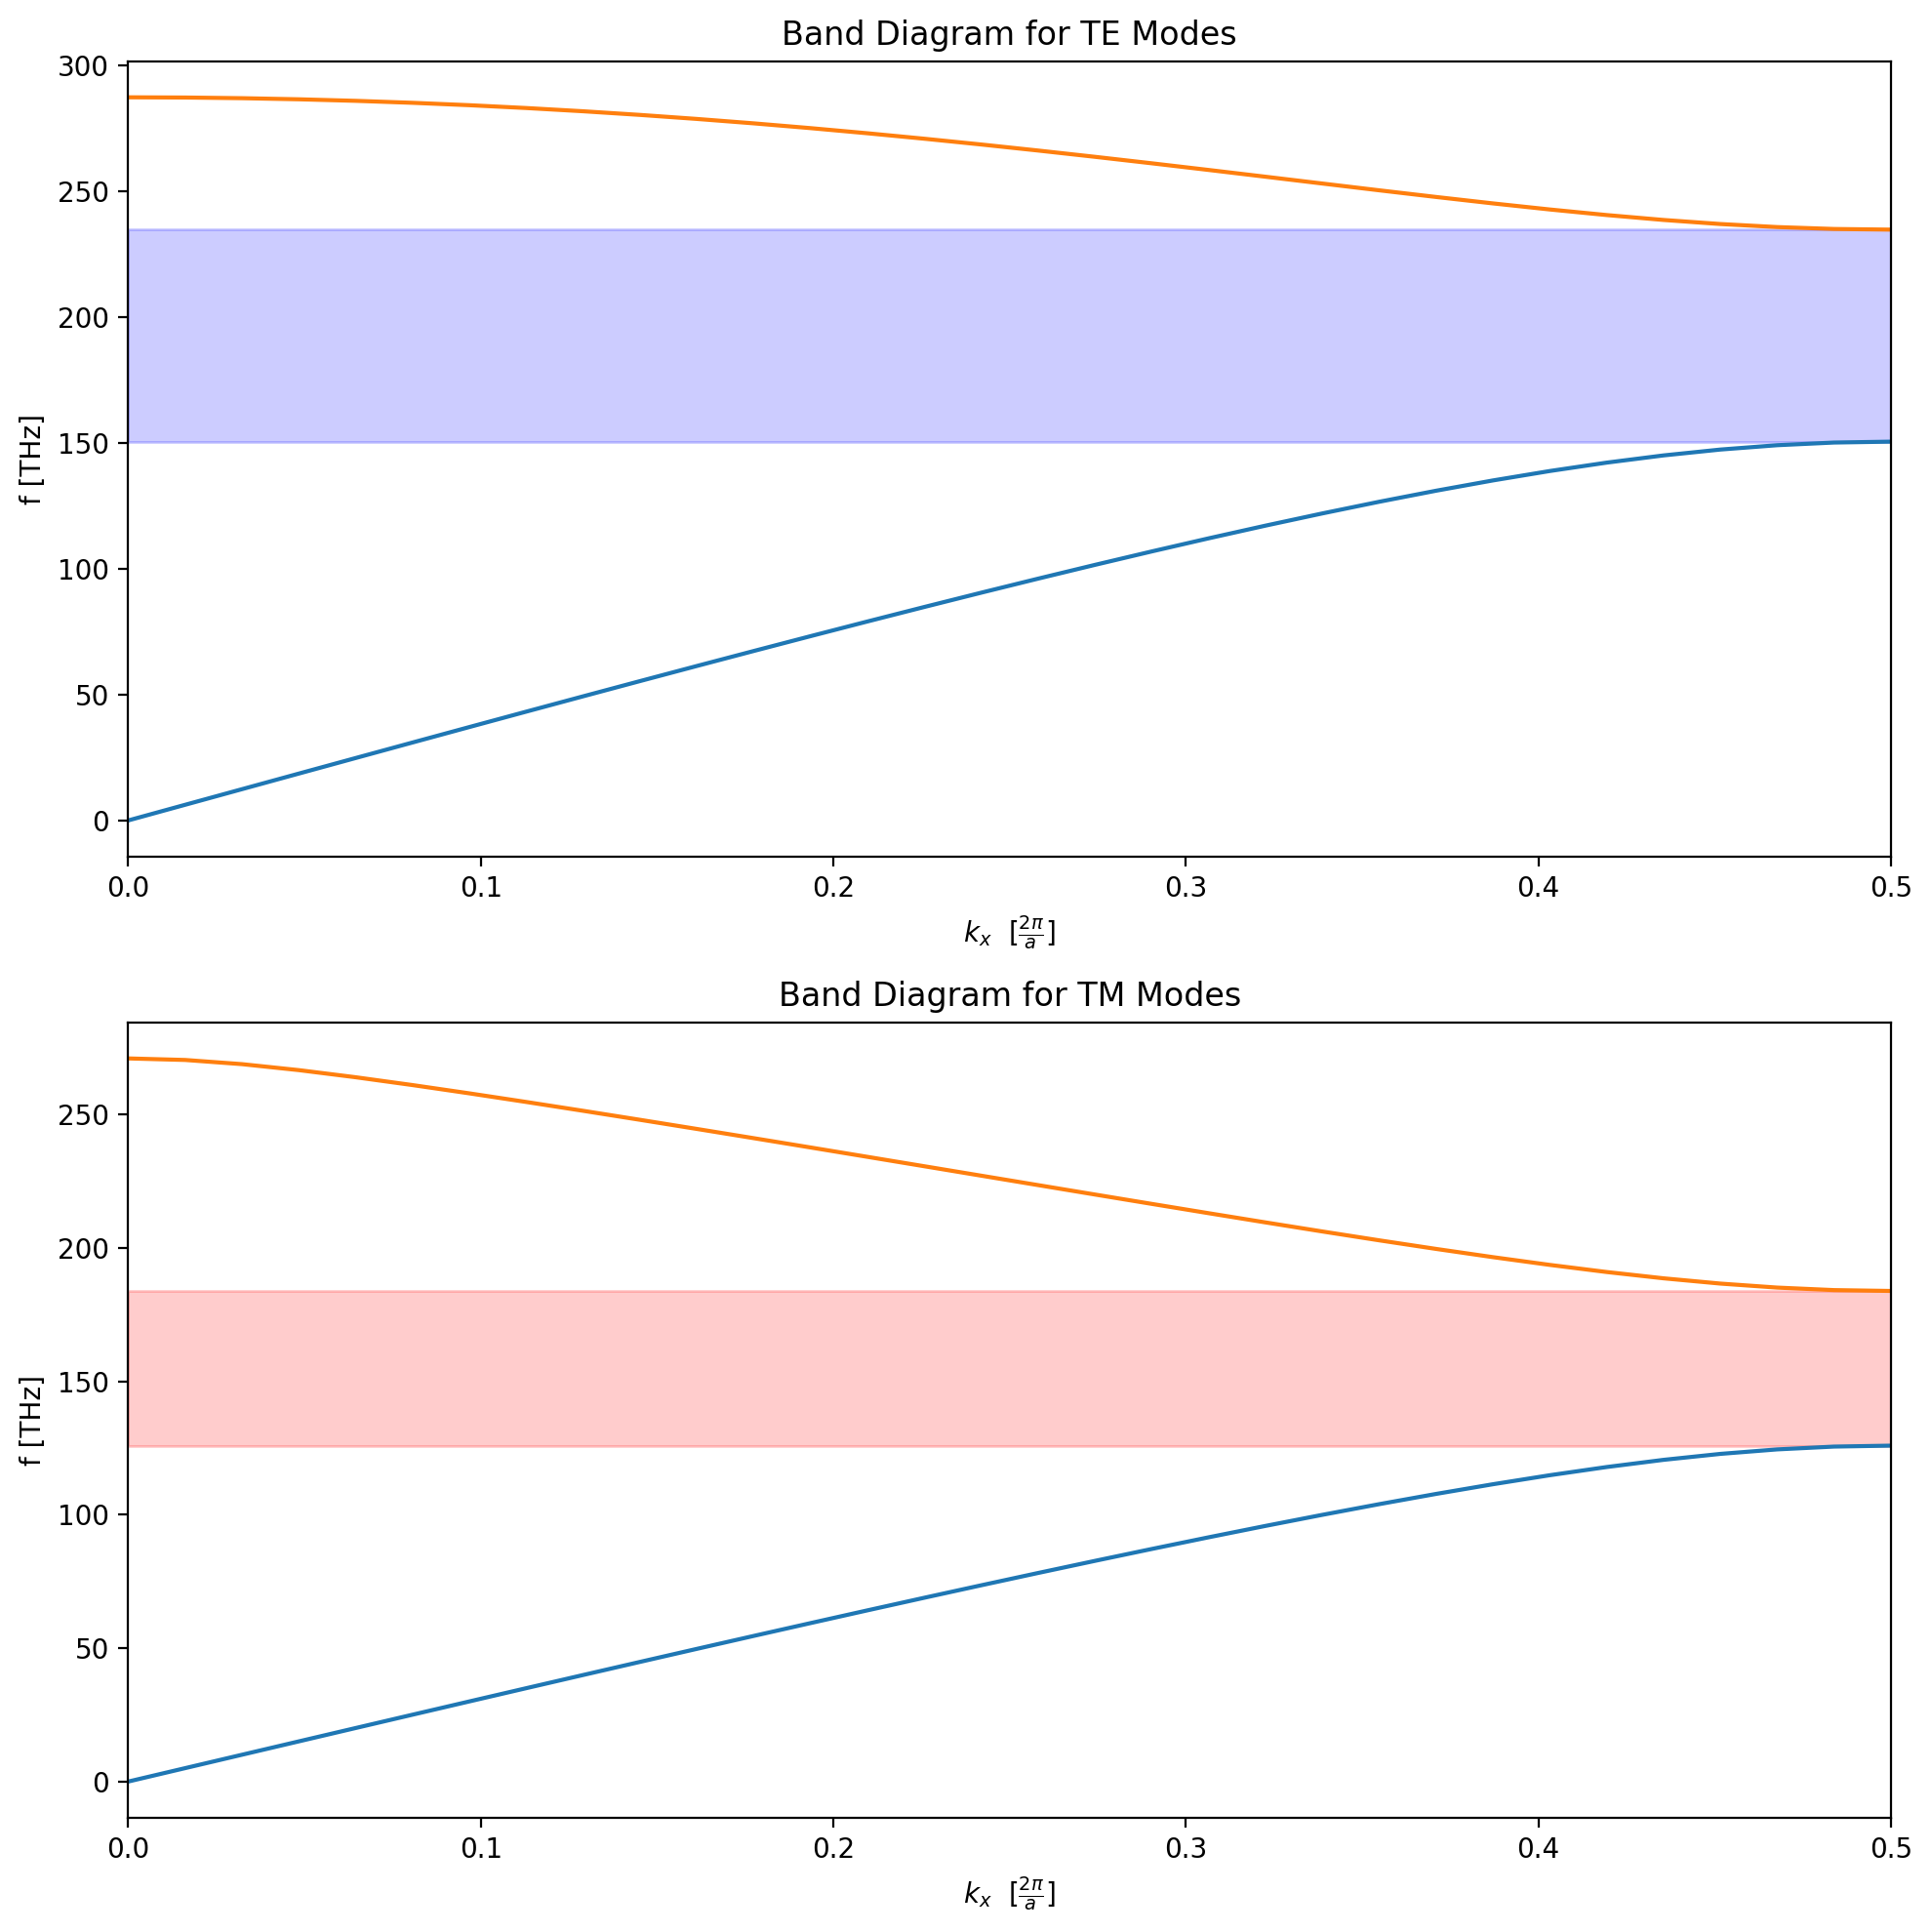

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.26009,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.463309, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

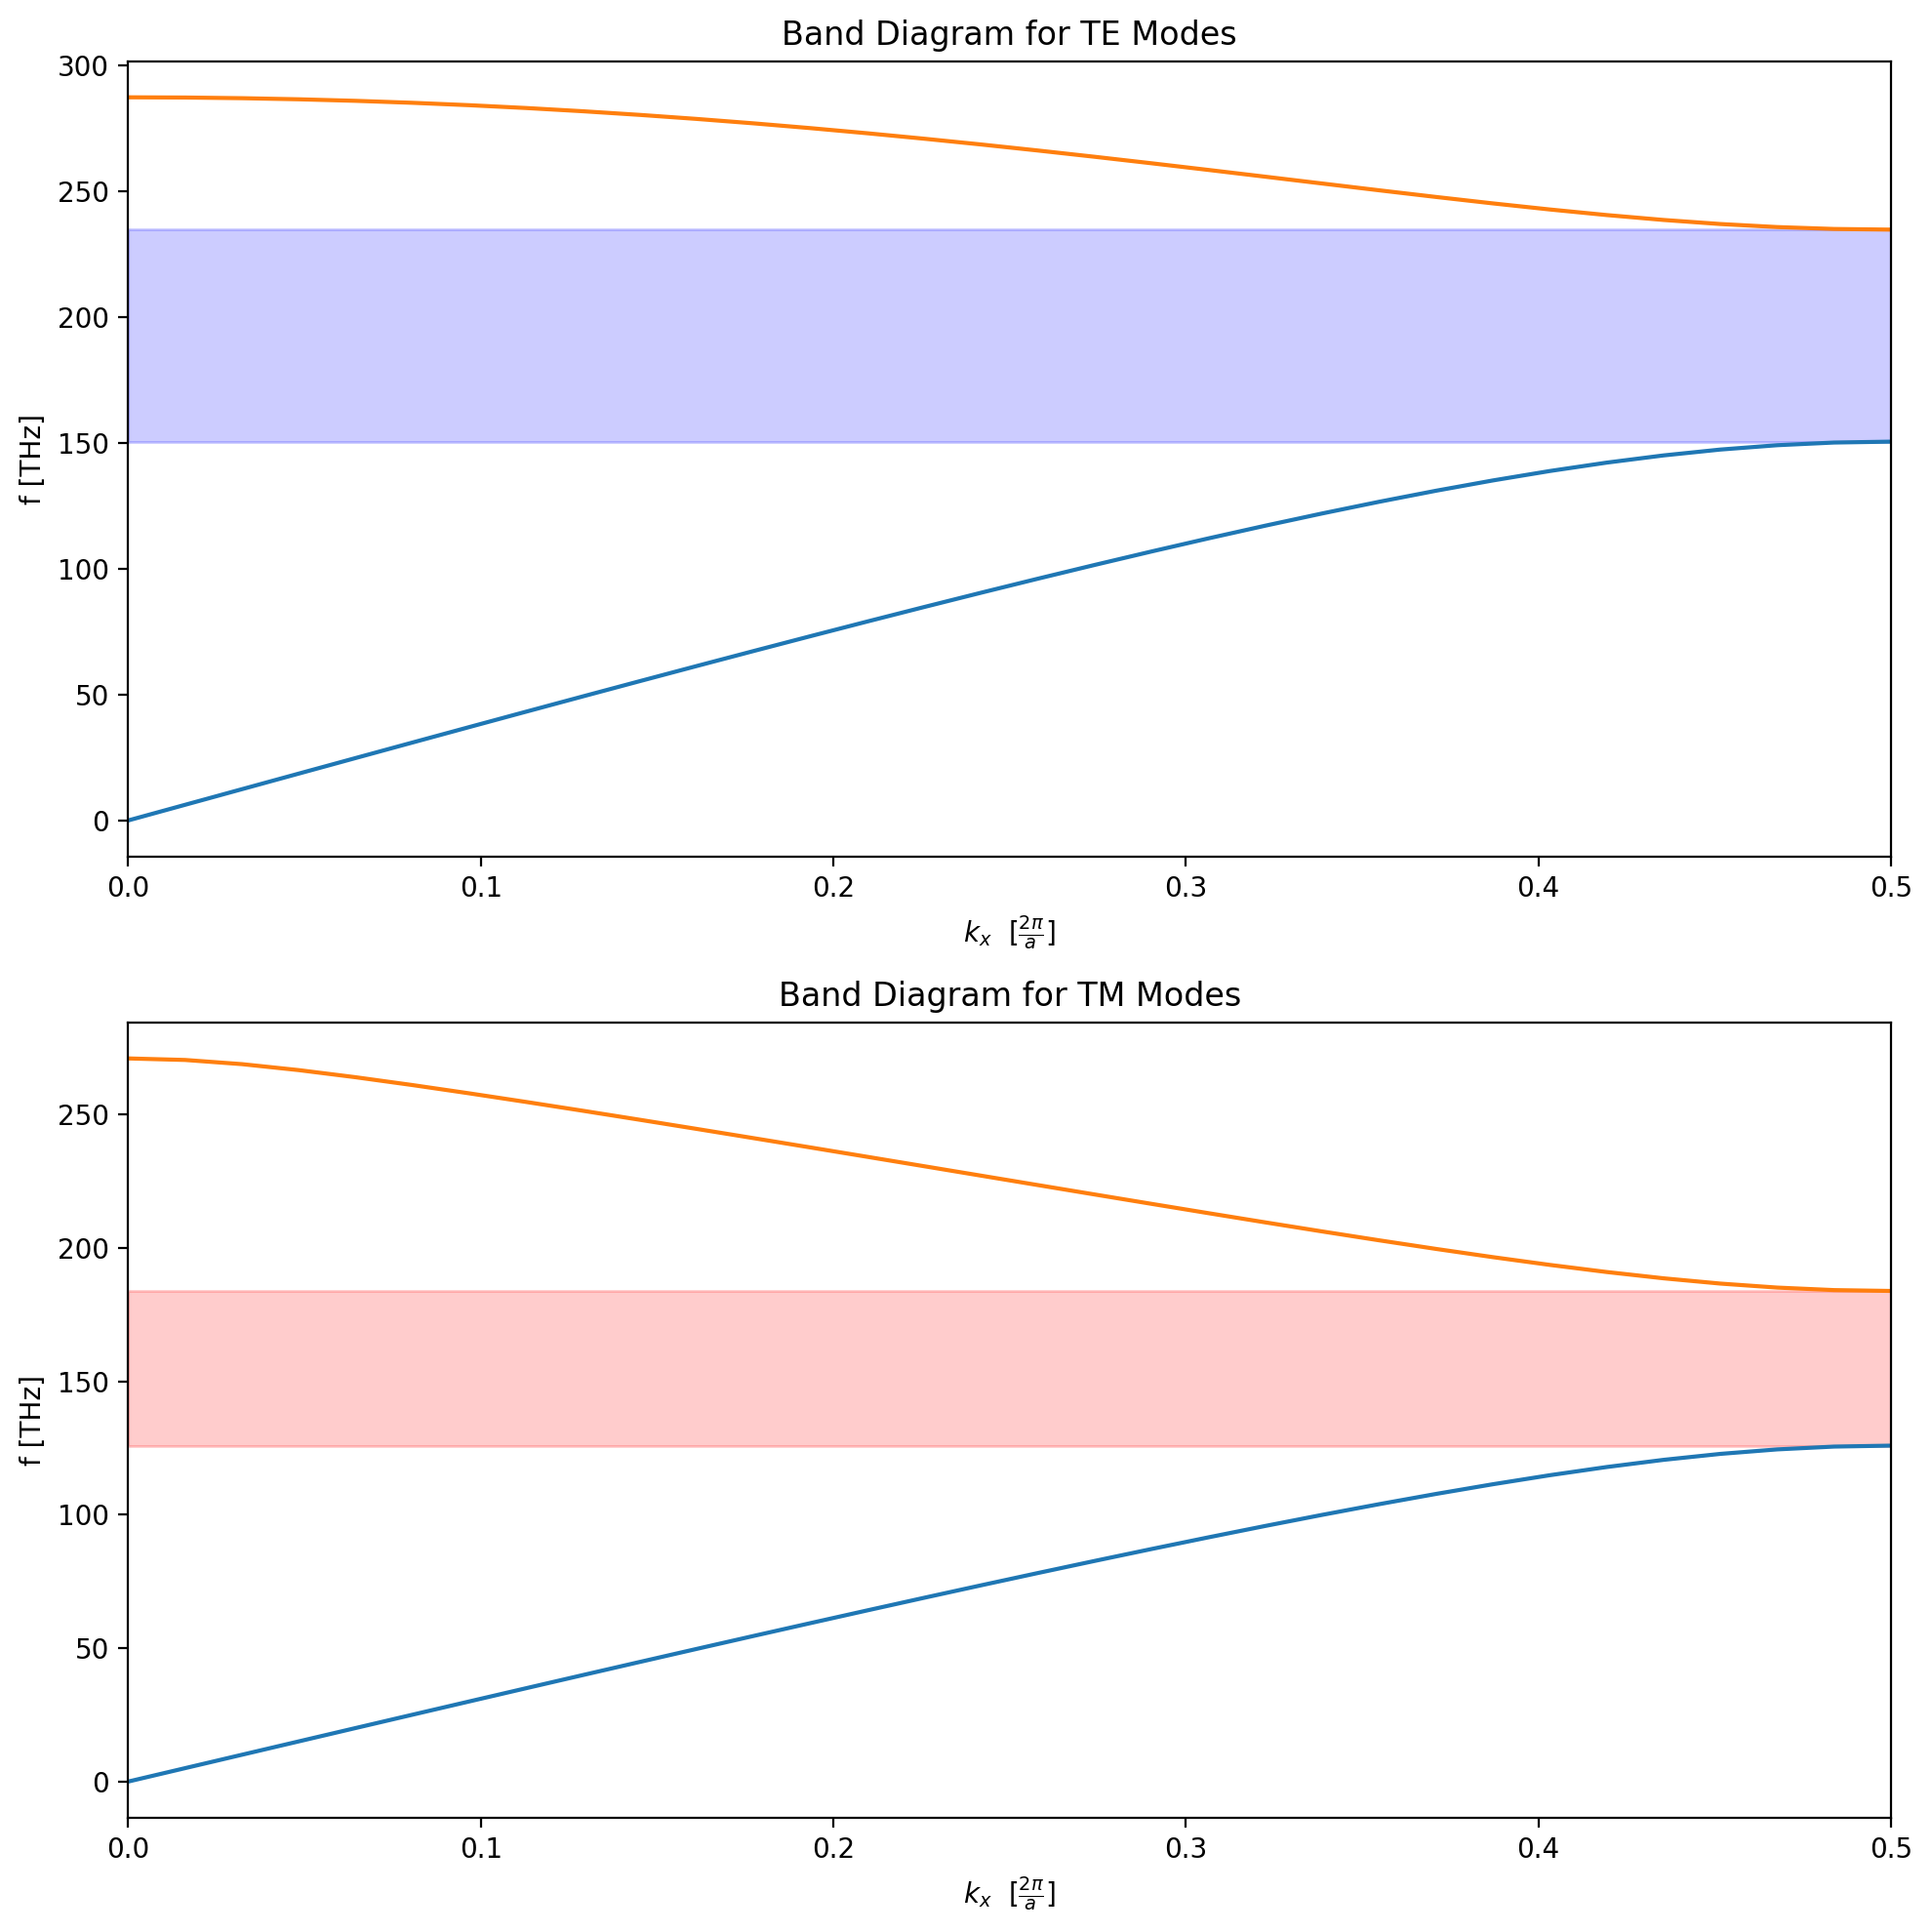

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25842,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.462473, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

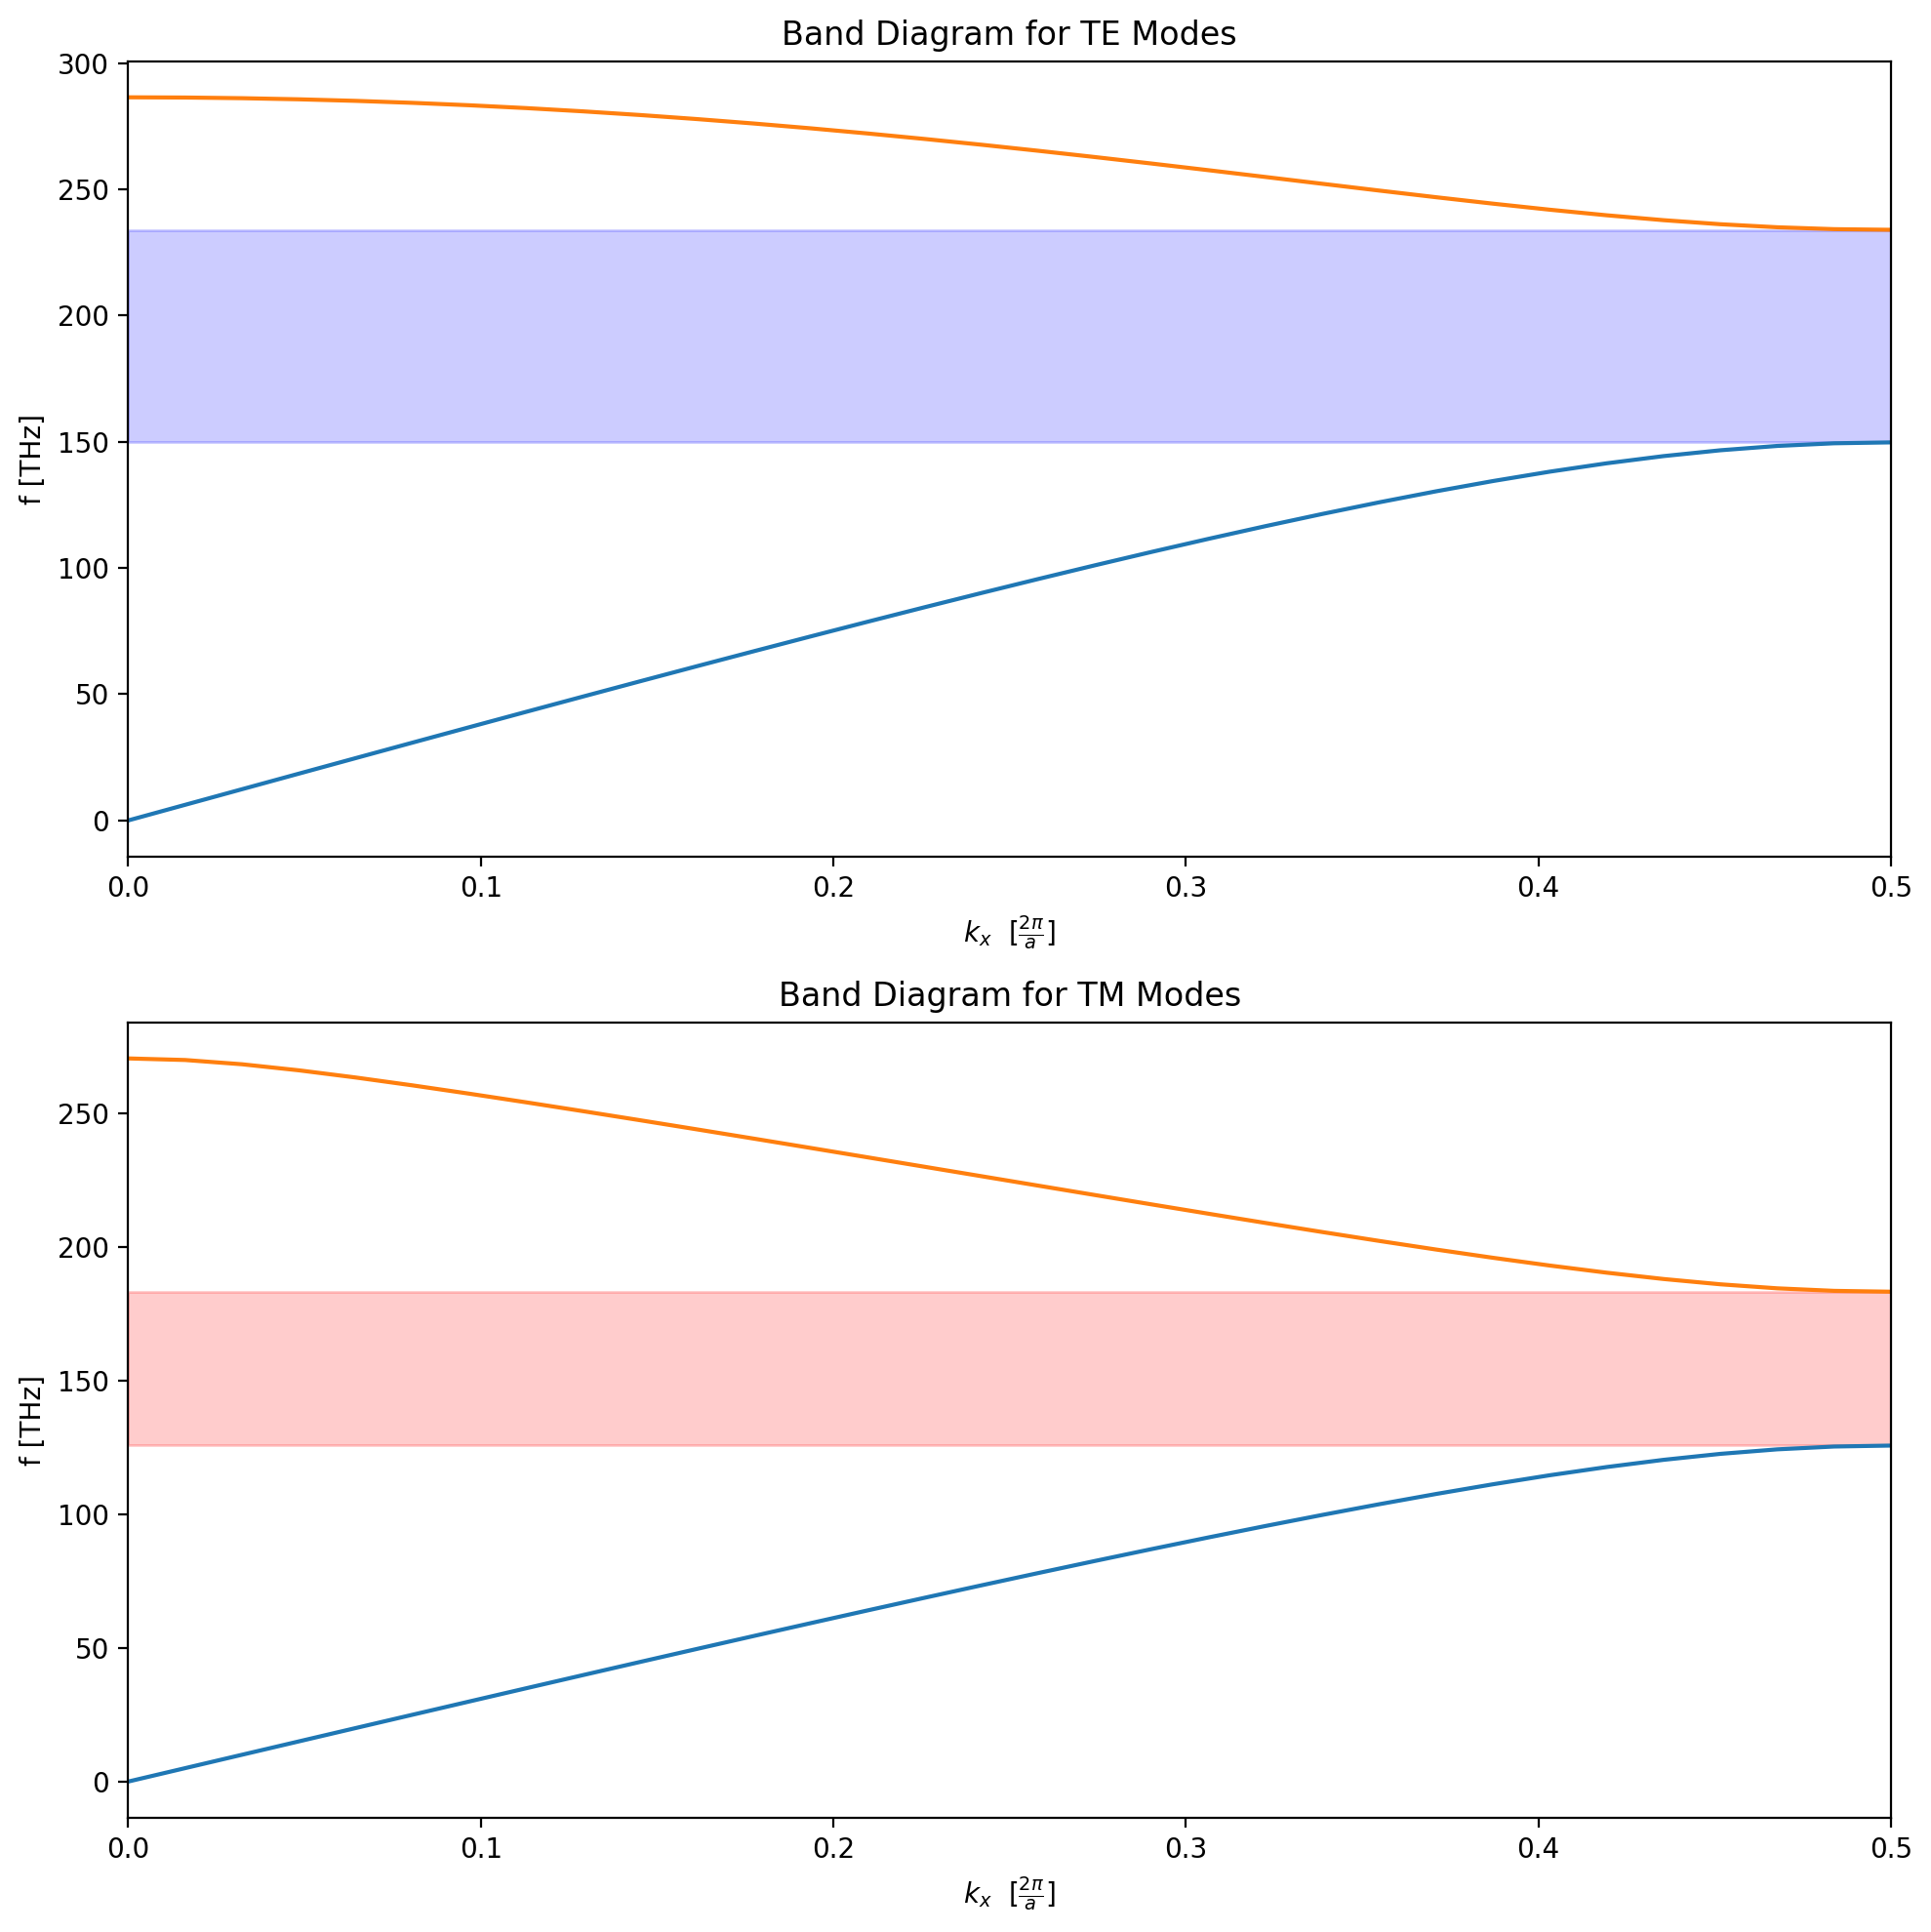

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25842,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.462473, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

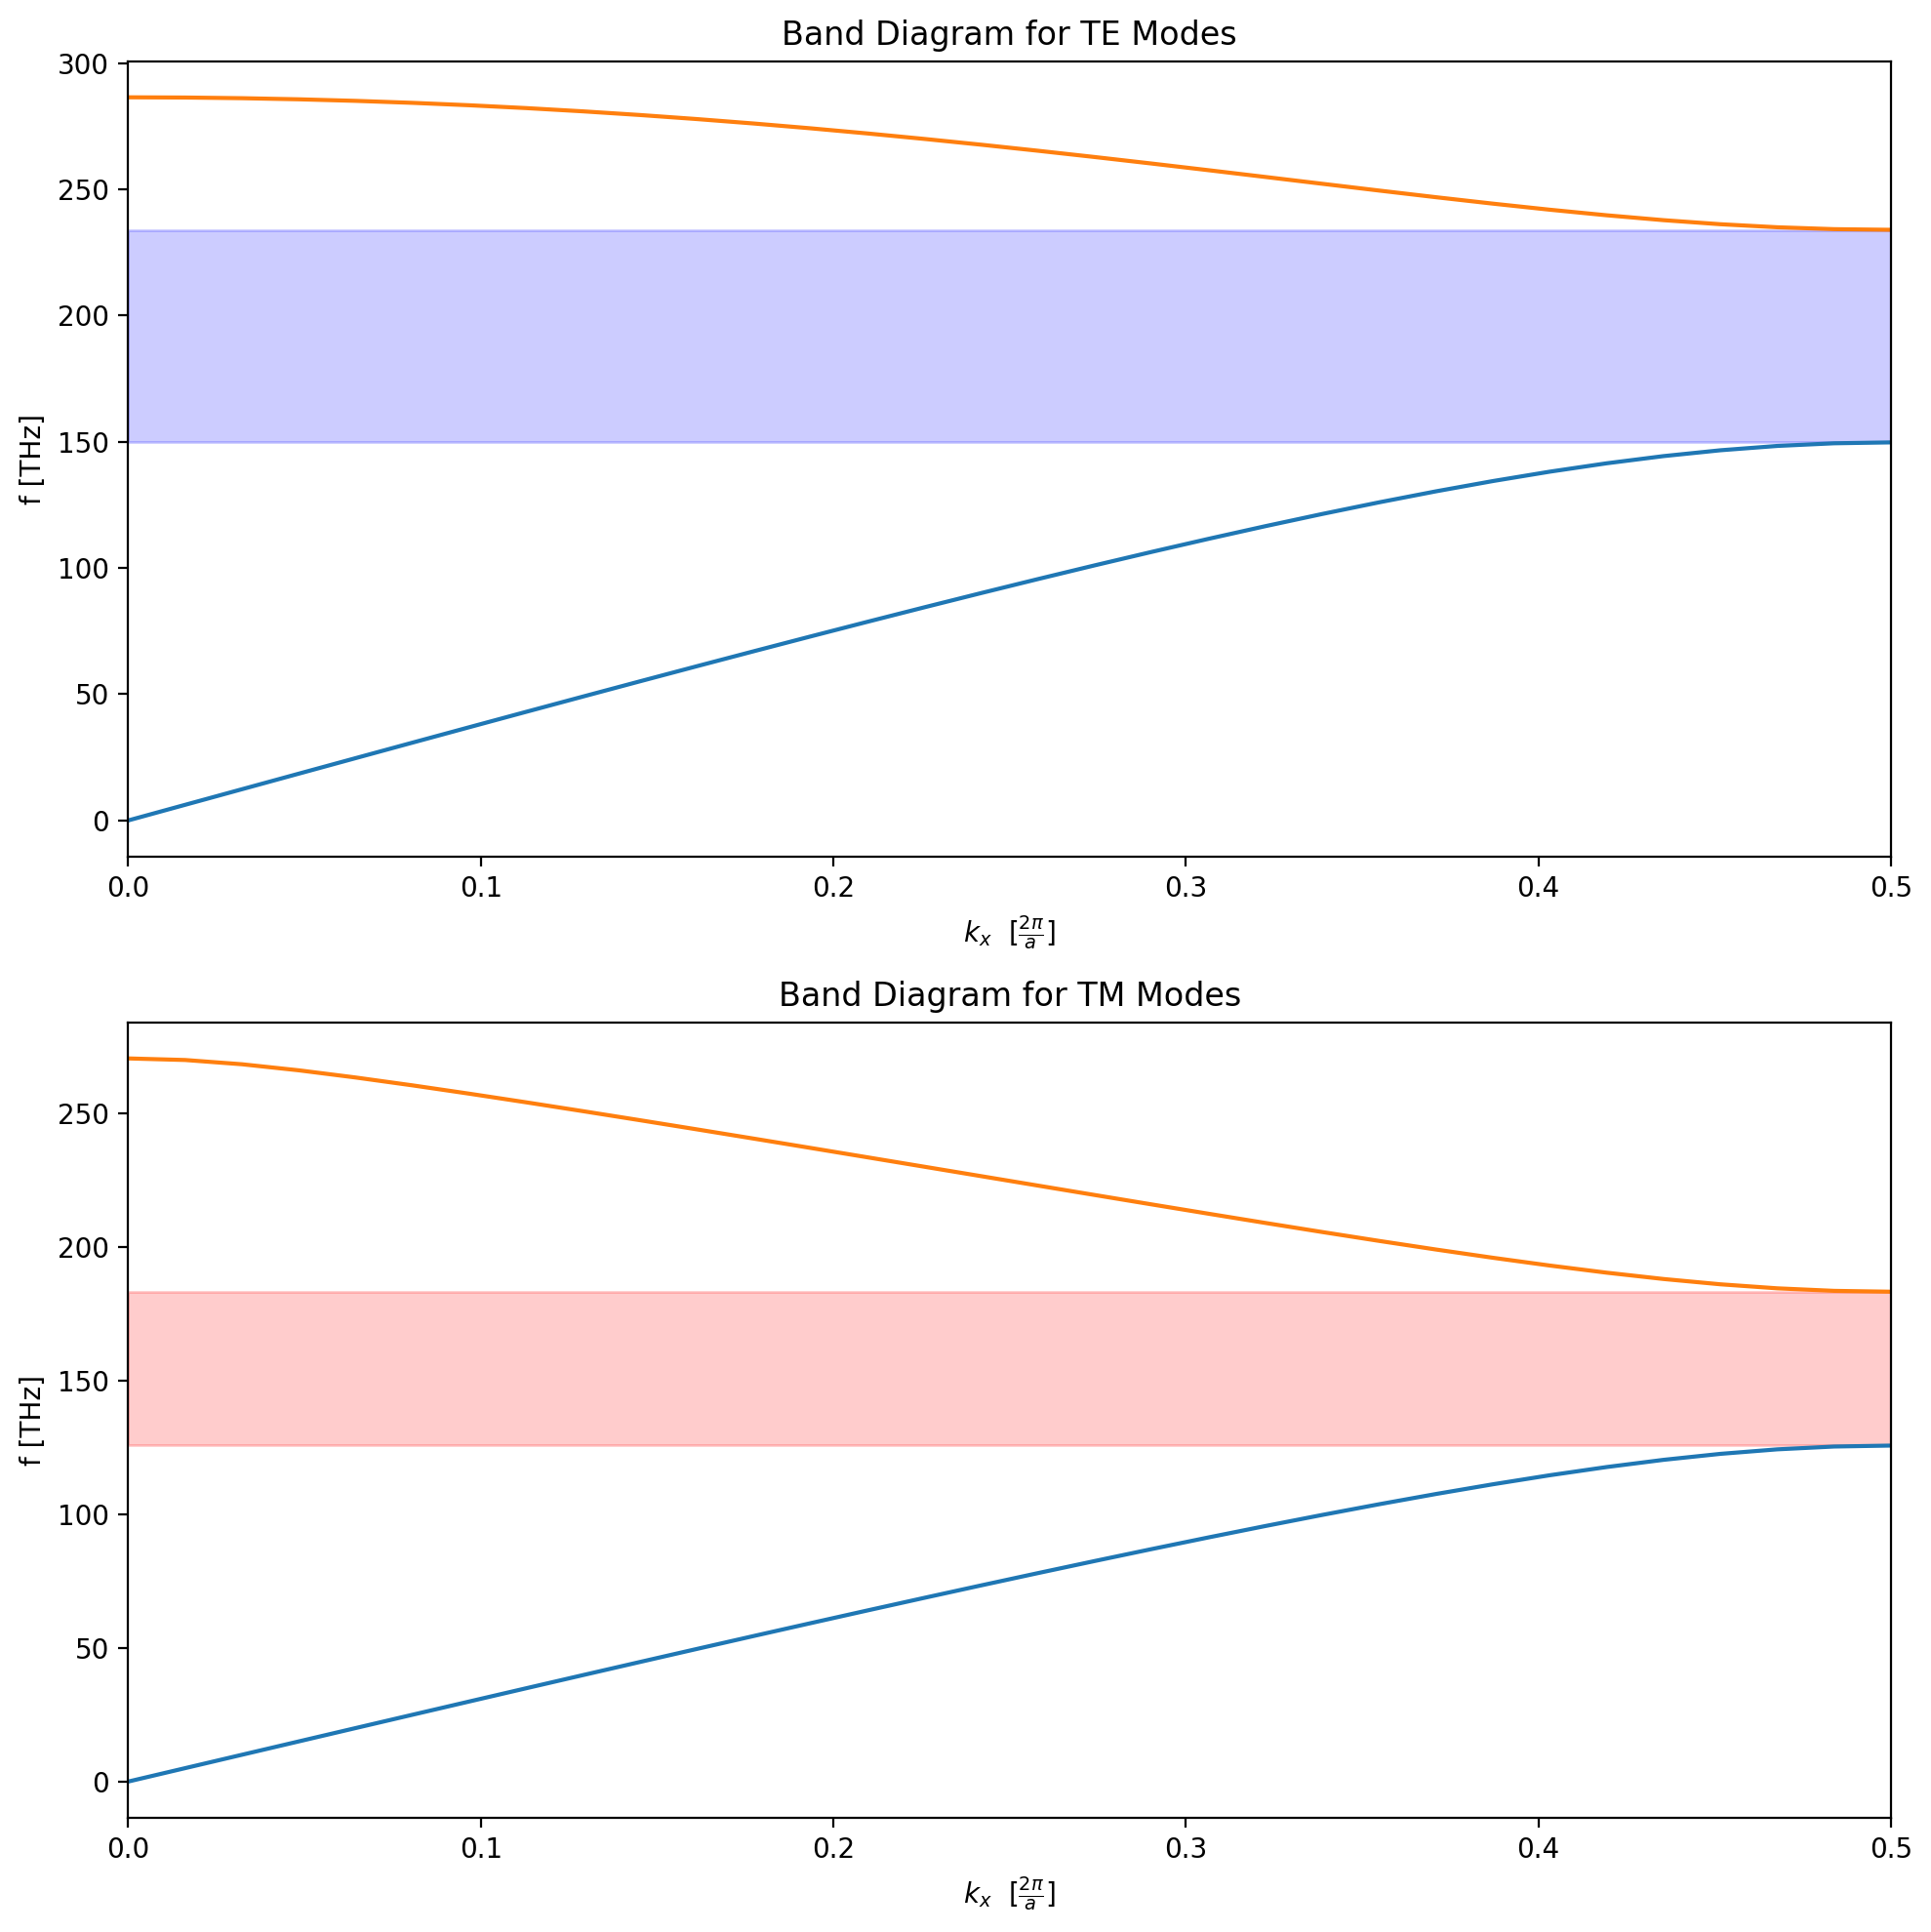

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25842,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.462473, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

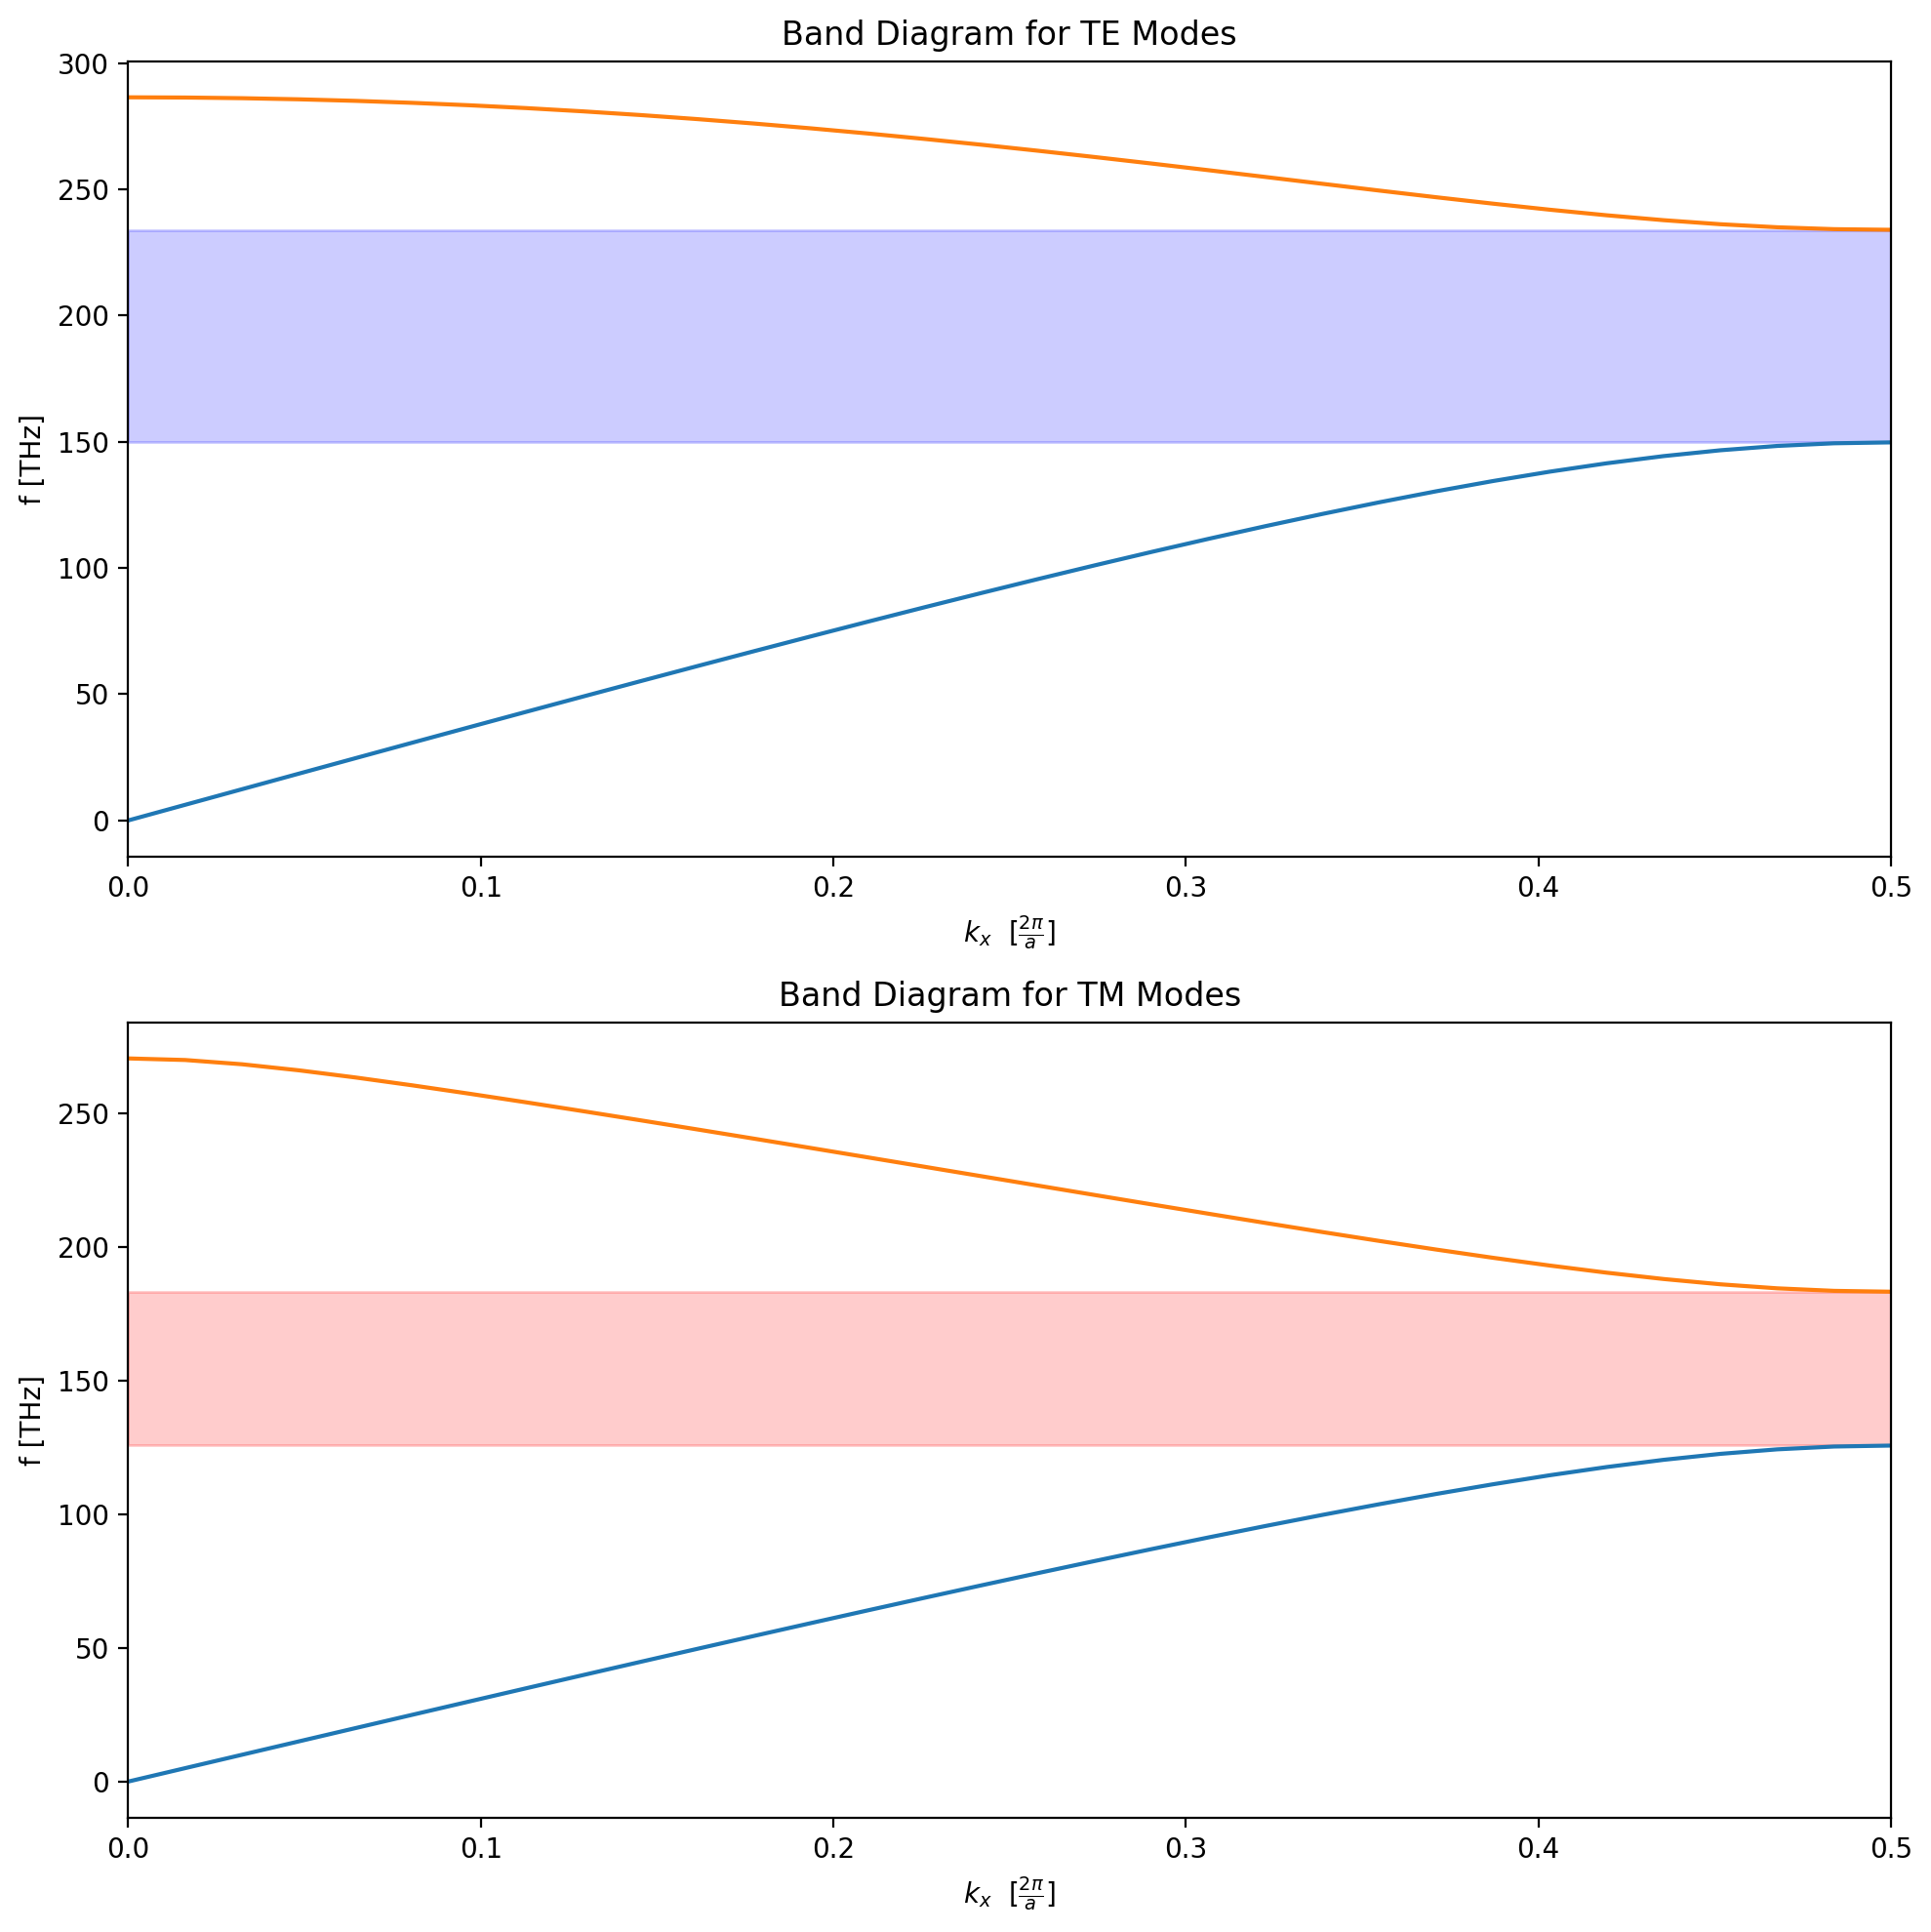

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25999,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.463259, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

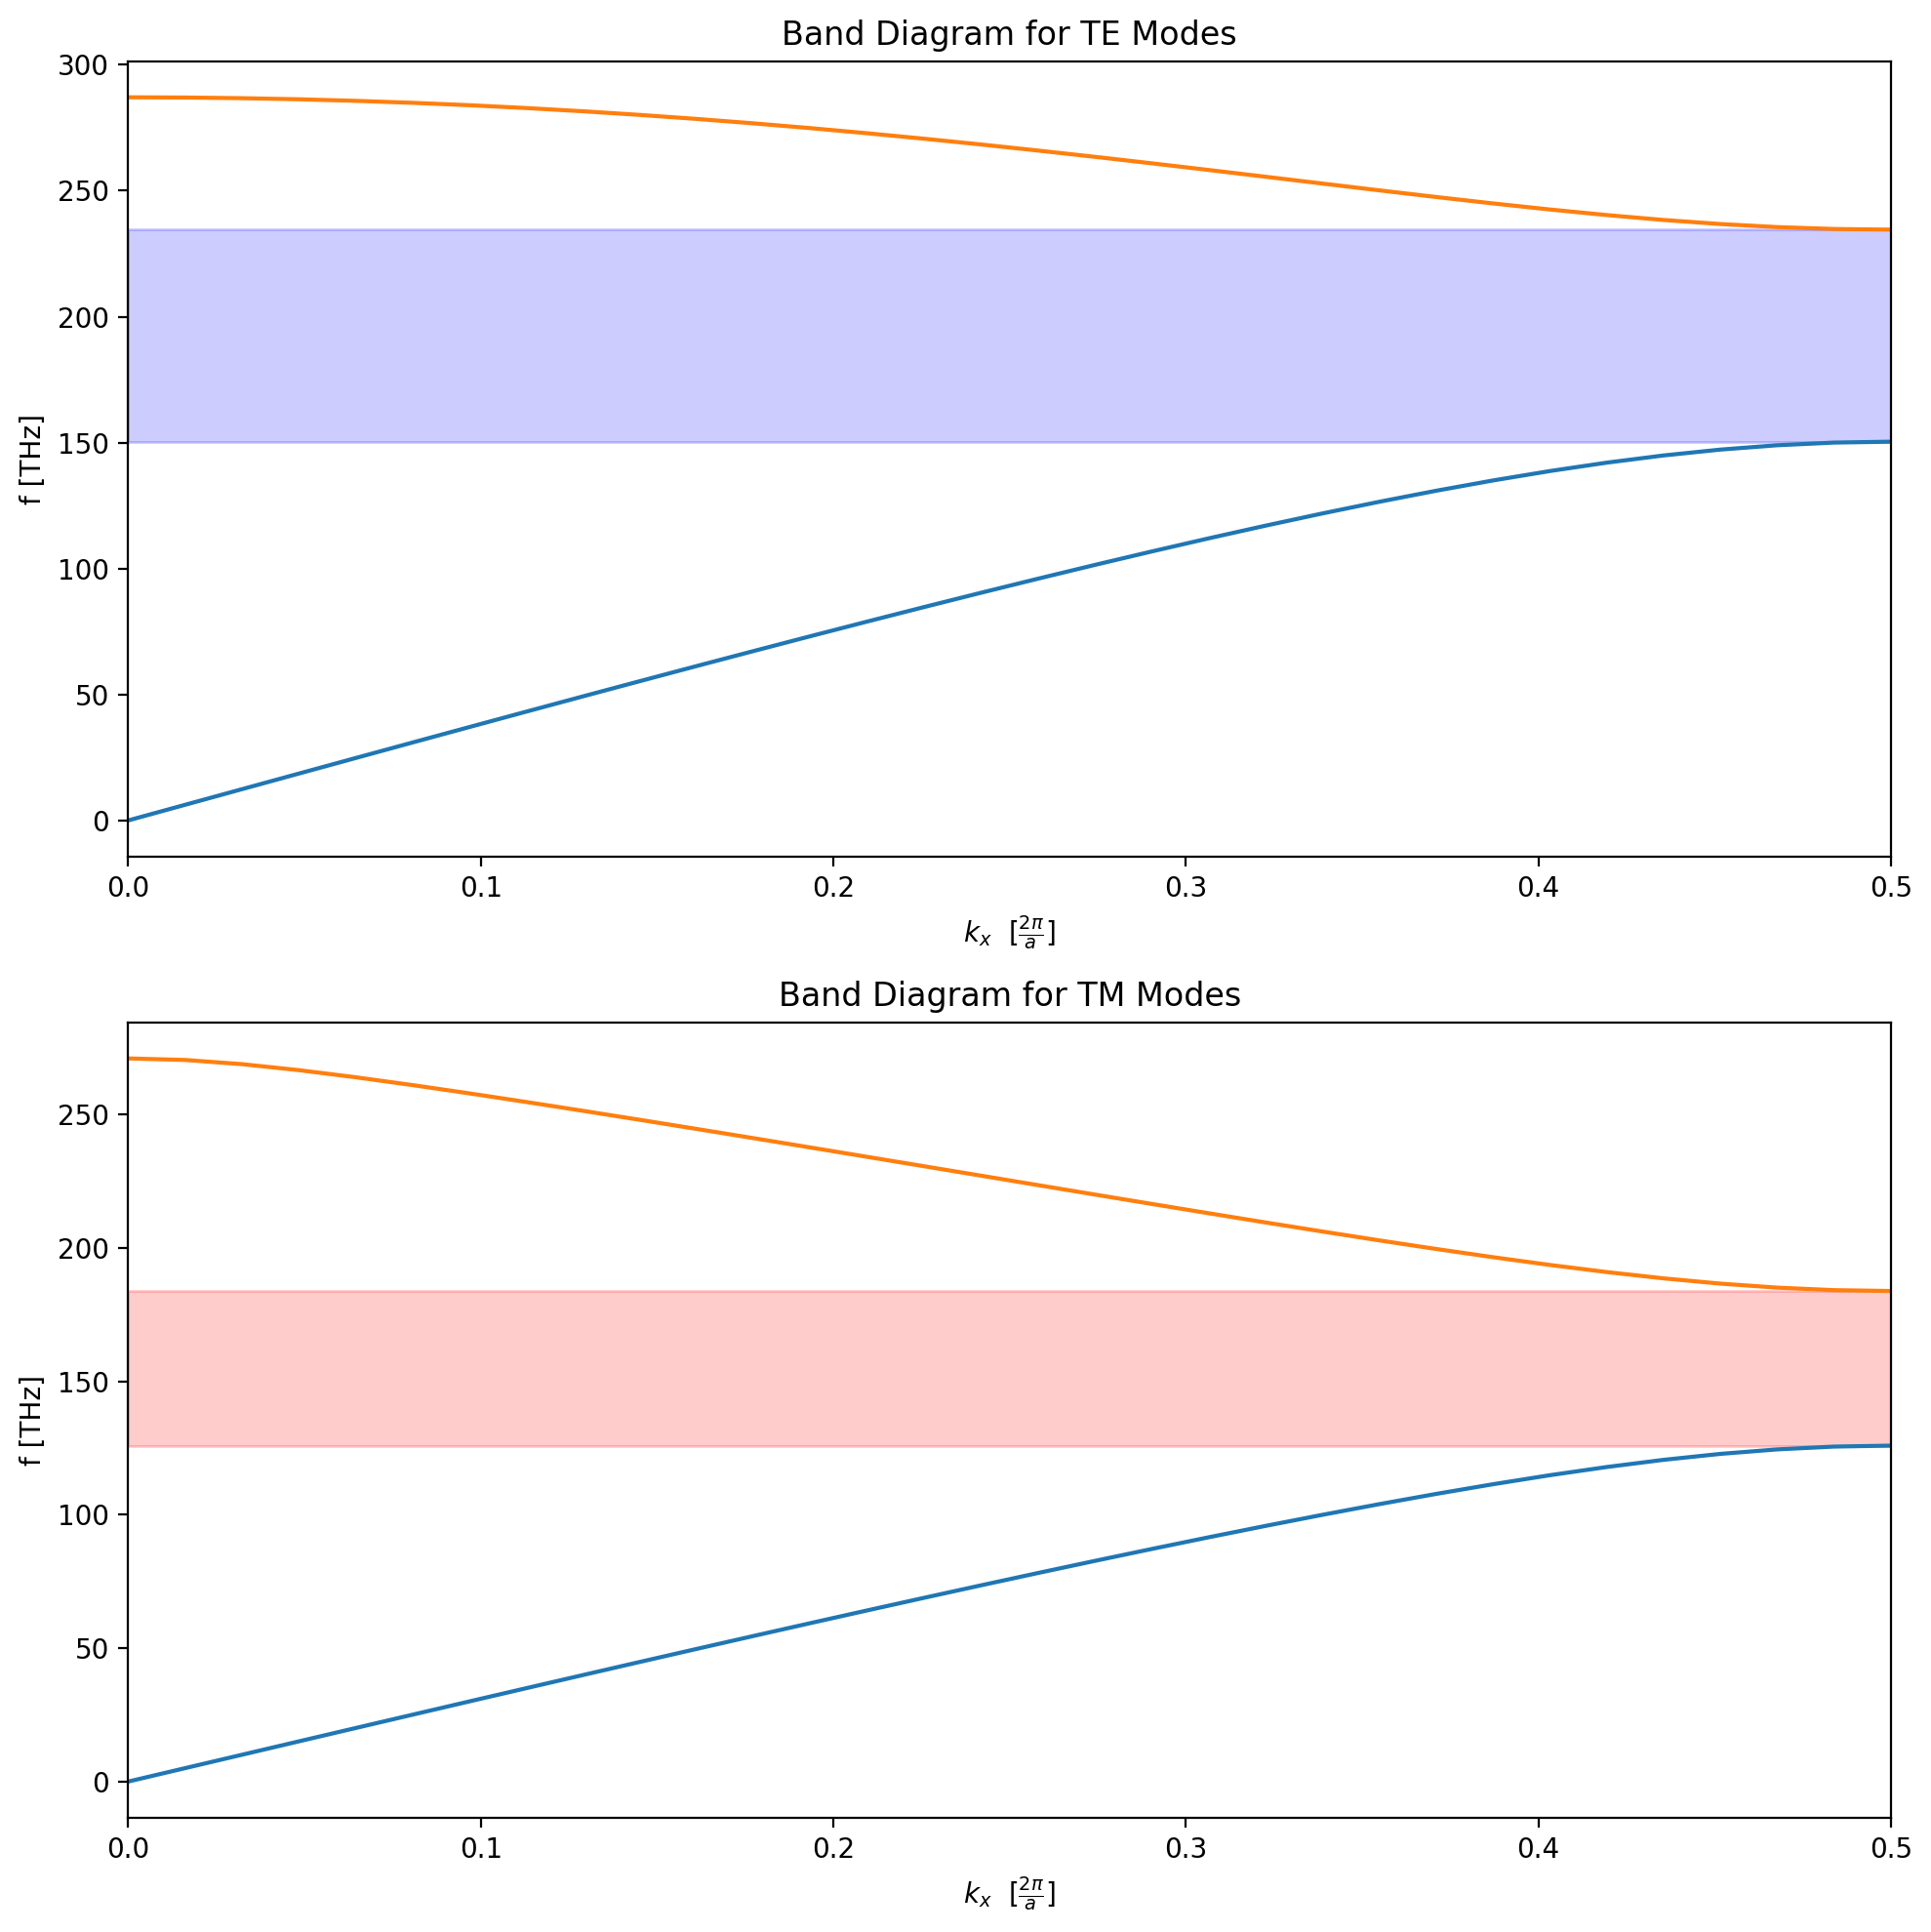

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25918,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.462854, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

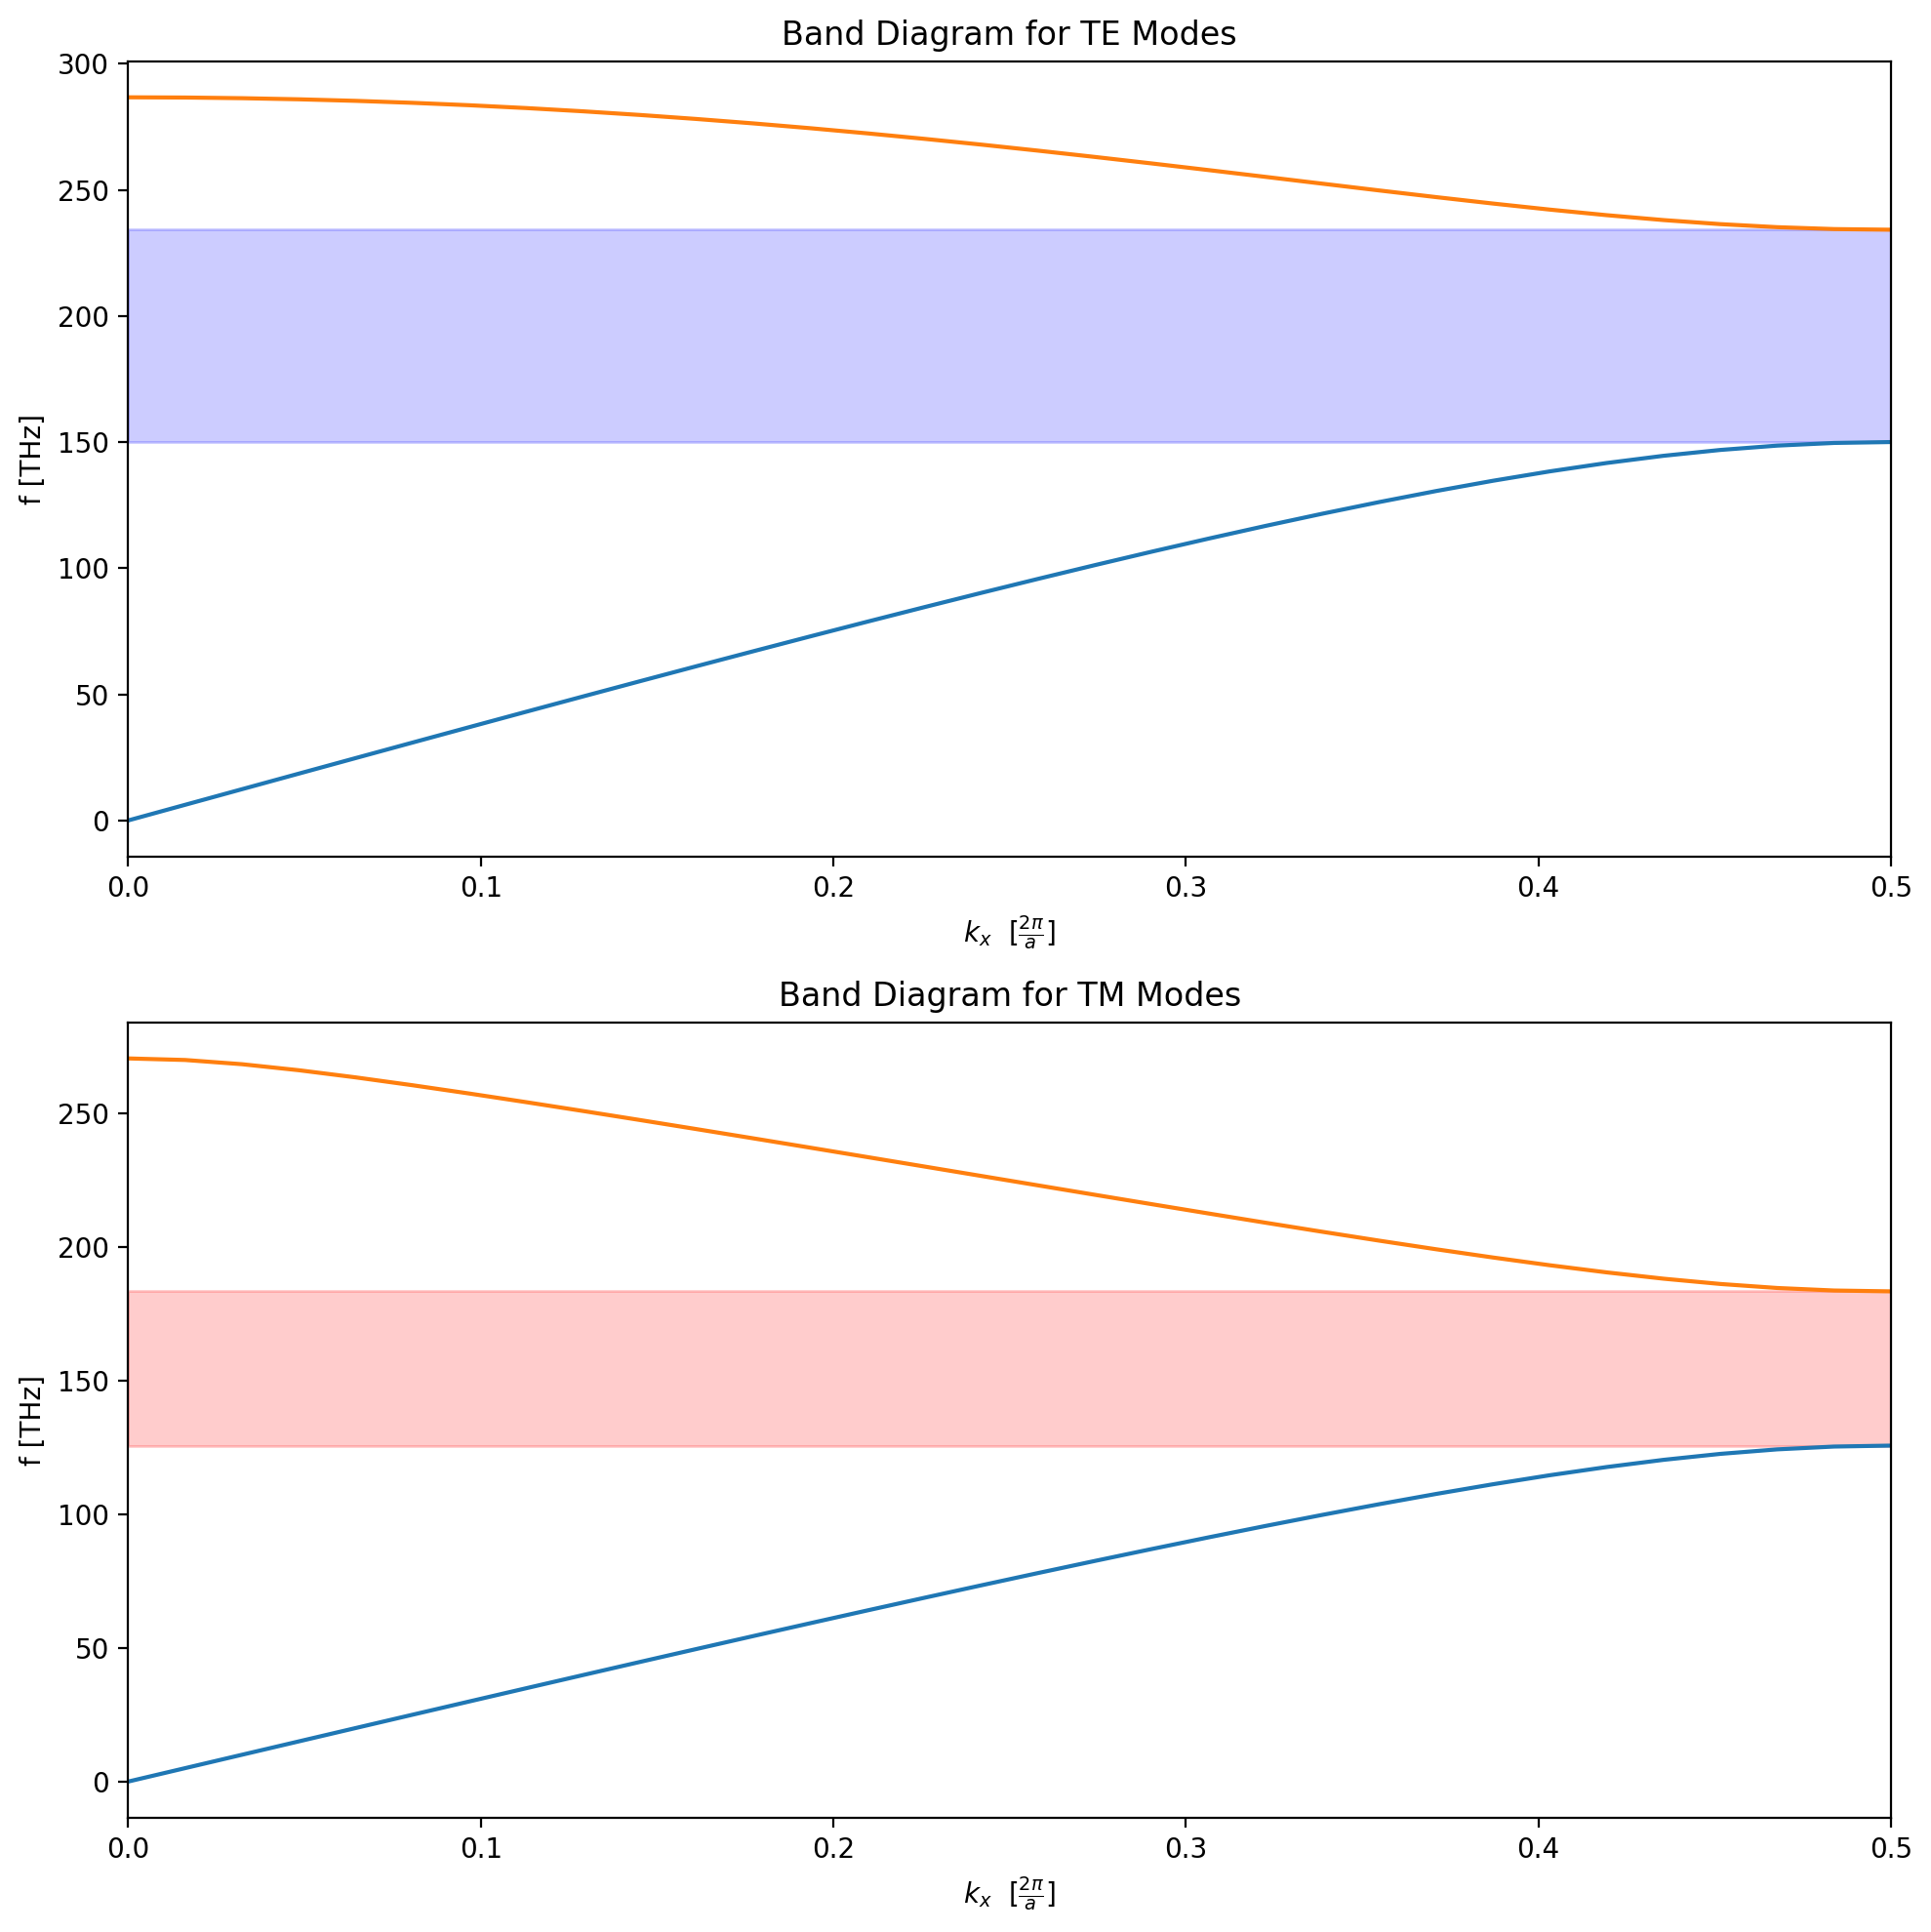

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.2588,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.462662, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516

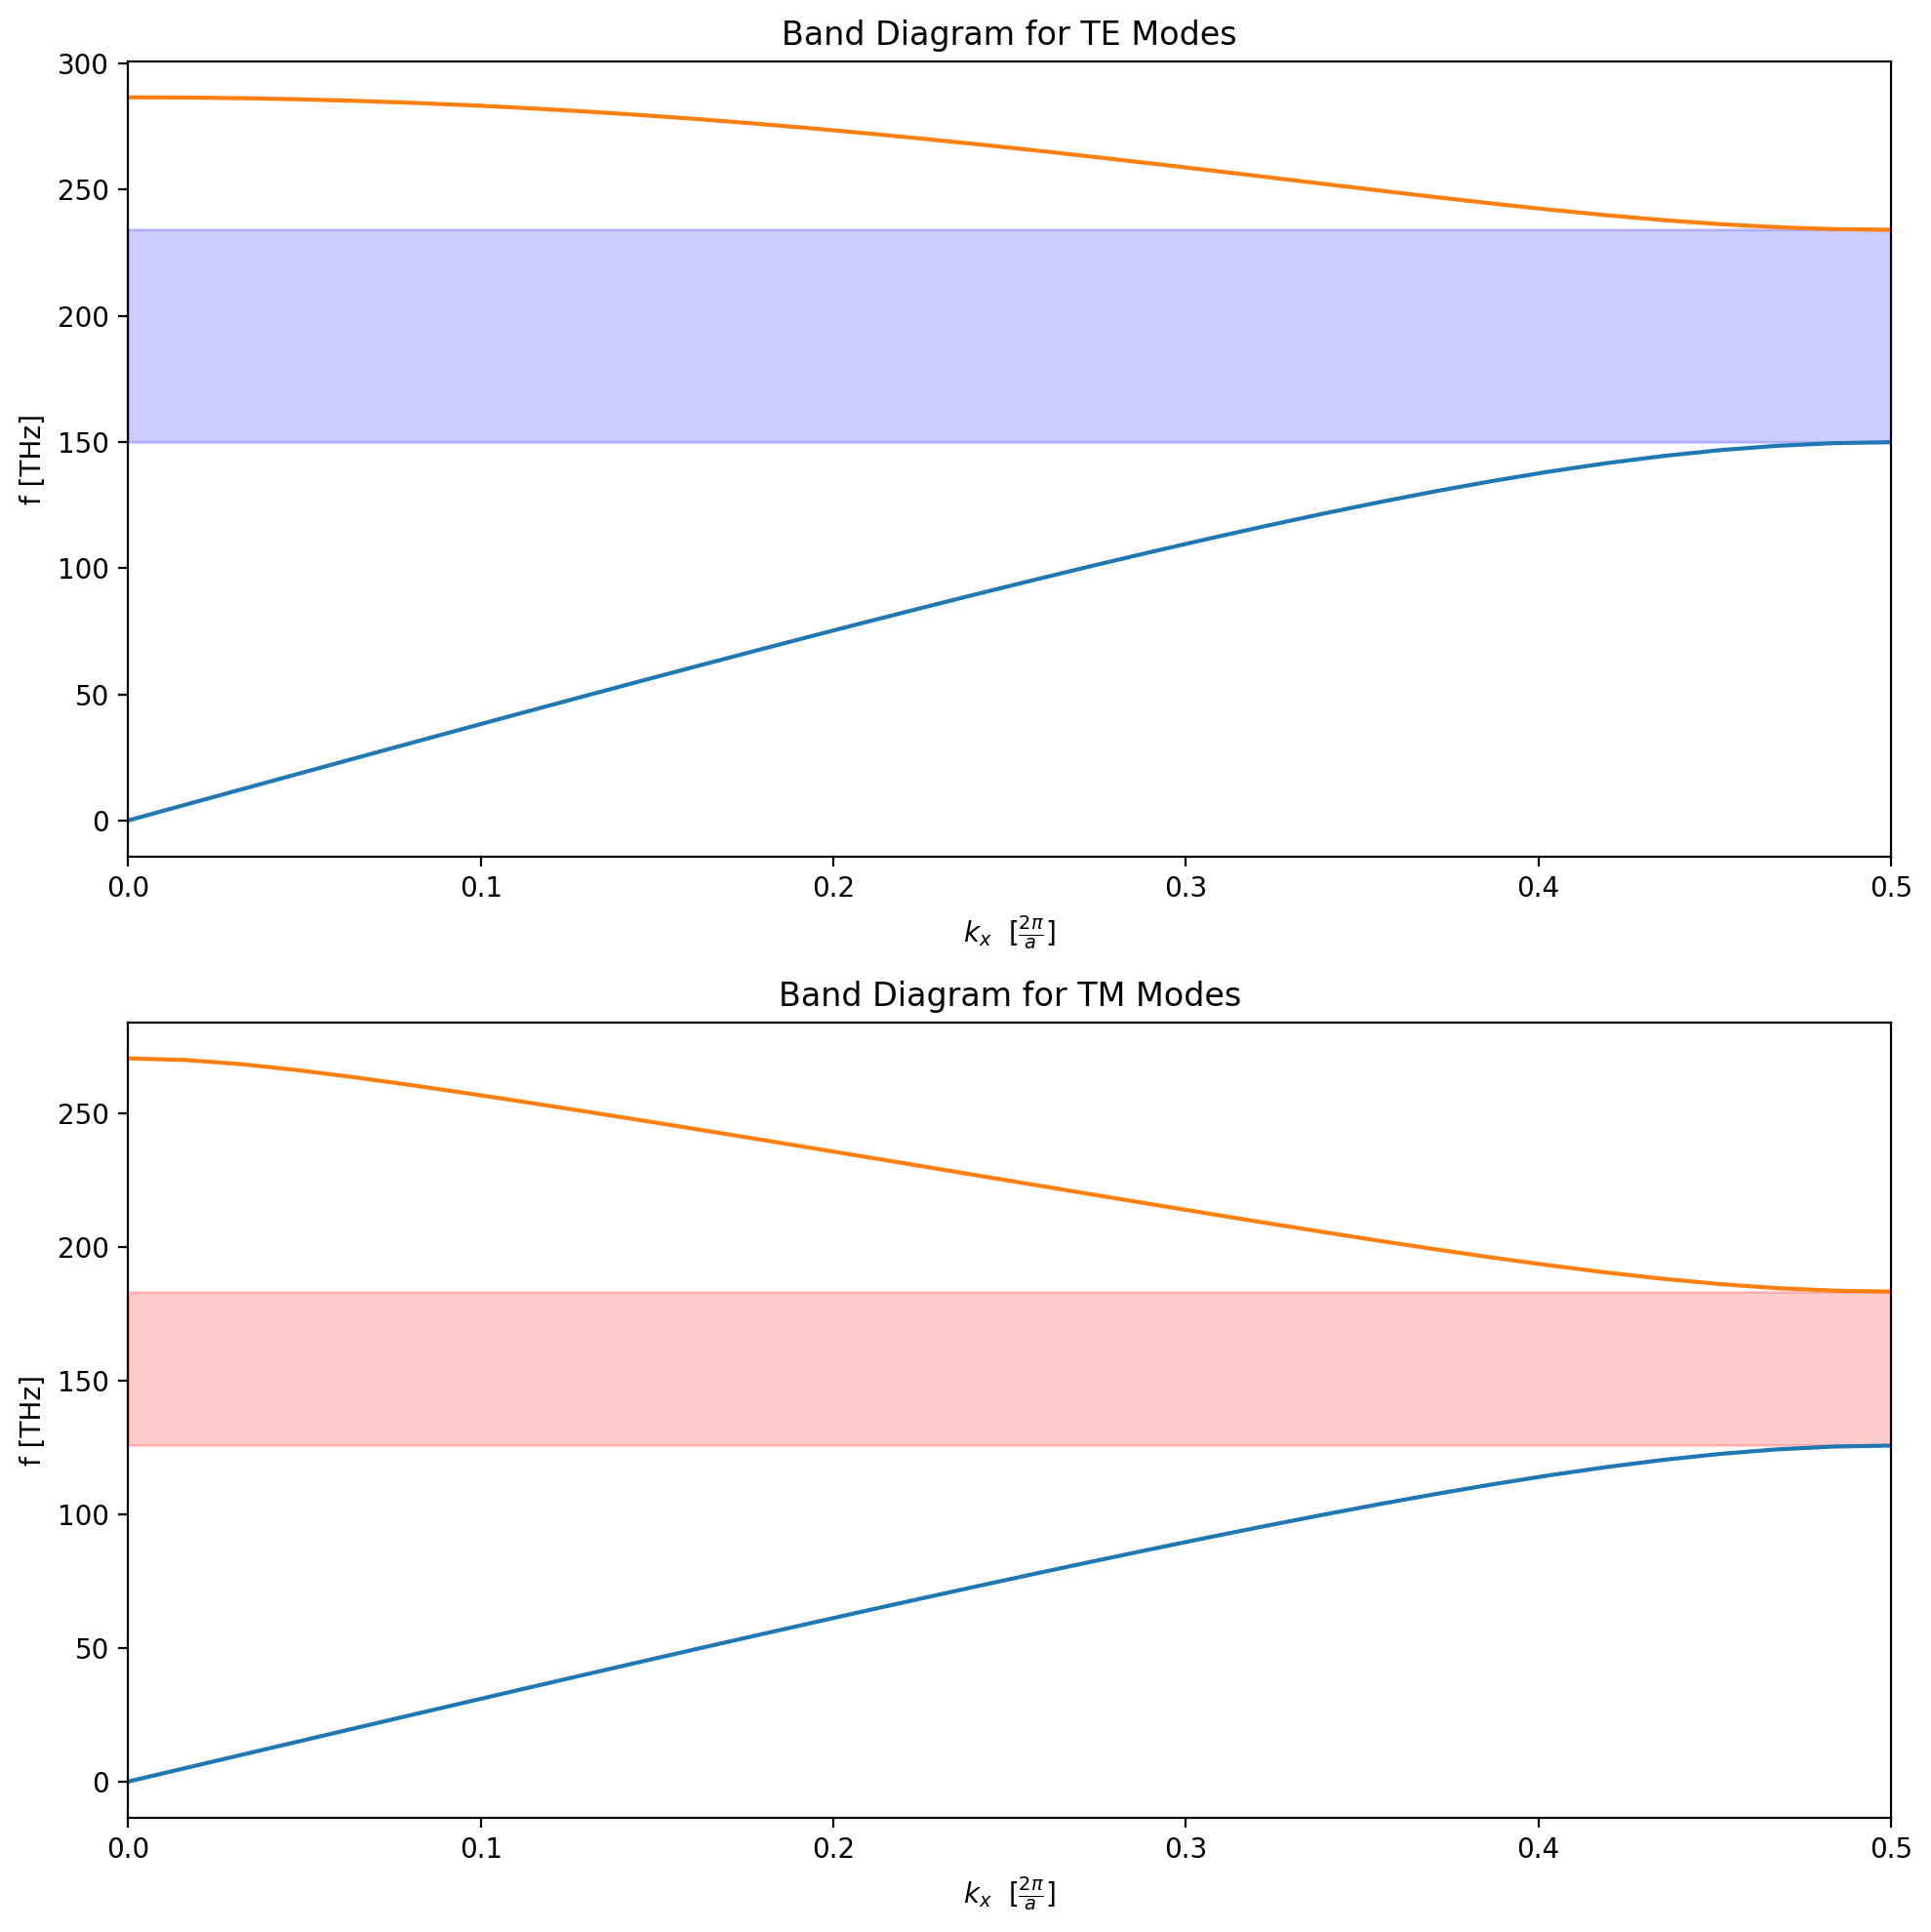

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25861,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.462567, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

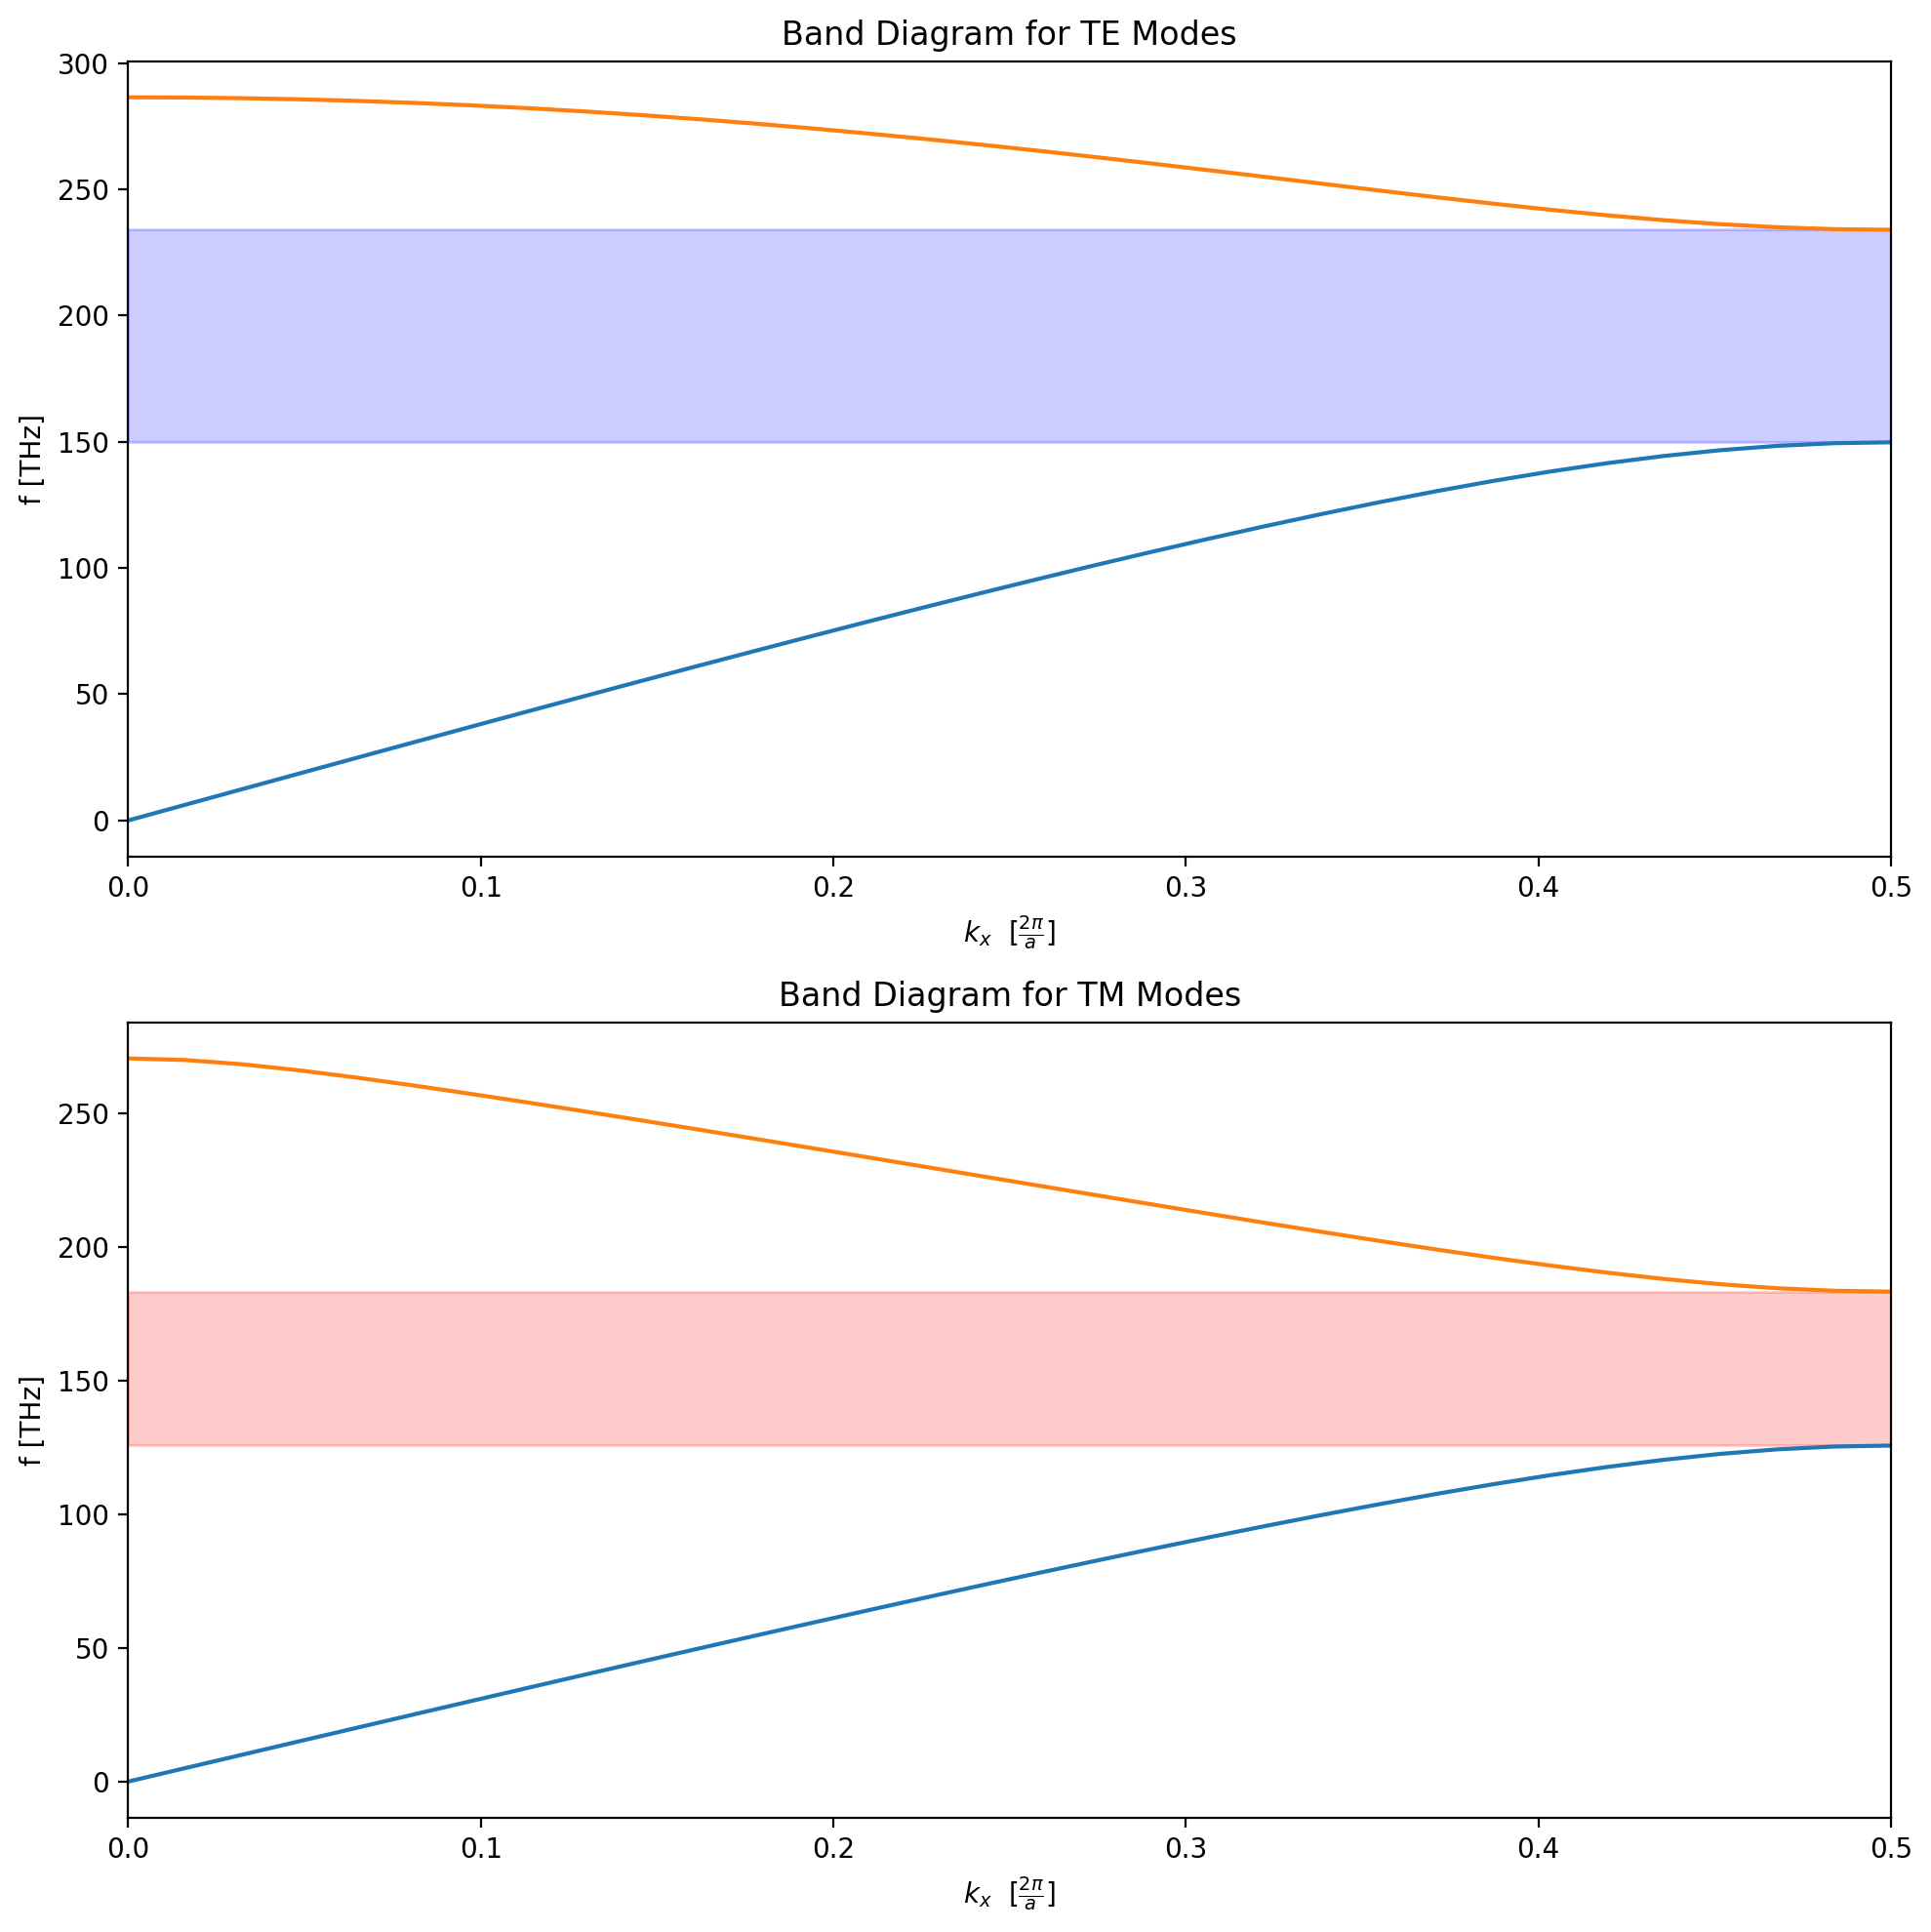

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25852,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.46252, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516

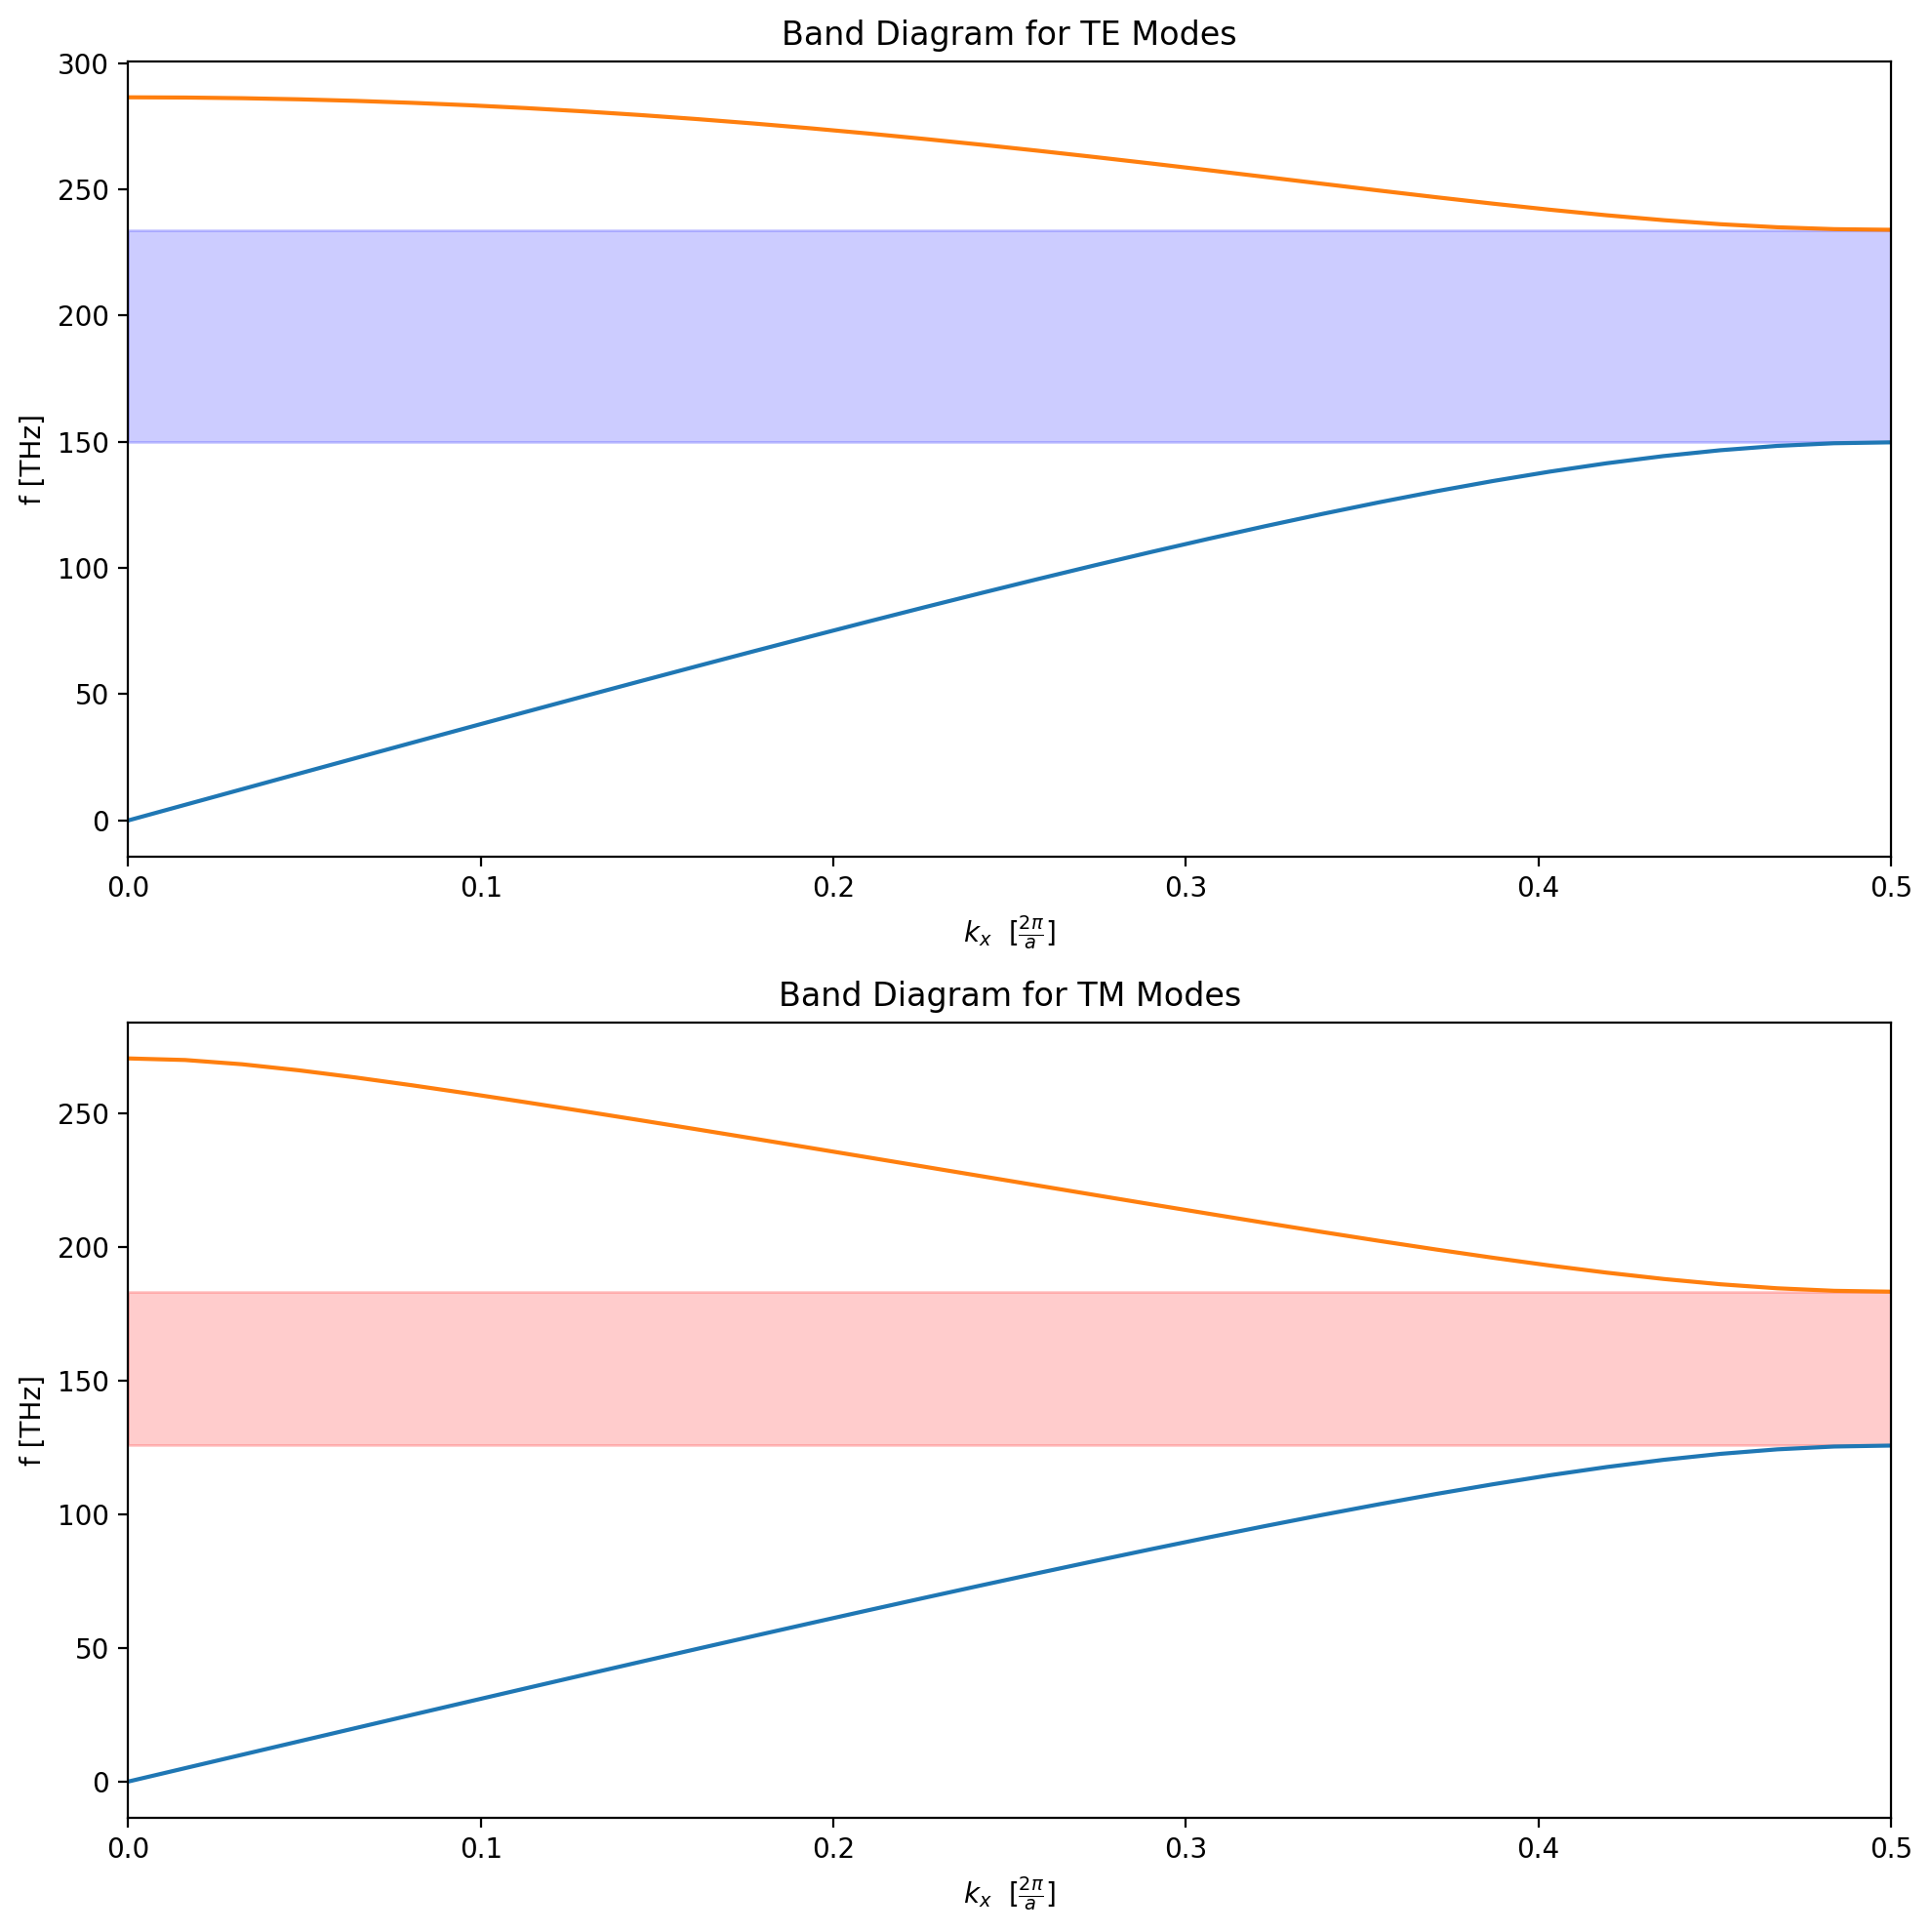

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25847,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.462497, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

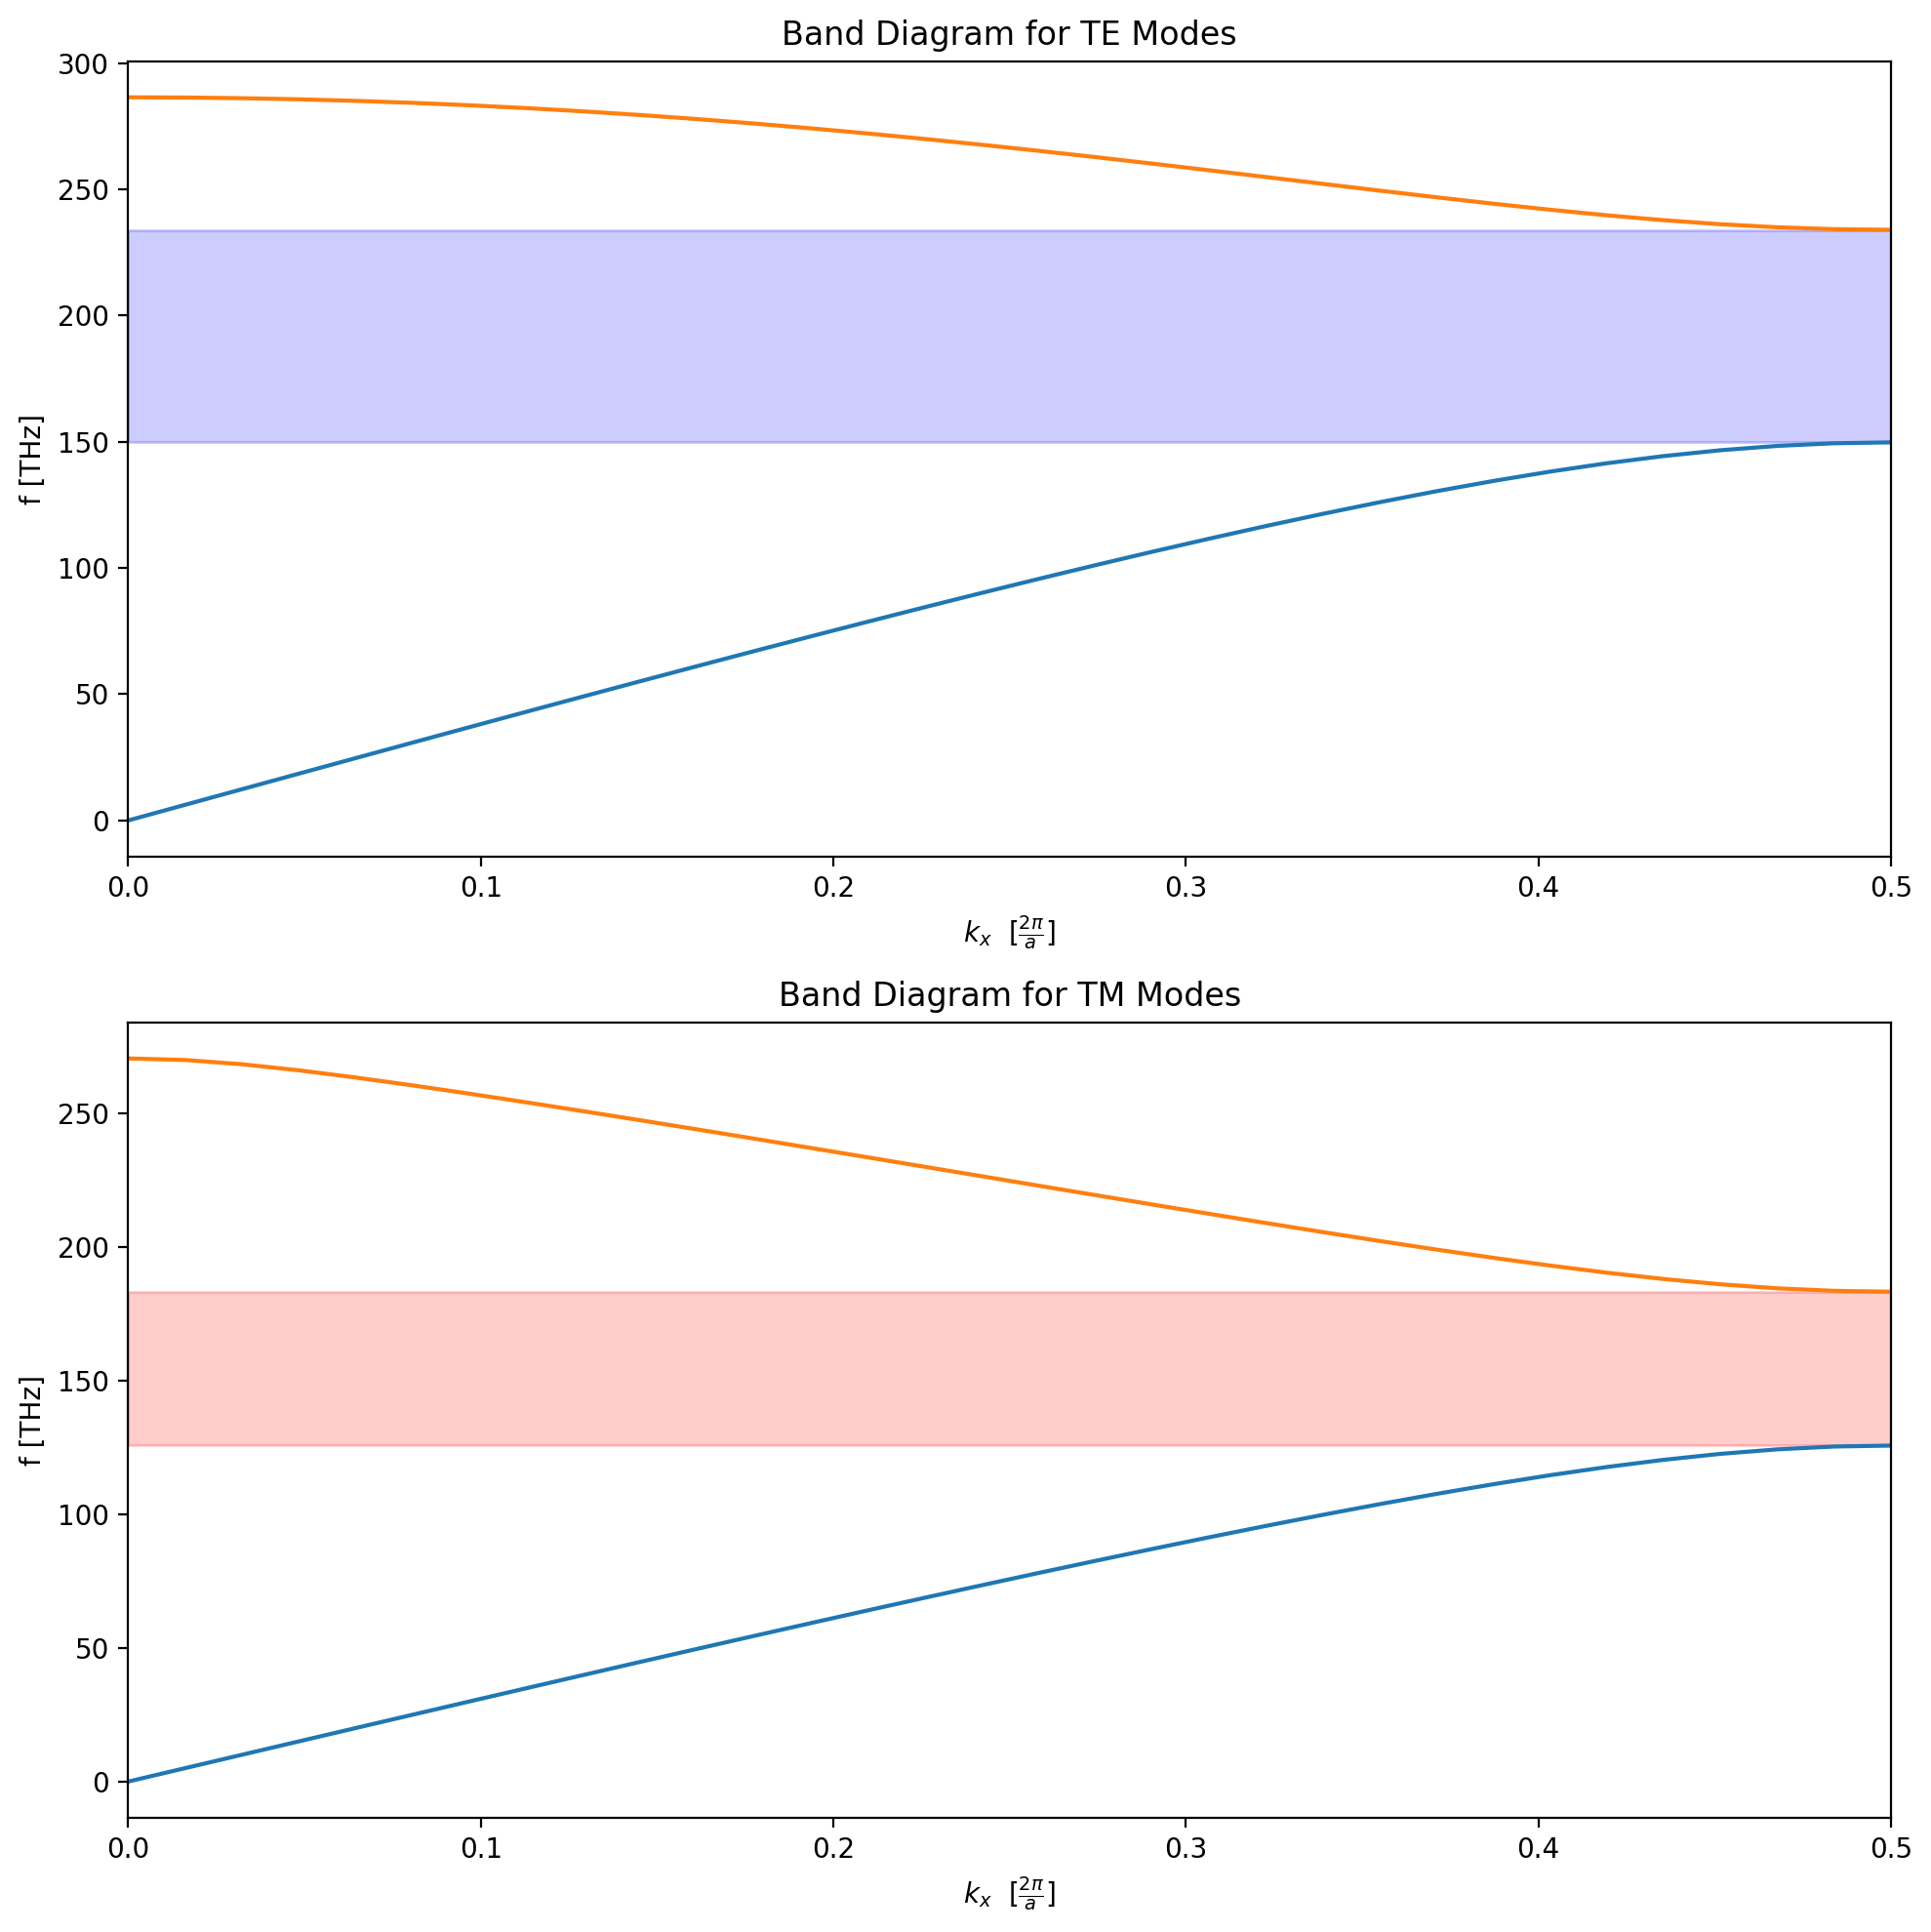

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25845,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.462486, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.0806451

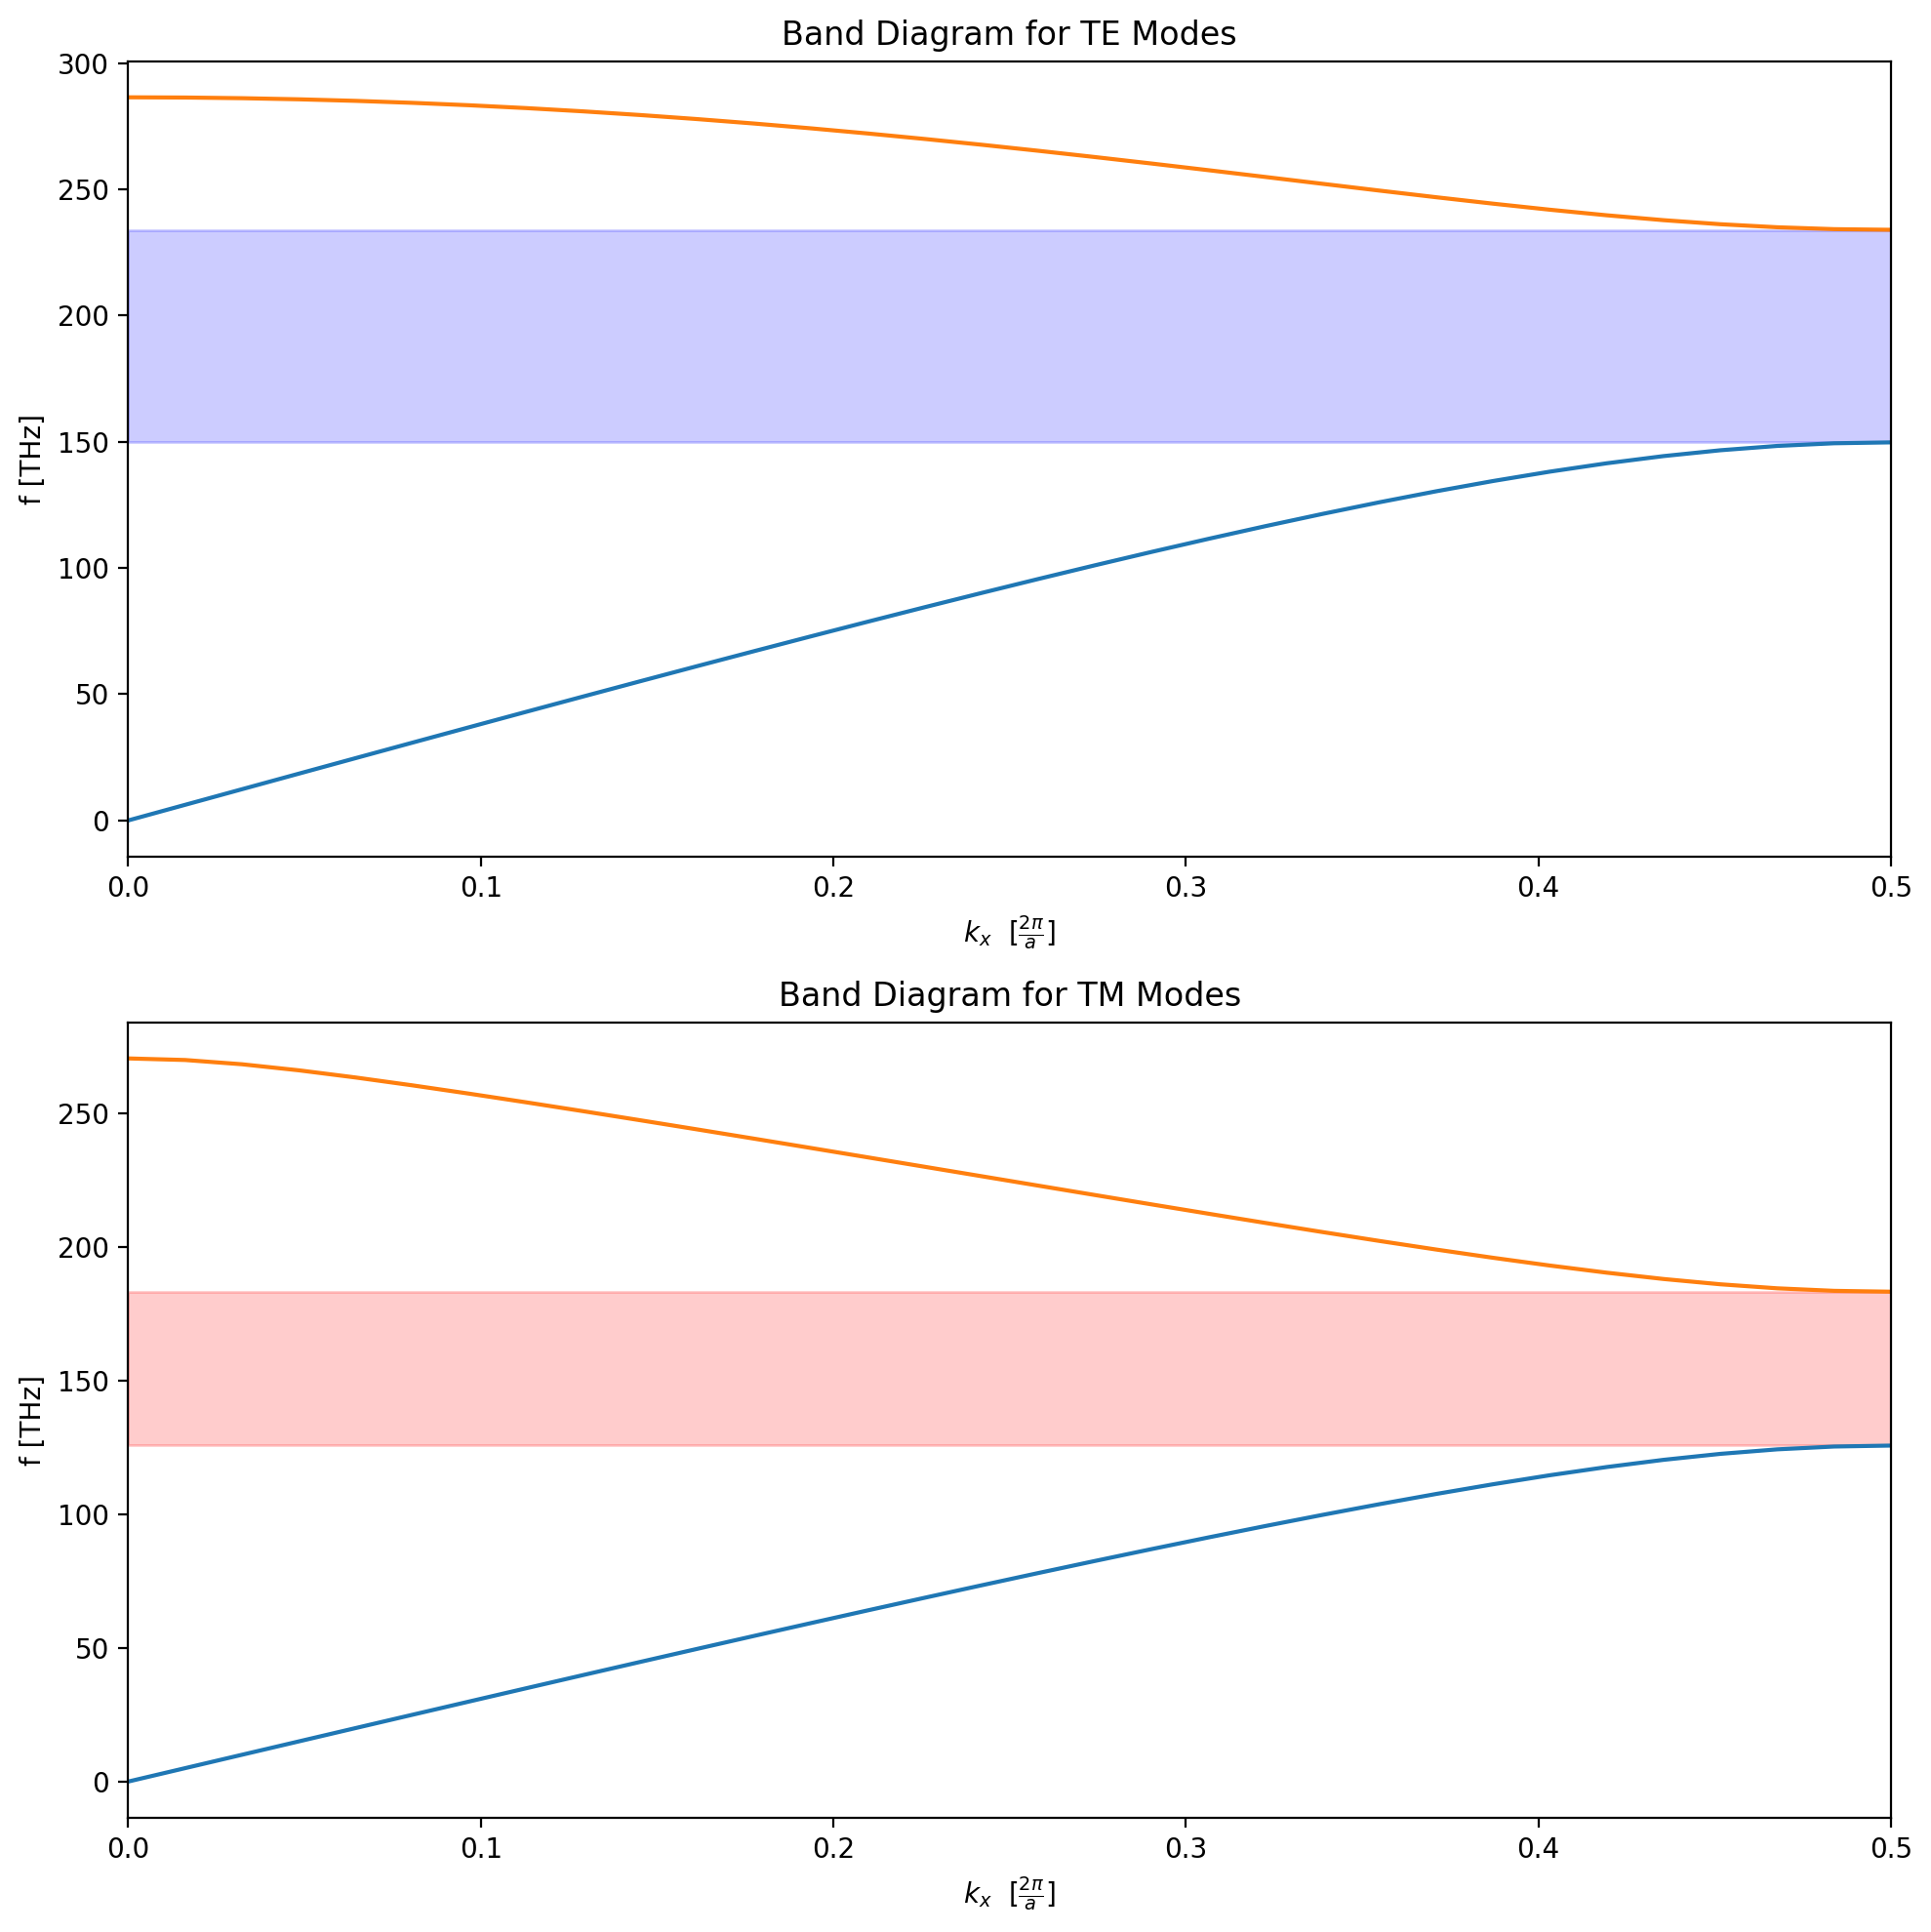

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25844,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.46248, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516

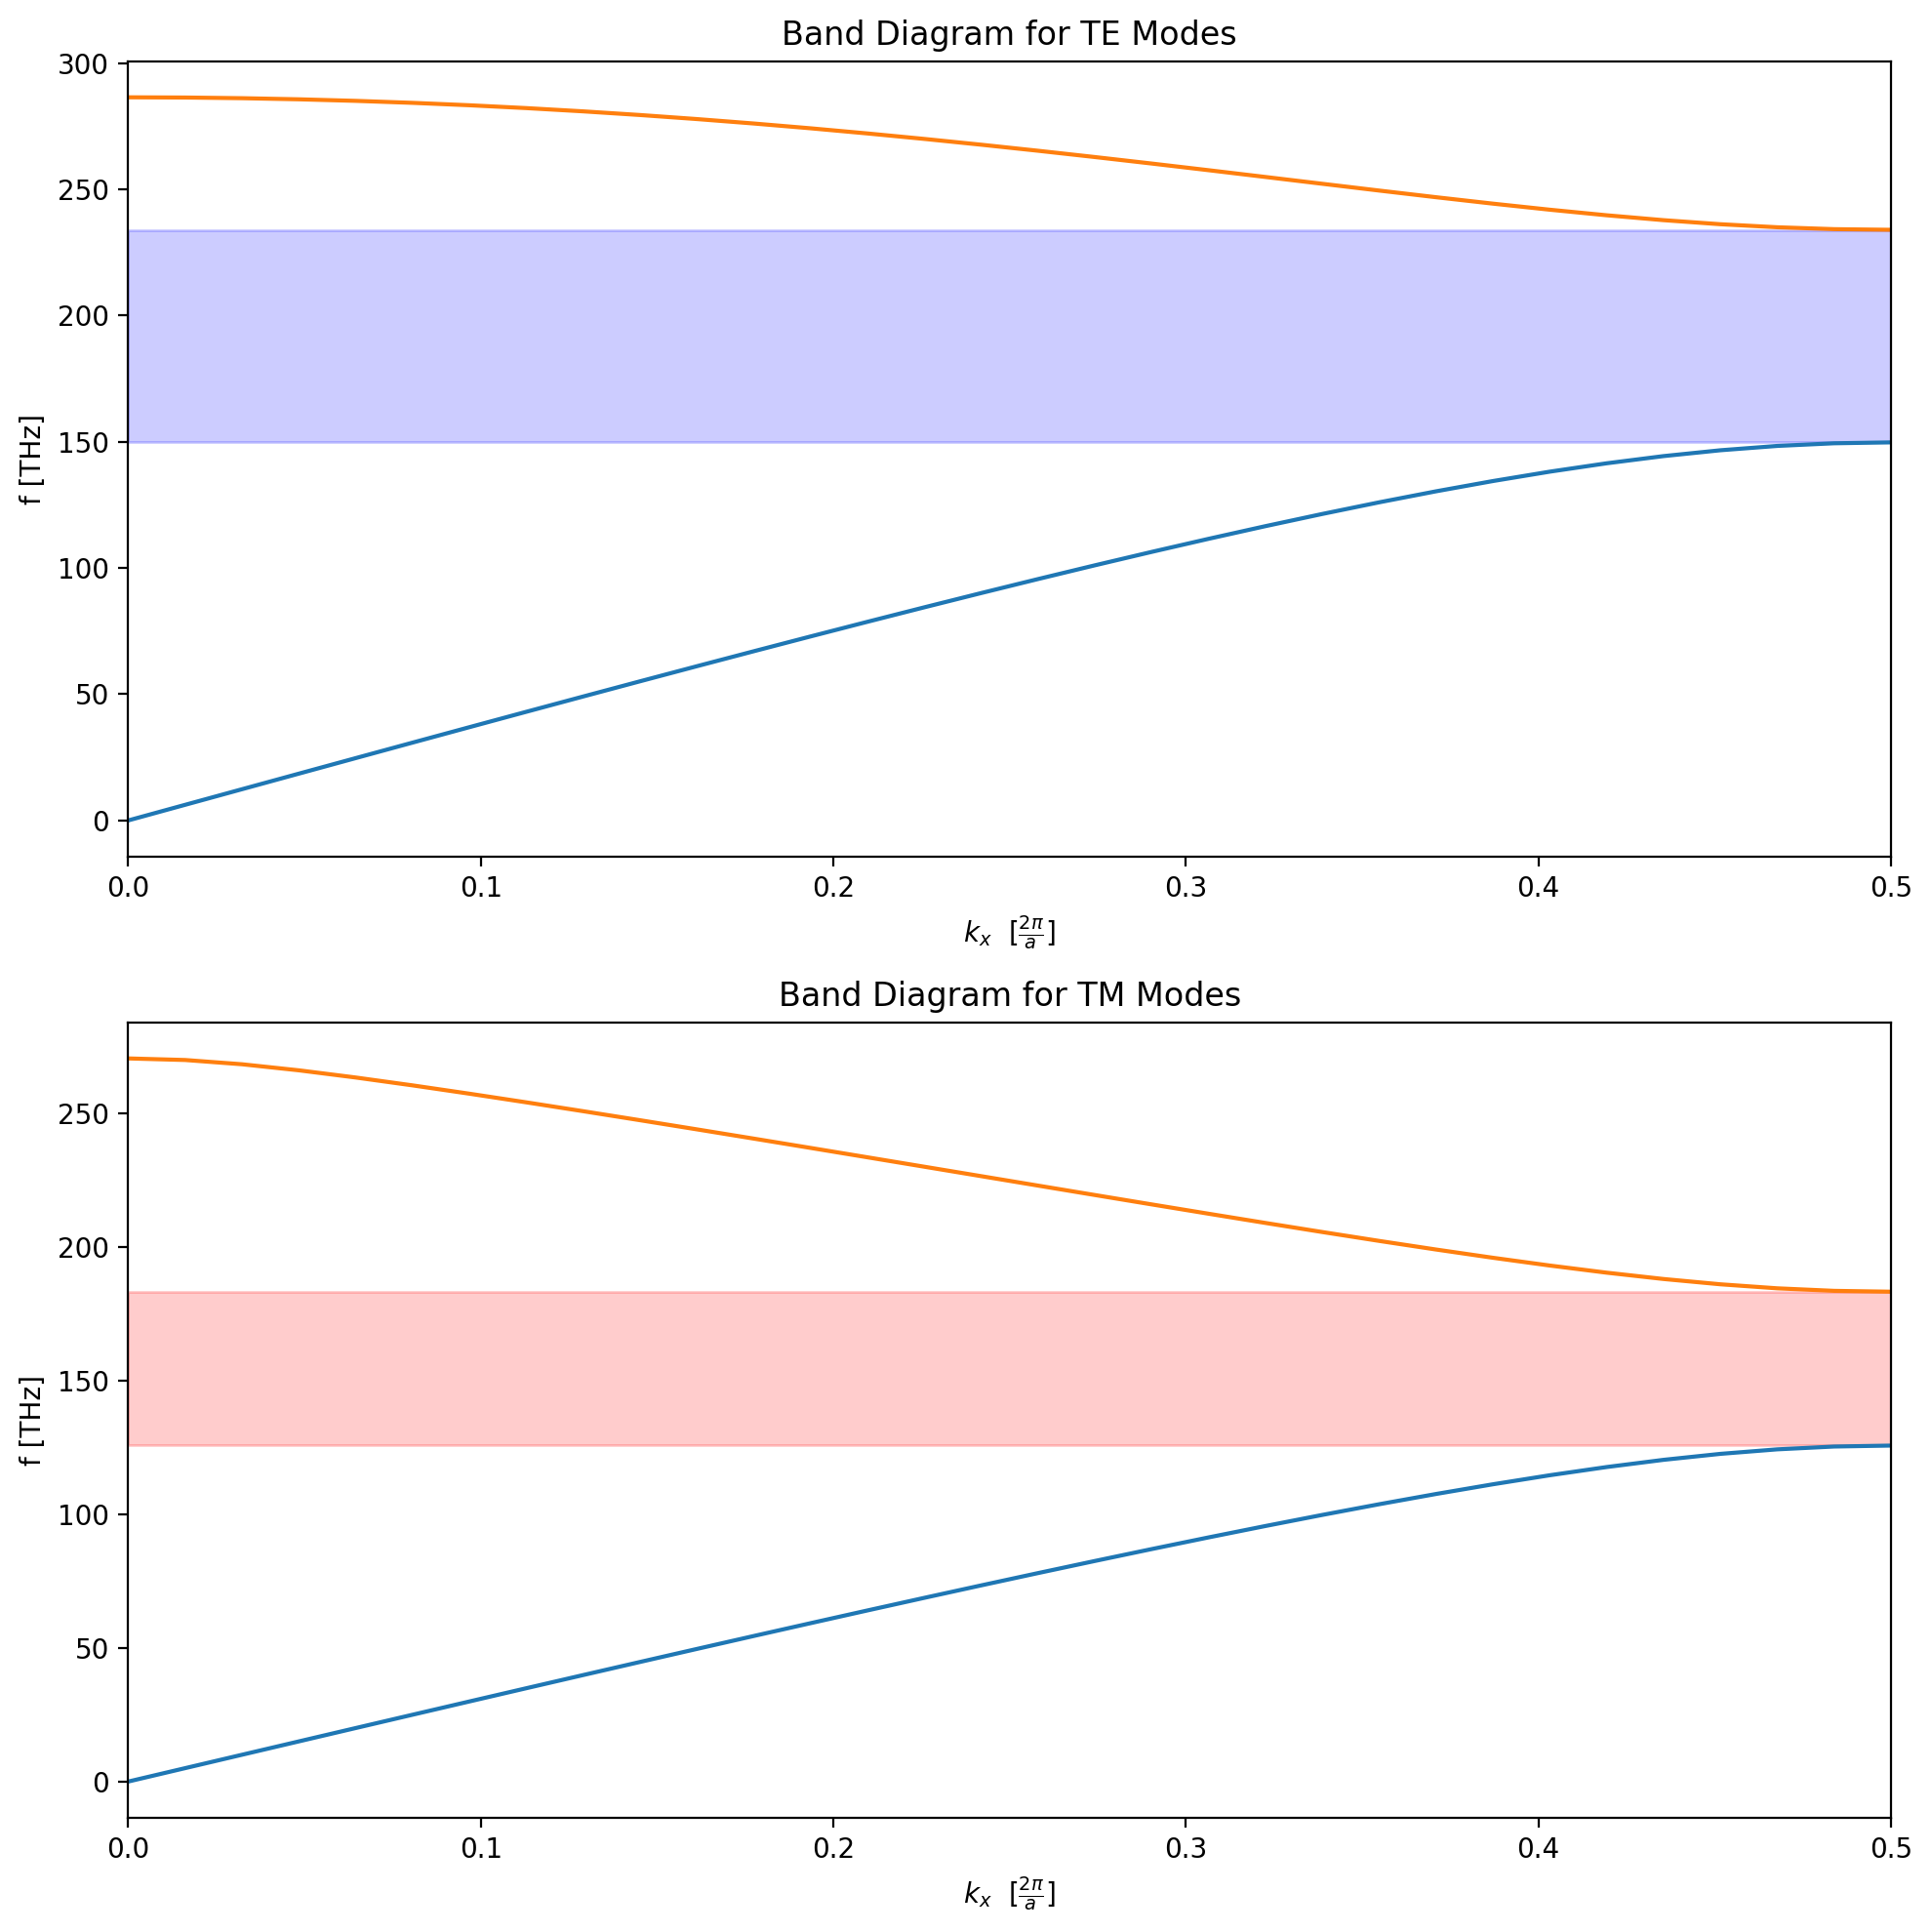

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25844,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.46248, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516

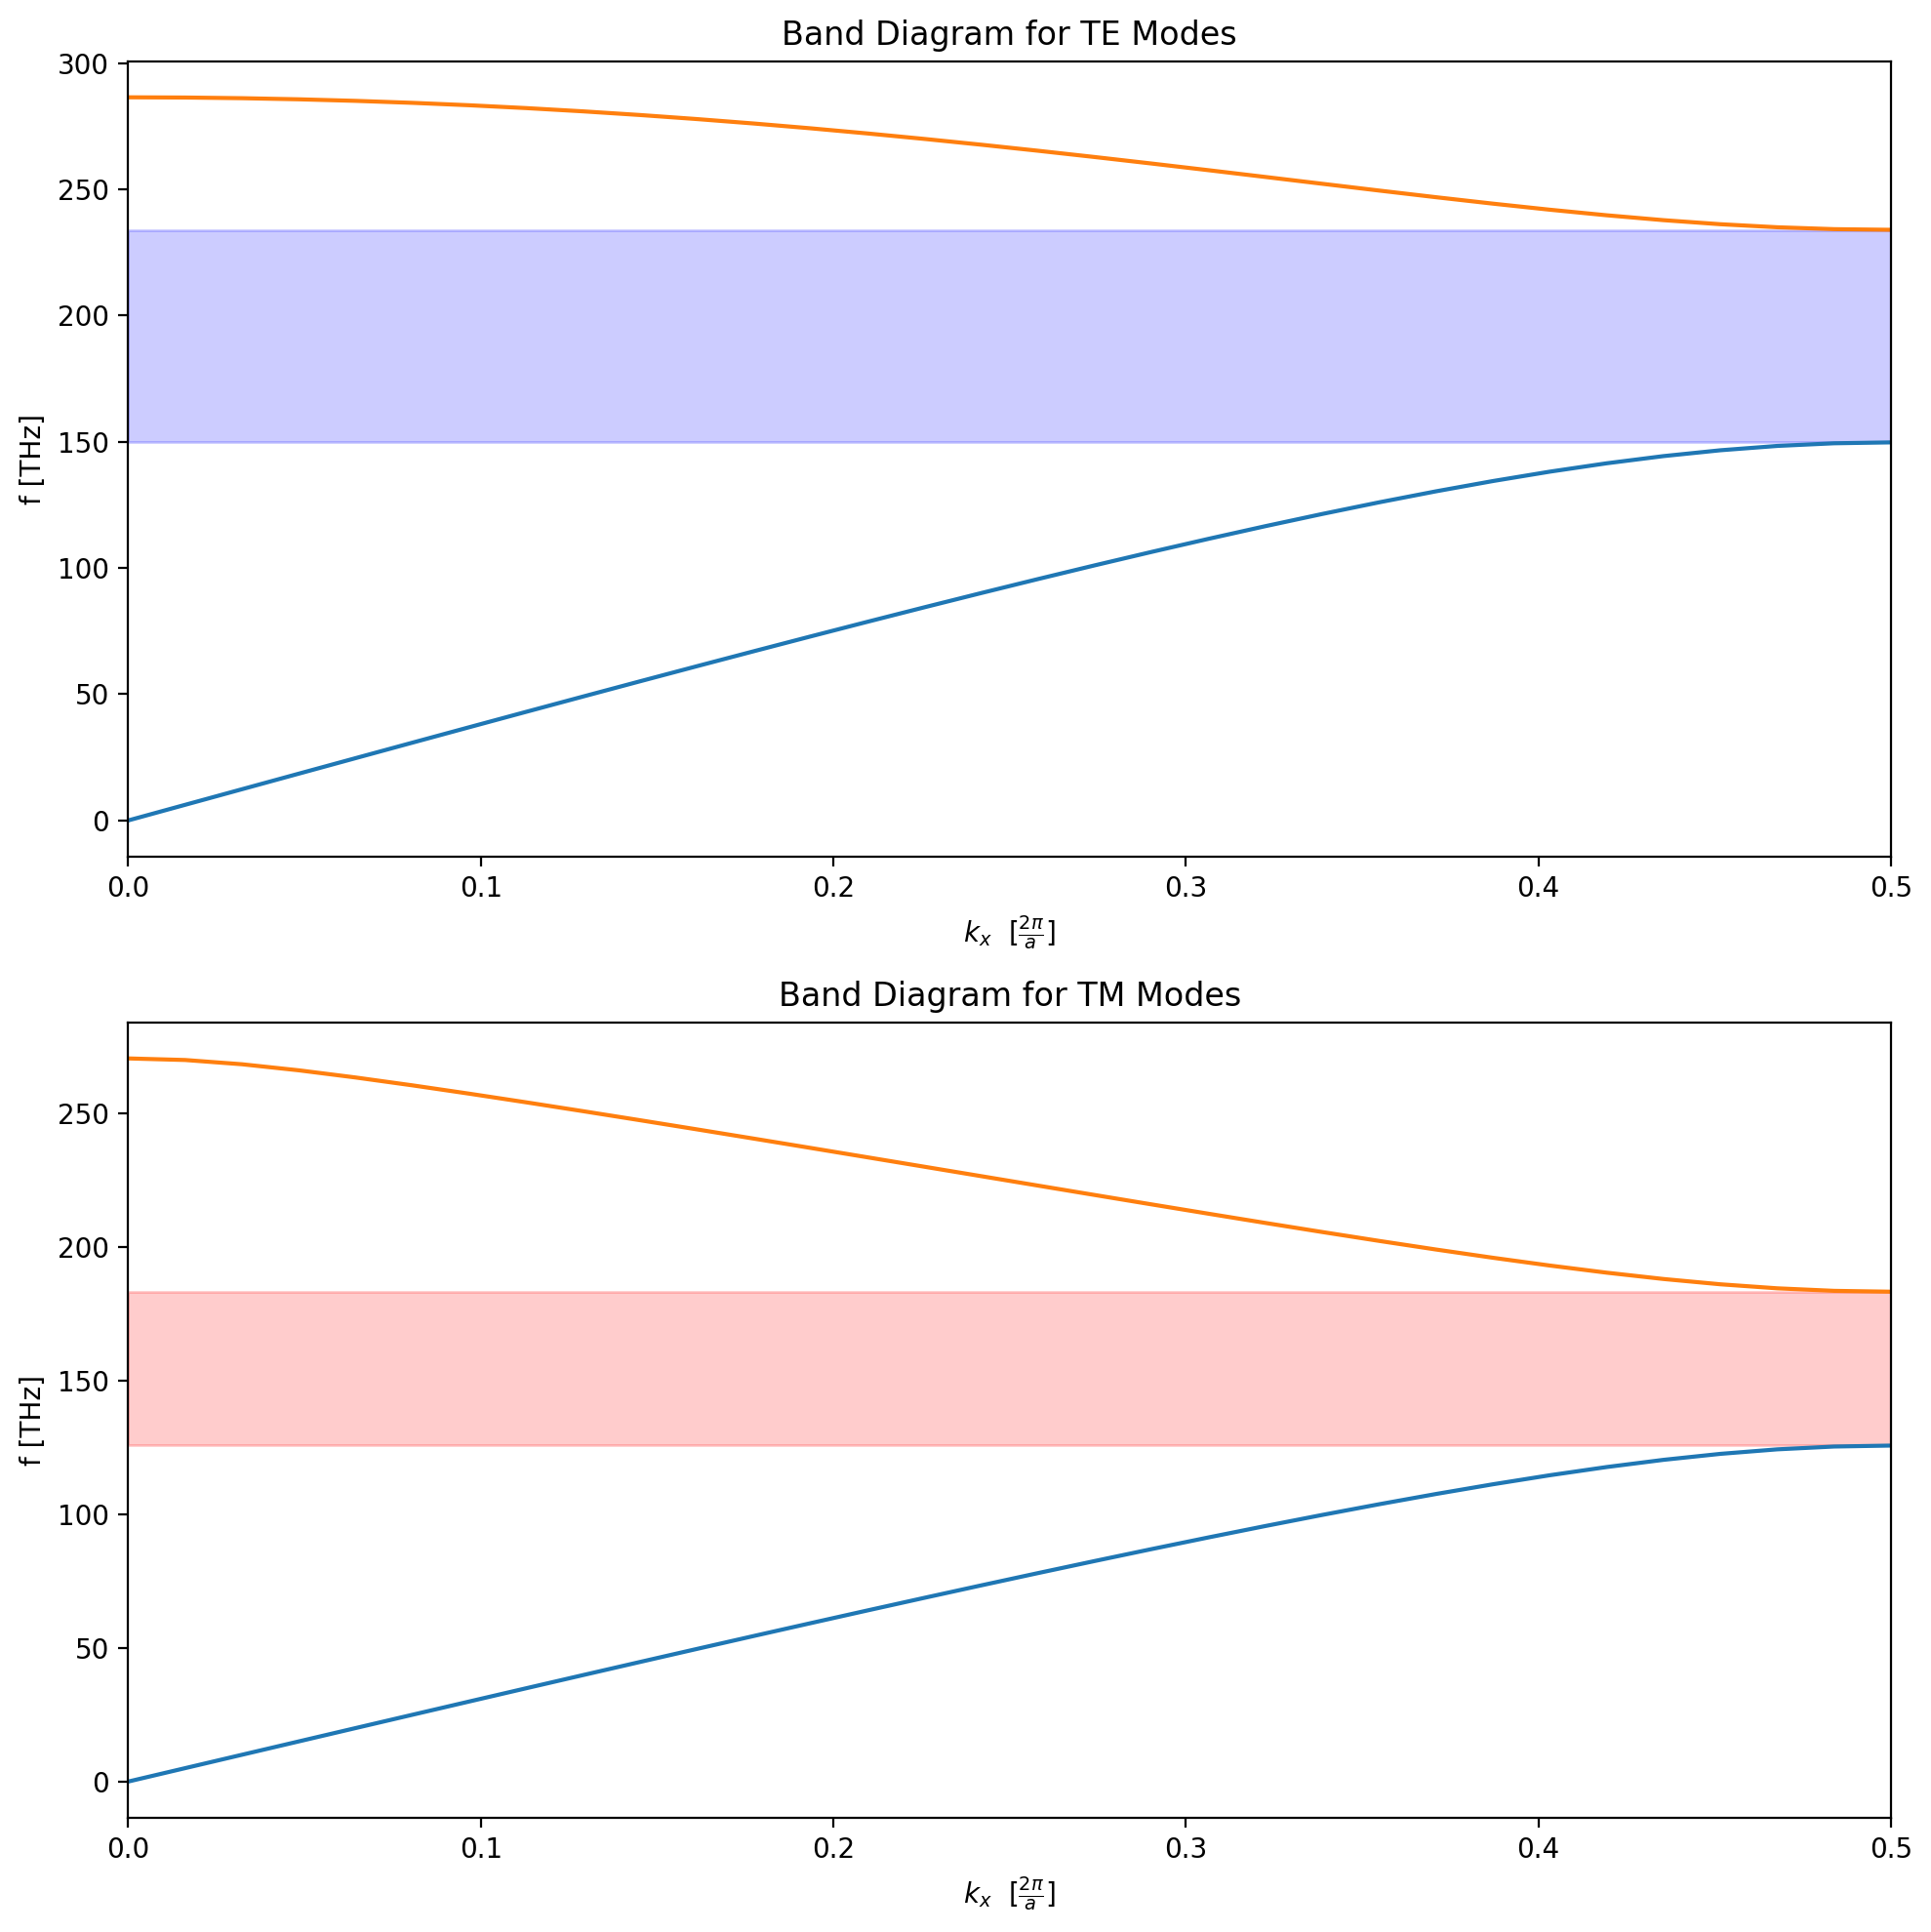

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25844,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.46248, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516

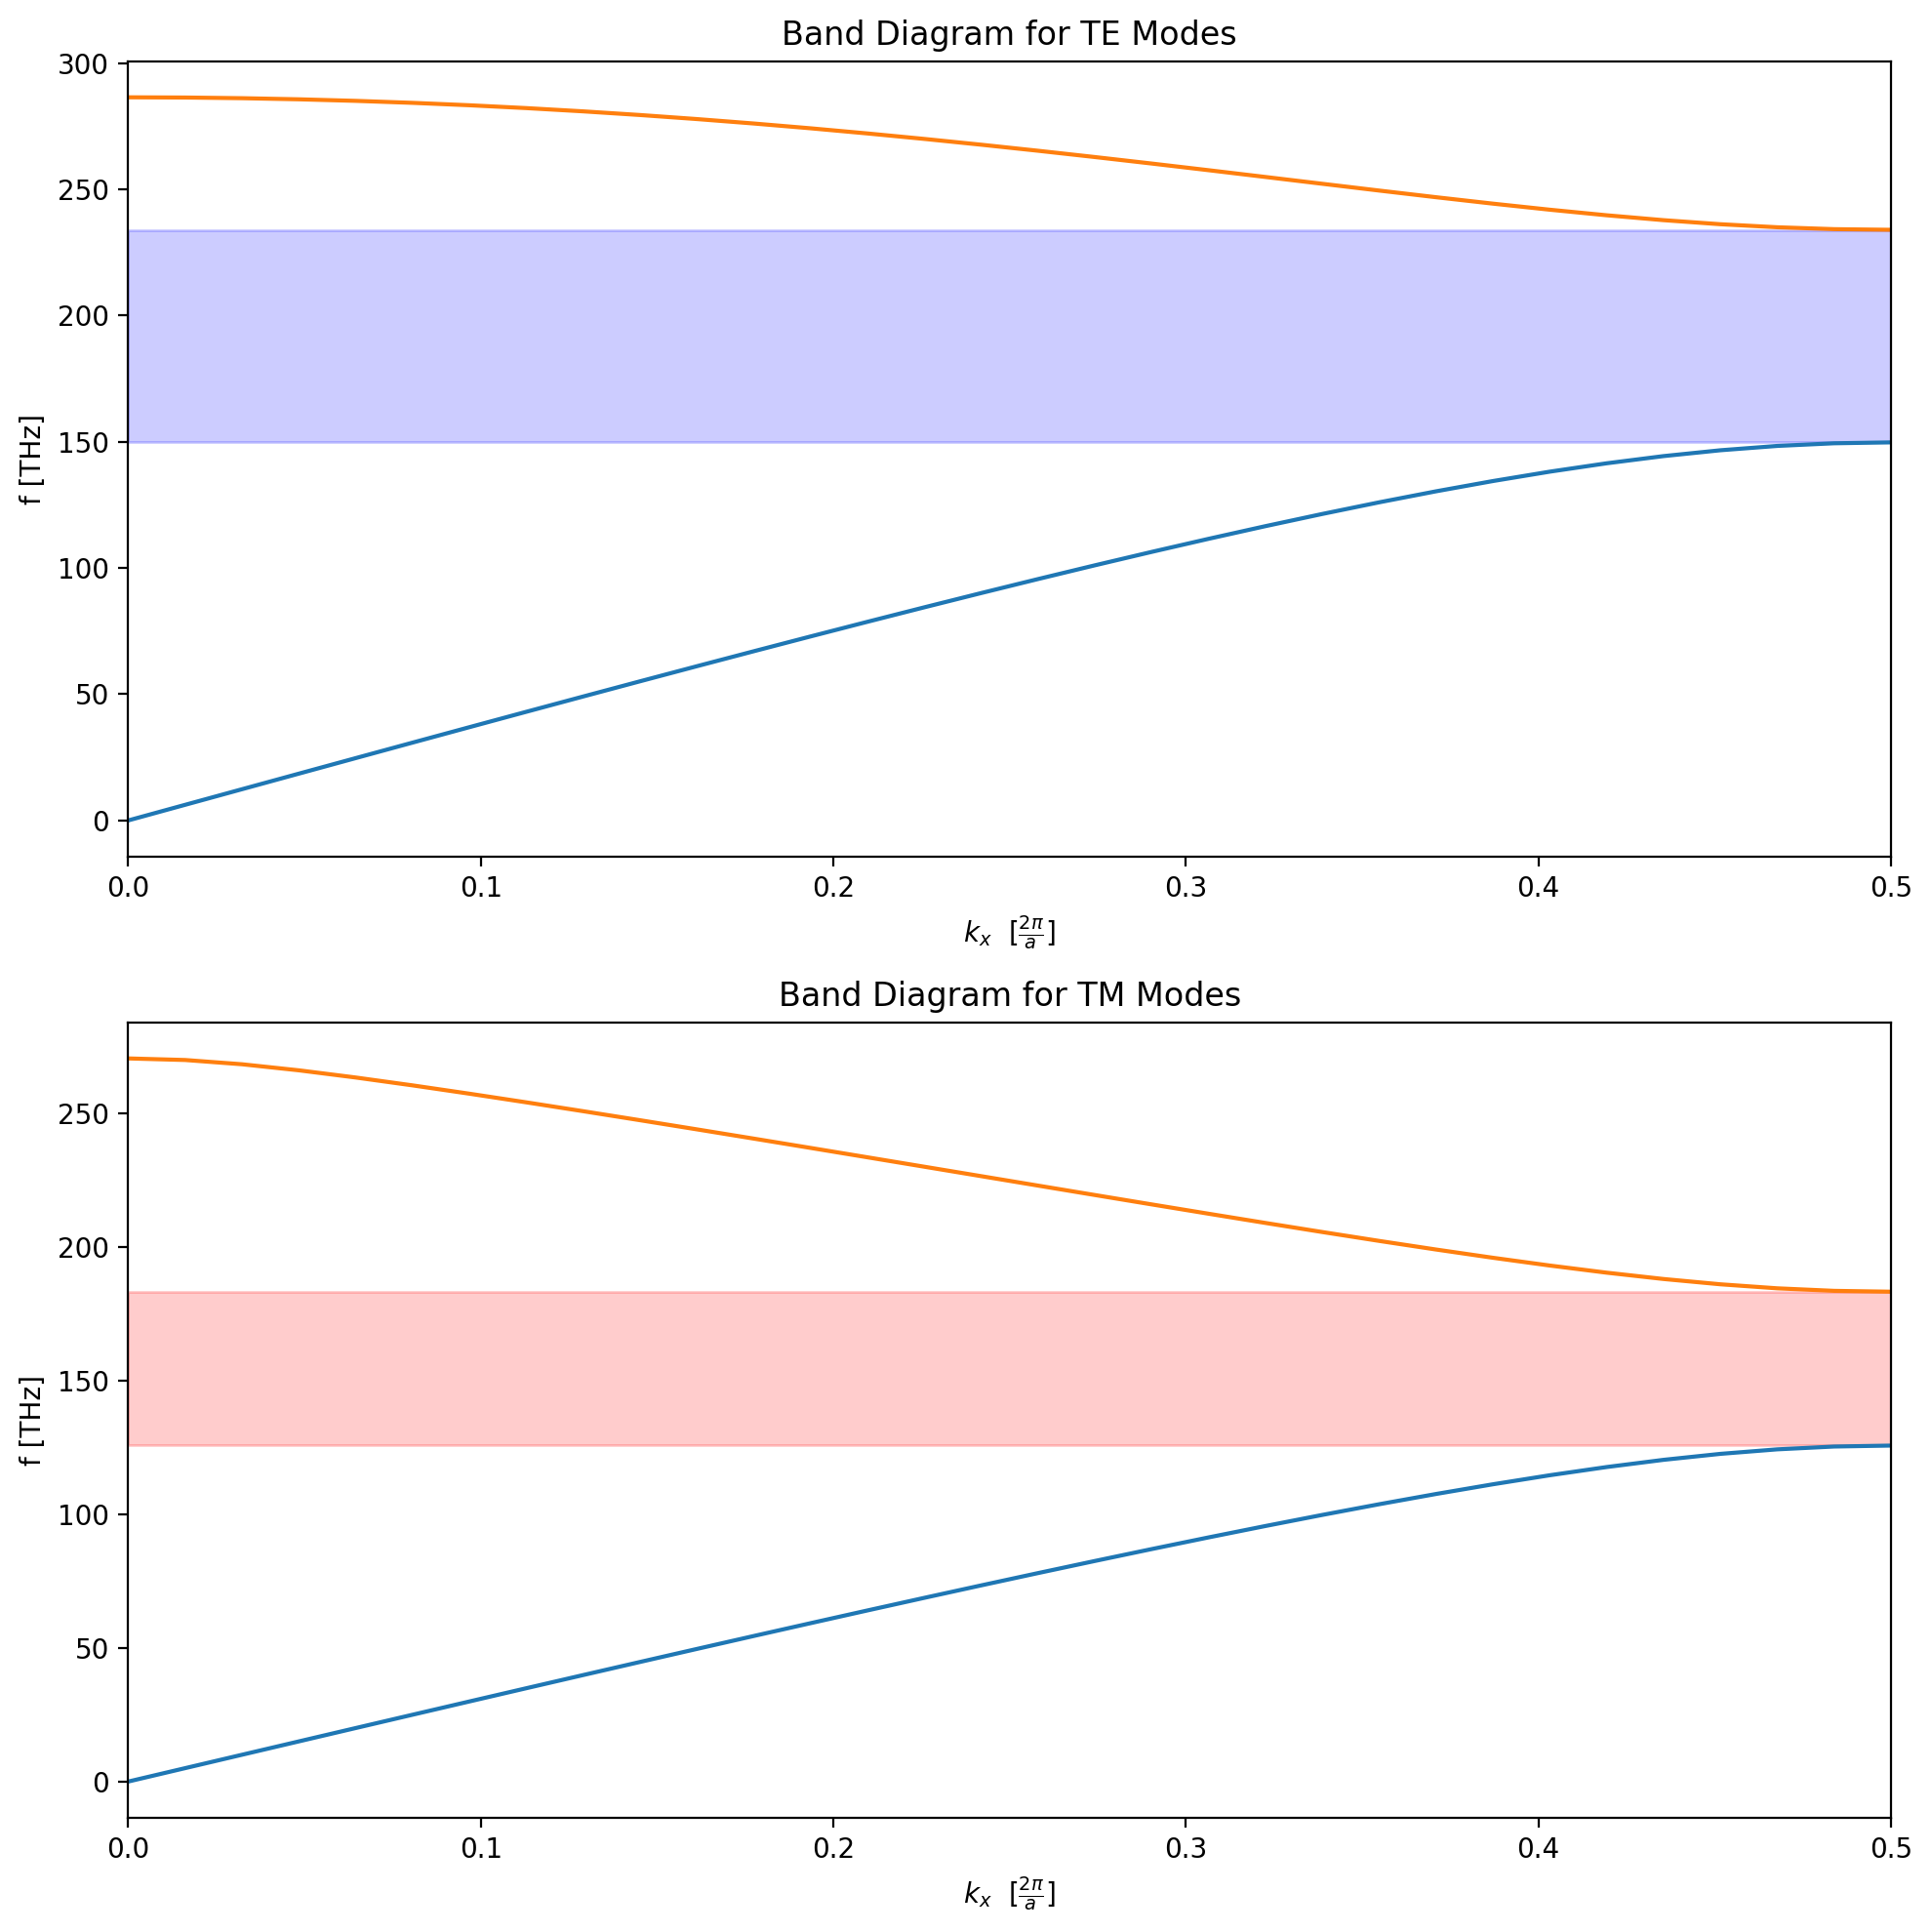

In [111]:
show_geometry = False 
band_diagram = 'all'
length = 450
def objective(x): 
    width, diameter = x
    return -banddiagram_wmpb(width, length, diameter, show_geometry=show_geometry, band_diagram=band_diagram)

difference = 150
def constraint_difference(x): 
    width, diameter = x 
    return width - diameter - difference 

constraints = [
    {'type': 'ineq', 'fun': constraint_difference}
]

x0 = [540, 390]
bounds = [(250,length*1.5), (100,length*1.5)]
res = minimize(
    objective,
    x0=x0,
    bounds = bounds, 
    constraints=constraints,
    method = 'SLSQP',
    options={
    'ftol': 1e-4, 
    'maxiter':50,
    }
)

     block, center = (0,0,0)
          size (1,1.25844,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.46248, height 0.488889, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)


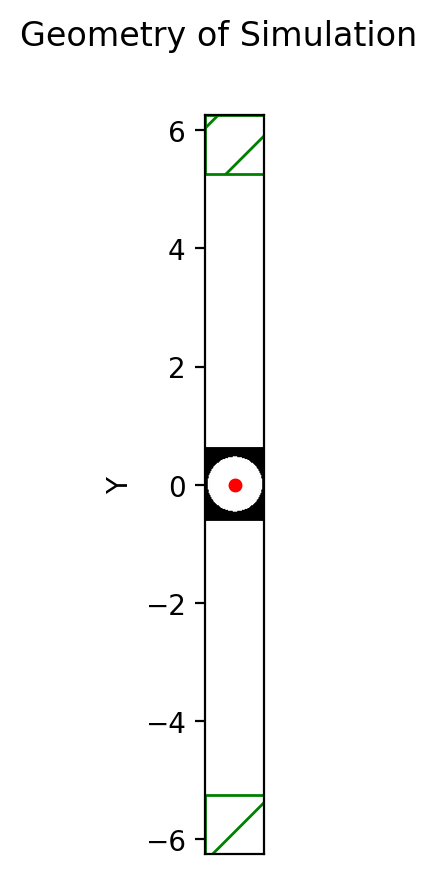

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.25844,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.46248, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 4 and 22 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.08064516

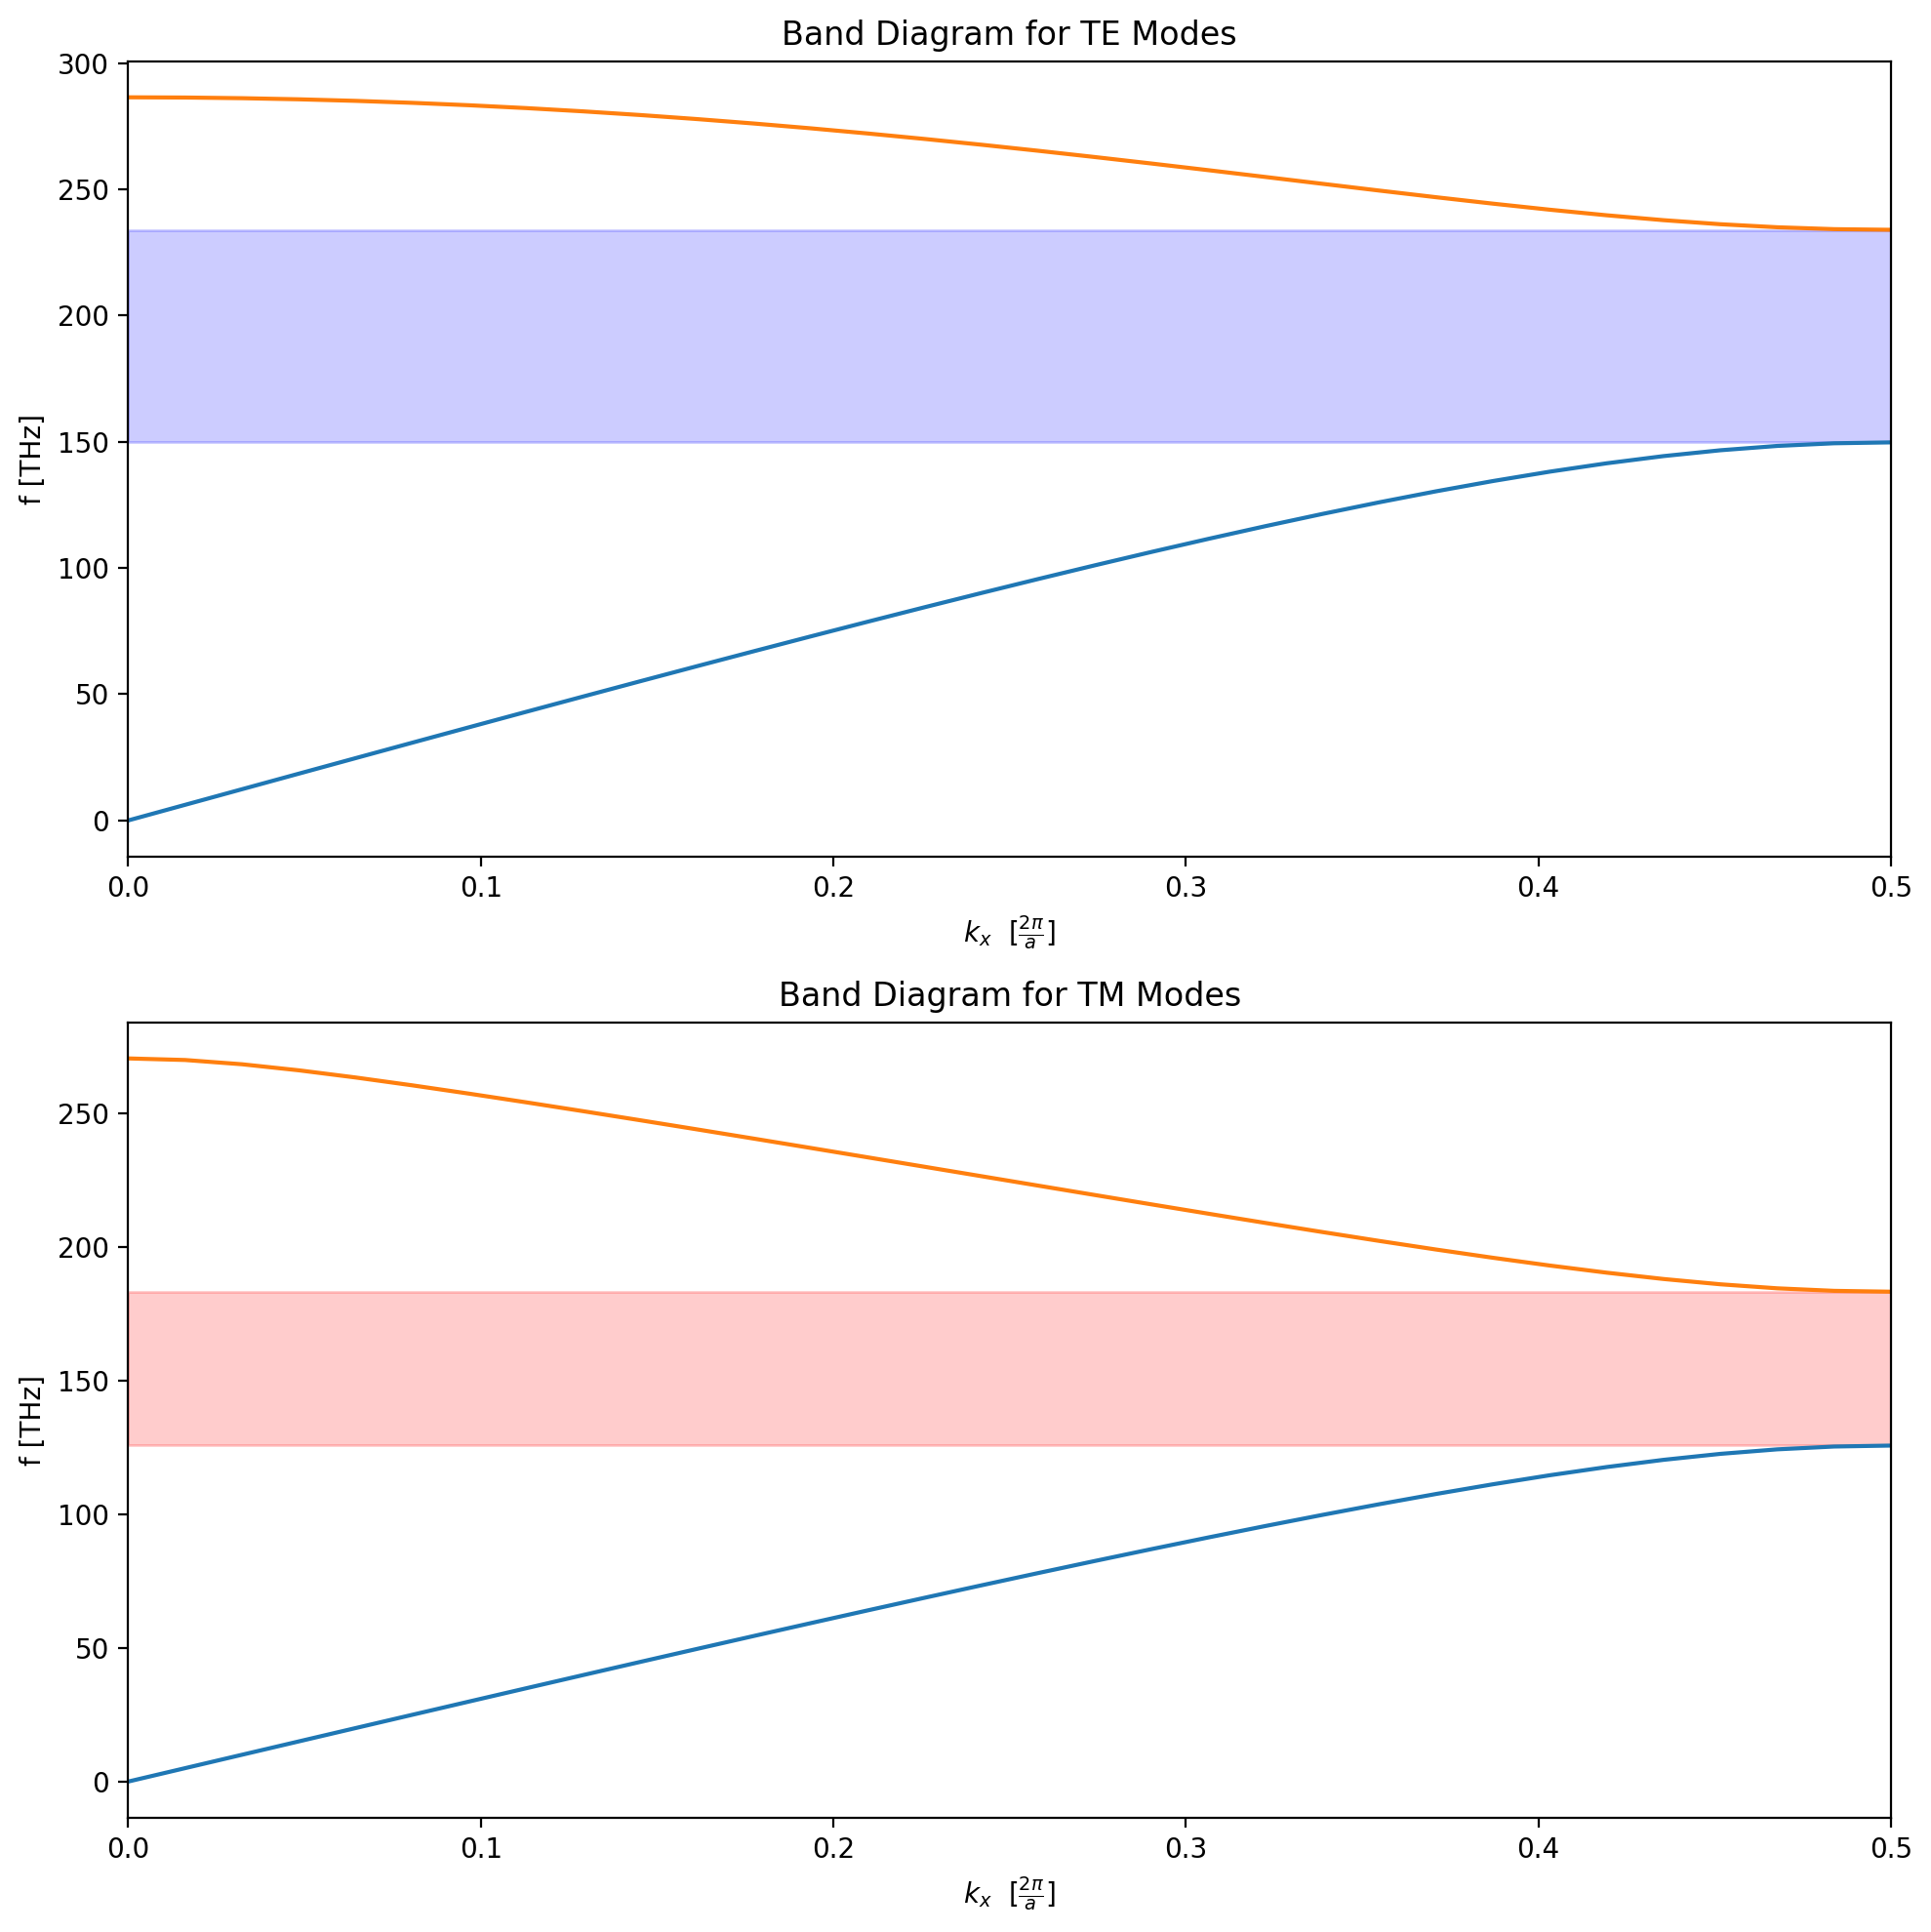

84.19249283965163

In [112]:
banddiagram_wmpb(width = res.x[0], length = length, diameter = res.x[1], show_geometry=True, band_diagram='max')

In [113]:
print(res)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -84.1924928396516
           x: [ 5.663e+02  4.162e+02]
         nit: 9
         jac: [-3.815e-06 -1.615e-03]
        nfev: 35
        njev: 9
 multipliers: [ 0.000e+00]


     block, center = (0,0,0)
          size (1,1.36,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.5, height 0.488889, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)


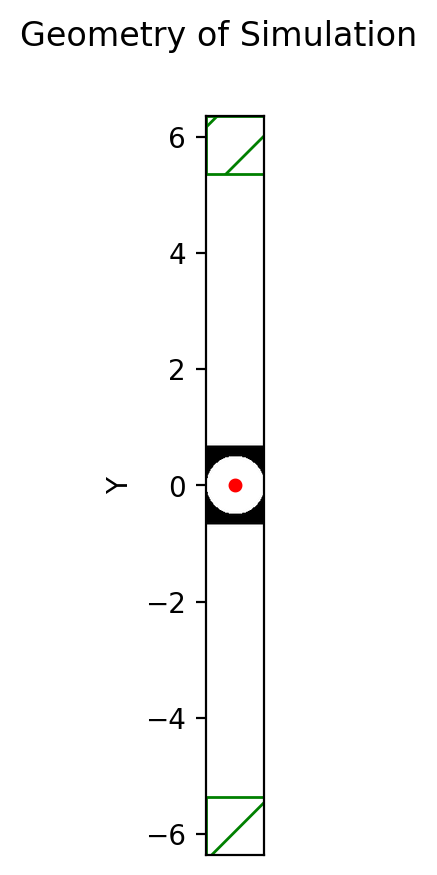

Initializing eigensolver data
Computing 2 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 64 x 64 x 1.
Solving for 2 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,1.36,0.488889)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.5, height 0.488889, axis (0, 0, 1)
Geometric object tree has depth 3 and 32 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
32 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.016129032258064516, 0.0, 0.0>
  Vector3<0.03225806451612903, 0.0, 0.0>
  Vector3<0.04838709677419355, 0.0, 0.0>
  Vector3<0.06451612903225806, 0.0, 0.0>
  Vector3<0.080645161290322

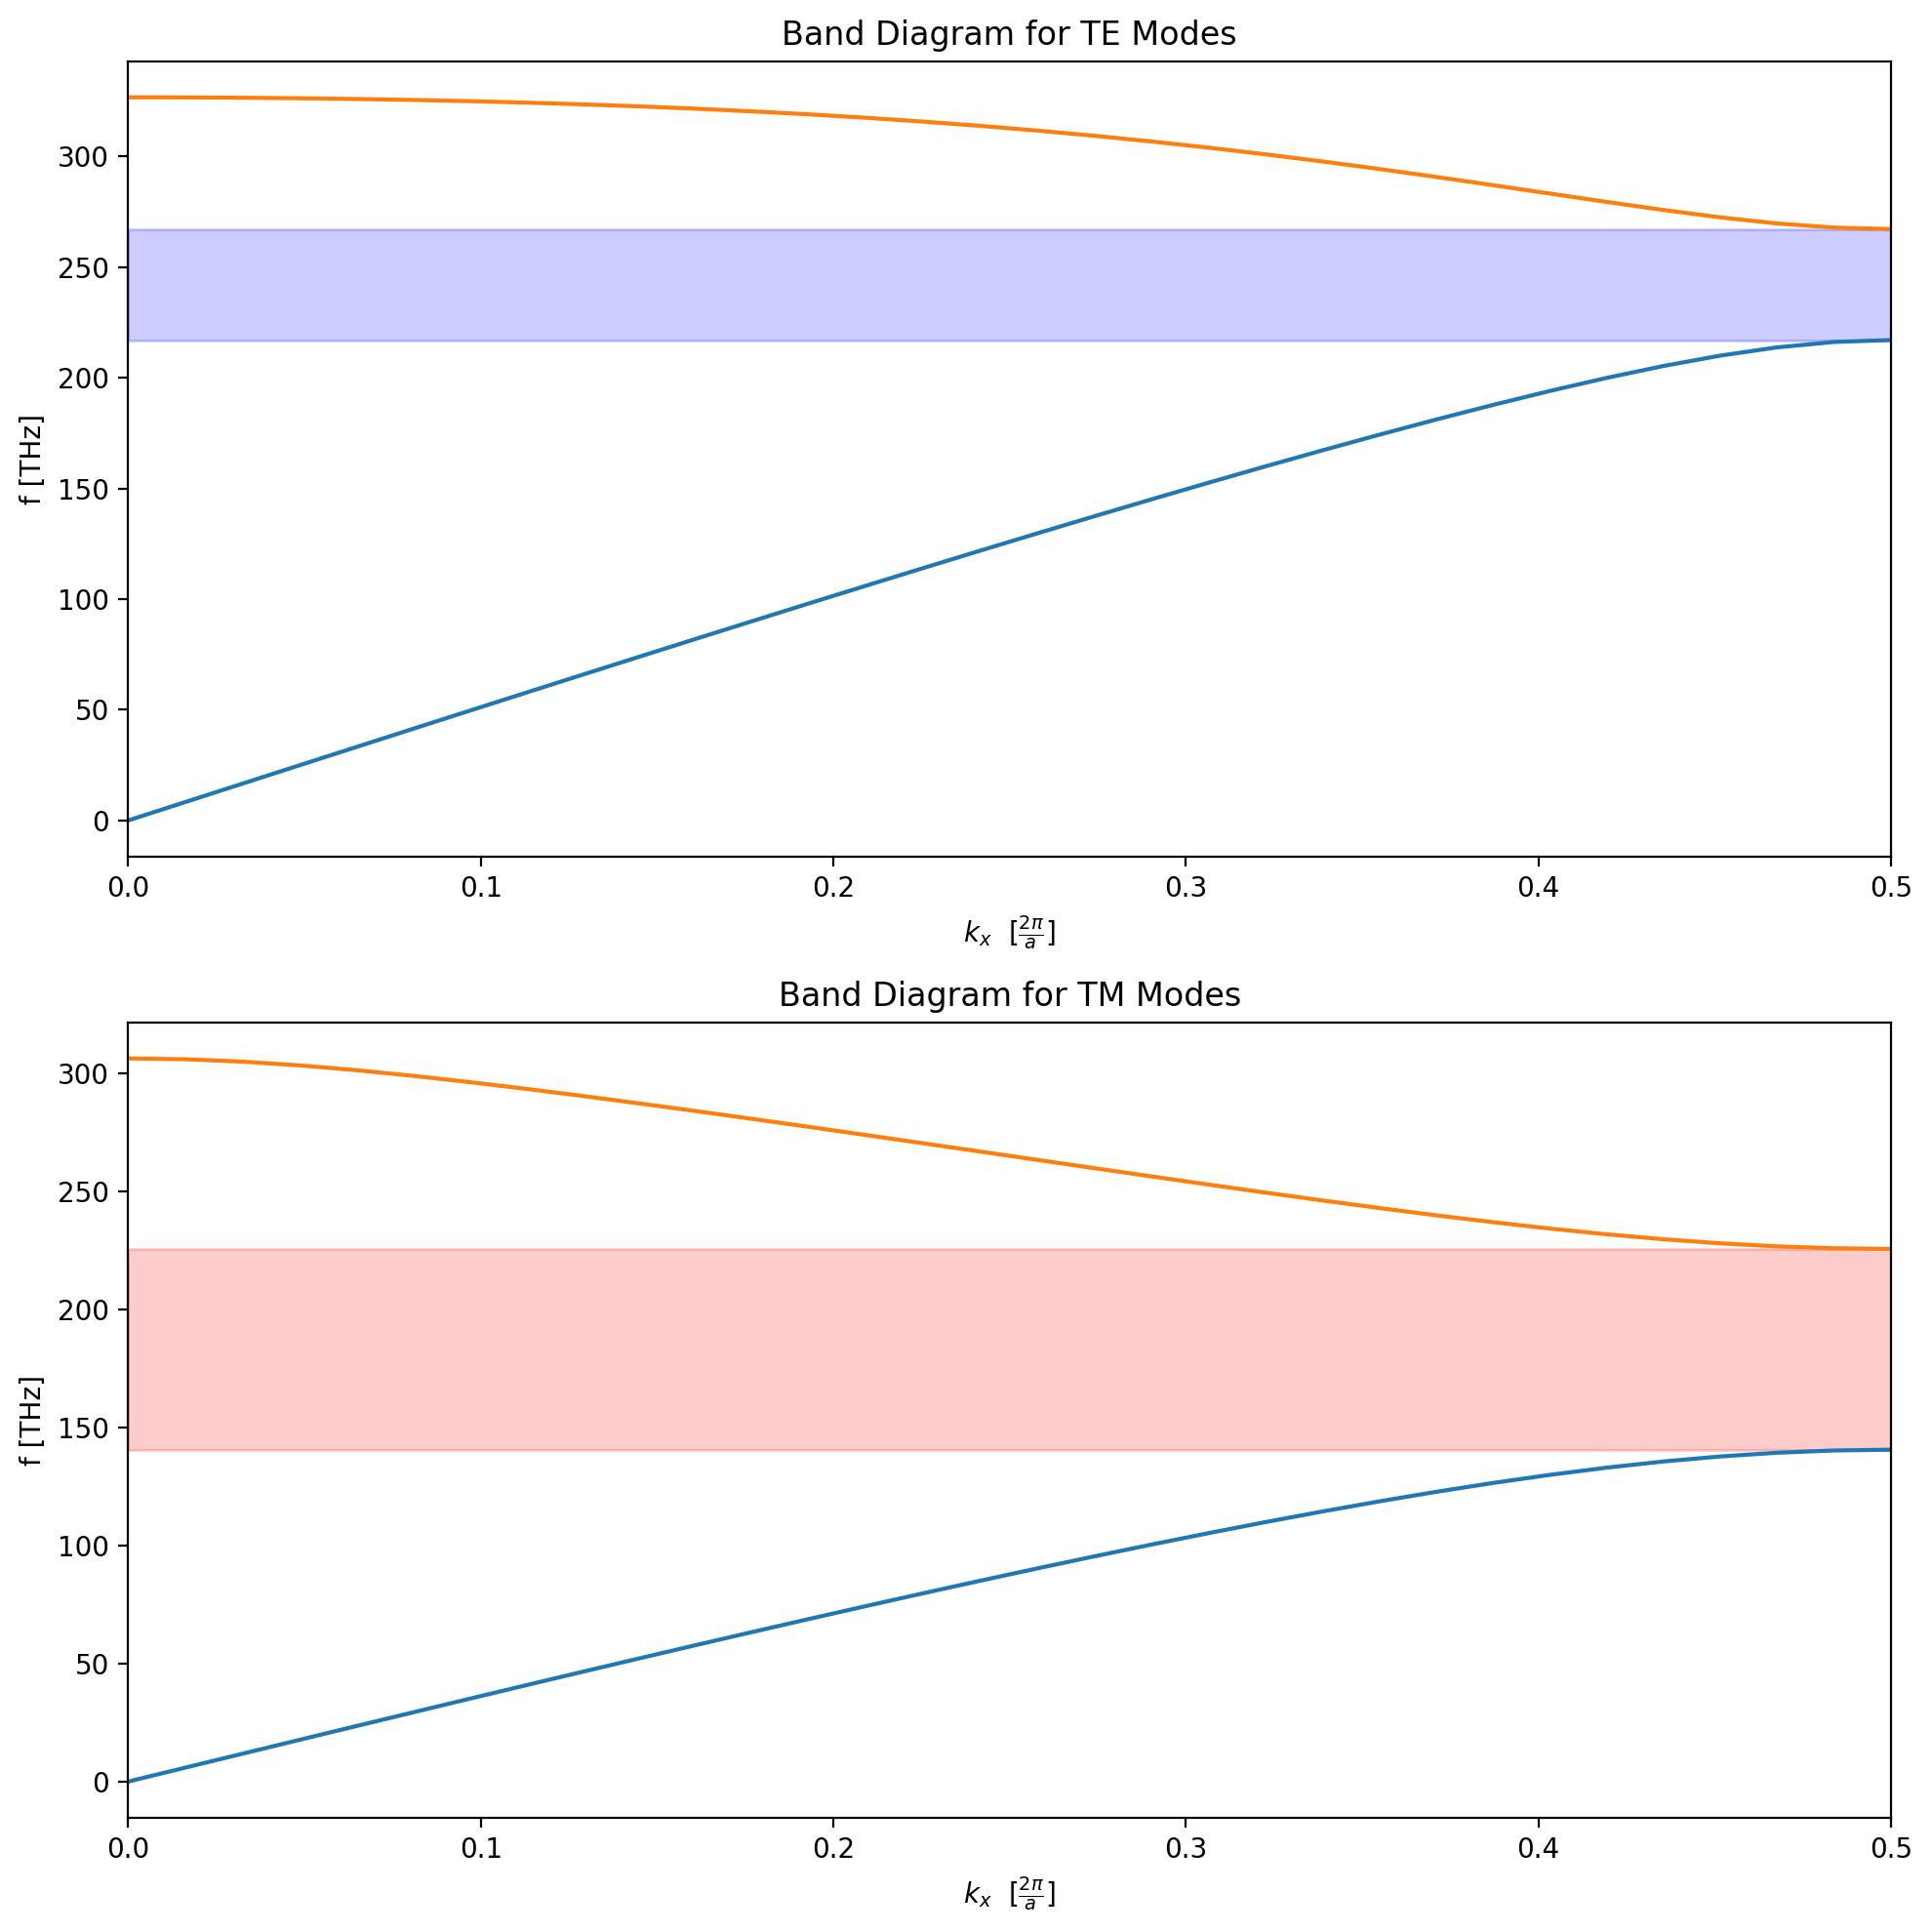

50.15560059050657

In [114]:
banddiagram_wmpb(width = 612, length = length, diameter = 450, show_geometry=True, band_diagram='max')